<a id="bloque-1"></a>

**01_dataset_builder.ipynb - contrato de datos para backtest y ML**

Este notebook define el contrato tecnico del dataset que vamos a usar para backtest y para modelos ML.  
El foco es dejar trazable, con evidencia de archivos reales, cuatro decisiones: universo, periodo, sesiones y granularidad.

Se trabaja con la data disponible en `C:/TSIS_Data/data` y con contexto metodologico del proyecto en `C:/TSIS_Data/v1/backtest_SmallCaps`.


**1) Objetivo operativo y principio metodologico**

Objetivo operativo del notebook:
- Construir una especificacion reproducible de dataset `ticker-minute`.
- Demostrar que la especificacion nace de la estructura real de datos y no de supuestos.
- Dejar lista la base para dos salidas: `dataset_backtest_1m` y `dataset_ml_1m`.

Principio metodologico:
- Toda decision debe responder estas preguntas:
  - que dato existe fisicamente,
  - en que frecuencia temporal vive,
  - como se alinea sin leakage,
  - que riesgo introduce si falta.


**Menu Del Notebook (Guia De Bloques)**

1. [Bloque 1: Contrato y mapa de datos](#bloque-1)
2. [Bloque 2: Cobertura ajustada y calidad por dominio](#bloque-2)
3. [Bloque 3: Decision por ticker y diagnostico de fallos](#bloque-3)
4. [Bloque 4: Escalado 6400 - arquitectura y readiness](#bloque-4)
5. [Bloque 5: Policy provisional v3 y materializacion](#bloque-5)
6. [Bloque 6: EVENT_DRIVEN_EDGE experimental](#bloque-6)
7. [Bloque 7: Policy final + forense + cohorts](#bloque-7)
8. [Bloque 8: Visor por ticker y explicabilidad QA](#bloque-8)
9. [Bloque 9: Orquestacion 03/06 y resumenes masivos](#bloque-9)


In [22]:
from __future__ import annotations

from pathlib import Path
from collections import defaultdict
from datetime import datetime
import json
import pandas as pd
import pyarrow.parquet as pq

DATA_ROOT = Path(r"C:/TSIS_Data/data")
PROJECT_ROOT = Path(r"C:/TSIS_Data/v1/backtest_SmallCaps")
CTO_RESUME = PROJECT_ROOT / "00_cto" / "data_resume.md"

print("DATA_ROOT:", DATA_ROOT)
print("PROJECT_ROOT:", PROJECT_ROOT)
print("DATA_ROOT exists:", DATA_ROOT.exists())
print("CTO resume exists:", CTO_RESUME.exists())


DATA_ROOT: C:\TSIS_Data\data
PROJECT_ROOT: C:\TSIS_Data\v1\backtest_SmallCaps
DATA_ROOT exists: True
CTO resume exists: True


**2) Mapa de dominios de datos disponibles**

Esta seccion responde: "que familias de datos tenemos para cada ticker y cuales son globales".

Logica:
- Dominio ticker-centric: archivos particionados por ticker.
- Dominio global: tablas transversales que luego se unen por fecha o por ticker.


In [23]:
DOMAINS = {
    "ohlcv_1m": DATA_ROOT / "ohlcv_intraday_1m",
    "quotes_p95": DATA_ROOT / "quotes_p95",
    "trades_2004_2018": DATA_ROOT / "trades_ticks_2004_2018",
    "trades_2019_2025": DATA_ROOT / "trades_ticks_2019_2025",
    "short_data": DATA_ROOT / "short_data",
    "fundamentals": DATA_ROOT / "fundamentals",
    "additional": DATA_ROOT / "additional",
    "reference": DATA_ROOT / "reference",
    "regime_indicators": DATA_ROOT / "regime_indicators",
}

def sample_parquet_count(path: Path, cap: int = 2000):
    if not path.exists():
        return 0, False
    n = 0
    for _ in path.rglob("*.parquet"):
        n += 1
        if n >= cap:
            return n, True
    return n, False

rows = []
for name, path in DOMAINS.items():
    sampled_n, capped = sample_parquet_count(path, cap=2000)
    rows.append({
        "domain": name,
        "path": str(path),
        "exists": path.exists(),
        "subdirs": sum(1 for p in path.iterdir() if p.is_dir()) if path.exists() else 0,
        "parquet_files_sampled": sampled_n,
        "sample_is_capped": capped,
    })

inventory_df = pd.DataFrame(rows)
inventory_df


,domain,path,exists,subdirs,parquet_files_sampled,sample_is_capped
0,ohlcv_1m,C:\TSIS_Data\data\ohlcv_intraday_1m,True,2,2000,True
1,quotes_p95,C:\TSIS_Data\data\quotes_p95,True,6114,2000,True
2,trades_2004_2018,C:\TSIS_Data\data\trades_ticks_2004_2018,True,3478,2000,True
3,trades_2019_2025,C:\TSIS_Data\data\trades_ticks_2019_2025,True,6311,2000,True
4,short_data,C:\TSIS_Data\data\short_data,True,2,2000,True
5,fundamentals,C:\TSIS_Data\data\fundamentals,True,5,2000,True
6,additional,C:\TSIS_Data\data\additional,True,4,88,False
7,reference,C:\TSIS_Data\data\reference,True,0,4,False
8,regime_indicators,C:\TSIS_Data\data\regime_indicators,True,2,67,False


**3) Universo por disponibilidad fisica de ticker**

Aqui definimos universo observado en disco.  
No es aun universo elegible final de trading, es universo de cobertura de datos.

Construccion:
- `ohlcv_1m_tickers`: union de carpetas ticker en `2004_2018` y `2019_2025`.
- `quotes_tickers`: carpetas ticker en `quotes_p95`.
- `trades_tickers`: union de `trades_ticks_2004_2018` y `trades_ticks_2019_2025`.

Universo core para microestructura + ejecucion:
- `core_intersection = ohlcv_1m ? quotes ? trades`.


In [24]:
def child_tickers(path: Path) -> set[str]:
    if not path.exists():
        return set()
    out = set()
    for p in path.iterdir():
        if p.is_dir() and not p.name.startswith("_"):
            out.add(p.name)
    return out

# OHLCV tiene un nivel por rango temporal antes del ticker
ohlcv_tickers = set()
ohlcv_root = DATA_ROOT / "ohlcv_intraday_1m"
if ohlcv_root.exists():
    for period_dir in ohlcv_root.iterdir():
        if period_dir.is_dir() and not period_dir.name.startswith("_"):
            ohlcv_tickers |= child_tickers(period_dir)

quotes_tickers = child_tickers(DATA_ROOT / "quotes_p95")
trades_tickers = child_tickers(DATA_ROOT / "trades_ticks_2004_2018") | child_tickers(DATA_ROOT / "trades_ticks_2019_2025")

core_intersection = ohlcv_tickers & quotes_tickers & trades_tickers

summary = pd.DataFrame([
    {"set": "ohlcv_1m_tickers", "count": len(ohlcv_tickers)},
    {"set": "quotes_p95_tickers", "count": len(quotes_tickers)},
    {"set": "trades_ticks_tickers", "count": len(trades_tickers)},
    {"set": "core_intersection", "count": len(core_intersection)},
])
summary


,set,count
0,ohlcv_1m_tickers,8173
1,quotes_p95_tickers,6114
2,trades_ticks_tickers,8187
3,core_intersection,6114


In [25]:
# Vista por ticker: disponibilidad de dominios
sample_universe = sorted(core_intersection)[:50]

availability_rows = []
for t in sample_universe:
    availability_rows.append({
        "ticker": t,
        "has_ohlcv_1m": t in ohlcv_tickers,
        "has_quotes_p95": t in quotes_tickers,
        "has_trades_ticks": t in trades_tickers,
    })

availability_df = pd.DataFrame(availability_rows)
availability_df.head(20)


,ticker,has_ohlcv_1m,has_quotes_p95,has_trades_ticks
0,AABA,True,True,True
1,AAC,True,True,True
2,AACI,True,True,True
3,AACQ,True,True,True
4,AACT,True,True,True
5,AAGR,True,True,True
6,AAI,True,True,True
7,AAIC,True,True,True
8,AAM,True,True,True
9,AAME,True,True,True


**4) Periodo efectivo y control de inconsistencia de carpetas**

Riesgo conocido en el proyecto:
- una carpeta llamada `trades_ticks_2019_2025` puede contener data anterior a 2019 para algunos tickers.

Regla de contrato:
- el periodo se define por `timestamp` real, nunca por nombre de carpeta.

En esta celda medimos periodo observado en muestras reales para tres dominios:
- ohlcv 1m,
- quotes p95,
- trades ticks.


In [26]:
def first_file(pattern: str):
    for f in DATA_ROOT.rglob(pattern):
        return f
    return None

def min_max_ts(parquet_path: Path, col: str = "timestamp"):
    tbl = pq.read_table(parquet_path, columns=[col])
    s = pd.to_datetime(tbl.column(col).to_pandas(), utc=True, errors="coerce")
    s = s.dropna()
    if len(s) == 0:
        return None, None
    return s.min(), s.max()

samples = {
    "ohlcv_1m": first_file("ohlcv_intraday_1m/*/*/year=*/month=*/minute.parquet"),
    "quotes_p95": first_file("quotes_p95/*/year=*/month=*/day=*/quotes.parquet"),
    "trades_market": first_file("trades_ticks_2019_2025/*/year=*/month=*/day=*/market.parquet"),
}

period_rows = []
for name, fp in samples.items():
    if fp is None:
        period_rows.append({"dataset": name, "sample_file": None, "ts_min_utc": None, "ts_max_utc": None})
        continue
    ts_min, ts_max = min_max_ts(fp)
    period_rows.append({
        "dataset": name,
        "sample_file": str(fp),
        "ts_min_utc": str(ts_min),
        "ts_max_utc": str(ts_max),
    })

period_df = pd.DataFrame(period_rows)
period_df


,dataset,sample_file,ts_min_utc,ts_max_utc
0,ohlcv_1m,C:\TSIS_Data\data\ohlcv_intraday_1m\2004_2018\...,2004-01-02 17:53:00+00:00,2004-01-30 20:54:00+00:00
1,quotes_p95,C:\TSIS_Data\data\quotes_p95\AABA\year=2019\mo...,2019-01-02 14:30:00.060097104+00:00,2019-01-02 20:59:58.096767649+00:00
2,trades_market,C:\TSIS_Data\data\trades_ticks_2019_2025\AABA\...,2017-06-19 13:30:00+00:00,2017-06-19 21:36:22+00:00


**5) Sesiones de mercado: premarket, market, postmarket**

Queremos tres sesiones explicitas en el dataset final.

Evidencia fisica actual:
- En trades ticks existen archivos diarios `premarket.parquet` y `market.parquet`.
- No se observa un archivo separado `postmarket.parquet` en la estructura base.

Decision de ingenieria:
- `premarket` se toma directo de `premarket.parquet`.
- `market.parquet` se subdivide por hora ET:
  - `rth`: [09:30, 16:00)
  - `postmarket`: [16:00, 20:00]
- cualquier tick fuera de esas ventanas queda marcado como `off_policy` para auditoria.


In [27]:
# Verificacion de rango horario en un ejemplo real
sample_pre = first_file("trades_ticks_2019_2025/*/year=*/month=*/day=*/premarket.parquet")
sample_mkt = first_file("trades_ticks_2019_2025/*/year=*/month=*/day=*/market.parquet")

session_rows = []
for name, fp in [("premarket_file", sample_pre), ("market_file", sample_mkt)]:
    if fp is None:
        session_rows.append({"source": name, "file": None, "min_ny": None, "max_ny": None, "rows": 0})
        continue
    tbl = pq.read_table(fp, columns=["timestamp"])
    ts = pd.to_datetime(tbl.column("timestamp").to_pandas(), utc=True, errors="coerce")
    ts_ny = ts.dt.tz_convert("America/New_York")
    session_rows.append({
        "source": name,
        "file": str(fp),
        "min_ny": str(ts_ny.min()),
        "max_ny": str(ts_ny.max()),
        "rows": int(ts_ny.shape[0]),
    })

pd.DataFrame(session_rows)


,source,file,min_ny,max_ny,rows
0,premarket_file,C:\TSIS_Data\data\trades_ticks_2019_2025\AABA\...,2017-06-19 05:53:16-04:00,2017-06-19 09:29:57-04:00,999
1,market_file,C:\TSIS_Data\data\trades_ticks_2019_2025\AABA\...,2017-06-19 09:30:00-04:00,2017-06-19 17:36:22-04:00,15024


**6) Esquema de atributos para backtest y para ML**

Idea central:
- Backtest necesita consistencia de ejecucion y costos.
- ML necesita adicionalmente features historicas y etiquetas objetivo.

Atributos por capa:
- Capa 1 (base 1m): OHLCV + volumen + transacciones.
- Capa 2 (microestructura): bid/ask, spread, intensidad de quotes y trades.
- Capa 3 (estado diario ticker): short, fundamentales, ratios de riesgo.
- Capa 4 (contexto global): macro, regimen de indices/ETFs.
- Capa 5 (eventos): news, splits, IPO, ticker events.


In [28]:
# Muestra de columnas reales por dominio (una muestra por dataset)
schema_samples = {
    "ohlcv_1m": first_file("ohlcv_intraday_1m/*/*/year=*/month=*/minute.parquet"),
    "quotes_p95": first_file("quotes_p95/*/year=*/month=*/day=*/quotes.parquet"),
    "trades_ticks": first_file("trades_ticks_2019_2025/*/year=*/month=*/day=*/market.parquet"),
    "smallcap_ratios": first_file("fundamentals/smallcap_ratios/*.parquet"),
    "short_interest": first_file("short_data/short_interest/*.parquet"),
    "short_volume": first_file("short_data/short_volume/*.parquet"),
    "news": first_file("additional/news/*.parquet"),
    "splits": first_file("additional/corporate_actions/splits.parquet"),
    "economic": first_file("additional/economic/*.parquet"),
}

schema_rows = []
for name, fp in schema_samples.items():
    if fp is None:
        schema_rows.append({"dataset": name, "sample": None, "columns": None})
        continue
    schema_rows.append({
        "dataset": name,
        "sample": str(fp),
        "columns": ", ".join(pq.read_schema(fp).names),
    })

pd.DataFrame(schema_rows)


,dataset,sample,columns
0,ohlcv_1m,C:\TSIS_Data\data\ohlcv_intraday_1m\2004_2018\...,"volume, vwap, open, close, high, low, t, trans..."
1,quotes_p95,C:\TSIS_Data\data\quotes_p95\AABA\year=2019\mo...,"ask_exchange, ask_price, ask_size, bid_exchang..."
2,trades_ticks,C:\TSIS_Data\data\trades_ticks_2019_2025\AABA\...,"ticker, date, timestamp, price, size, exchange..."
3,smallcap_ratios,C:\TSIS_Data\data\fundamentals\smallcap_ratios...,"ticker, fiscal_period, fiscal_year, end_date, ..."
4,short_interest,C:\TSIS_Data\data\short_data\short_interest\AA...,"settlement_date, ticker, short_interest, avg_d..."
5,short_volume,C:\TSIS_Data\data\short_data\short_volume\AACB...,"ticker, date, total_volume, short_volume, exem..."
6,news,C:\TSIS_Data\data\additional\news\news_batch_0...,"ticker, article_id, title, description, publis..."
7,splits,C:\TSIS_Data\data\additional\corporate_actions...,"execution_date, id, split_from, split_to, ticker"
8,economic,C:\TSIS_Data\data\additional\economic\inflatio...,"date, cpi, cpi_year_over_year, cpi_core, pce, ..."


**7) Contrato final propuesto del dataset**

Salida principal:
- `dataset_backtest_1m.parquet` (panel minuto para simulacion de estrategia/ejecucion).
- `dataset_ml_1m.parquet` (panel minuto con features + targets).

Llave canonica:
- `ticker`, `minute_ny`.

Campos minimos de `dataset_backtest_1m`:
- Identidad: `ticker`, `date_ny`, `minute_ny`, `session`.
- Precio y liquidez 1m: `open`, `high`, `low`, `close`, `volume`, `vwap`, `transactions`.
- Microestructura 1m: `bid_last`, `ask_last`, `mid_last`, `spread_bps_med`, `quote_updates`.
- Trades 1m: `trade_count`, `trade_volume`, `trade_notional`, `trade_vwap`.
- Control QA: `qa_status`, `is_comparable`, `exclusion_reason`.

Campos extra de `dataset_ml_1m`:
- Features rolling intradia: retornos, volatilidad, zscores de volumen/spread.
- Features diarios ticker: short, smallcap_ratios, fundamentales normalizados.
- Features globales: regimen indices/etfs y macro.
- Targets (sin leakage): retornos futuros por horizonte (5m, 15m, 60m, 1d).

Reglas de alineacion temporal para evitar leakage:
- joins de fundamentales/short/news por `asof backward` con fecha efectiva.
- una feature solo puede usar informacion conocida hasta `minute_ny`.


In [29]:
contract = {
    "dataset_backtest_1m": {
        "grain": ["ticker", "minute_ny"],
        "sessions": {
            "premarket": "04:00-09:30 America/New_York",
            "rth": "09:30-16:00 America/New_York",
            "postmarket": "16:00-20:00 America/New_York",
        },
        "required_columns": [
            "ticker", "date_ny", "minute_ny", "session",
            "open", "high", "low", "close", "volume", "vwap", "transactions",
            "bid_last", "ask_last", "mid_last", "spread_bps_med", "quote_updates",
            "trade_count", "trade_volume", "trade_notional", "trade_vwap",
            "qa_status", "is_comparable", "exclusion_reason",
        ],
    },
    "dataset_ml_1m": {
        "inherits": "dataset_backtest_1m",
        "extra_feature_groups": [
            "intraday_rolling_price_volume",
            "short_interest_and_short_volume",
            "fundamentals_and_smallcap_ratios",
            "macro_and_regime_indicators",
            "event_features_news_splits_ipos",
        ],
        "targets": [
            "target_ret_5m", "target_ret_15m", "target_ret_60m", "target_ret_1d",
        ],
        "anti_leakage": "all joins are asof backward on effective timestamps",
    },
}

print(json.dumps(contract, indent=2))


{
  "dataset_backtest_1m": {
    "grain": [
      "ticker",
      "minute_ny"
    ],
    "sessions": {
      "premarket": "04:00-09:30 America/New_York",
      "rth": "09:30-16:00 America/New_York",
      "postmarket": "16:00-20:00 America/New_York"
    },
    "required_columns": [
      "ticker",
      "date_ny",
      "minute_ny",
      "session",
      "open",
      "high",
      "low",
      "close",
      "volume",
      "vwap",
      "transactions",
      "bid_last",
      "ask_last",
      "mid_last",
      "spread_bps_med",
      "quote_updates",
      "trade_count",
      "trade_volume",
      "trade_notional",
      "trade_vwap",
      "qa_status",
      "is_comparable",
      "exclusion_reason"
    ]
  },
  "dataset_ml_1m": {
    "inherits": "dataset_backtest_1m",
    "extra_feature_groups": [
      "intraday_rolling_price_volume",
      "short_interest_and_short_volume",
      "fundamentals_and_smallcap_ratios",
      "macro_and_regime_indicators",
      "event_features_new

**8) Resumen ejecutivo para decision de arranque**

Lo que ya esta listo para construir el primer dataset:
- grano `ticker-minute` con data fuerte en OHLCV, quotes y trades.
- separacion de sesiones viable (premarket directo, rth/post desde timestamp).
- componentes para ML disponibles (short, ratios, news, macro, corporate actions).

Riesgos principales que se controlan desde este notebook:
- nombres de carpetas no equivalen al periodo real, se filtra por timestamp.
- dominios heterogeneos de frecuencia (tick, 1m, diario, evento), se normaliza por joins temporales causales.
- faltantes por ticker en capas no core, se marcan como feature-missing y no rompen panel base.

Resultado practico:
- ya se puede construir `dataset_backtest_1m` como MVP solido,
- y en paralelo definir `dataset_ml_1m` con targets y politica anti-leakage.


**9) Vista tabular de la data real por dominio (ejemplos)**

Antes del inventario exhaustivo, esta seccion muestra ejemplos concretos de archivos y contenido para validar visualmente que atributos existen.

Criterio de muestra:
- un archivo representativo por dominio,
- lectura de primeras filas,
- tabla de columnas visibles.


In [30]:
import pandas as pd
import pyarrow.parquet as pq
from pathlib import Path

sample_patterns = {
    "ohlcv_1m": "ohlcv_intraday_1m/*/*/year=*/month=*/minute.parquet",
    "quotes_p95": "quotes_p95/*/year=*/month=*/day=*/quotes.parquet",
    "trades_premarket": "trades_ticks_2019_2025/*/year=*/month=*/day=*/premarket.parquet",
    "trades_market": "trades_ticks_2019_2025/*/year=*/month=*/day=*/market.parquet",
    "short_interest": "short_data/short_interest/*.parquet",
    "short_volume": "short_data/short_volume/*.parquet",
    "smallcap_ratios": "fundamentals/smallcap_ratios/*.parquet",
    "balance_sheets": "fundamentals/balance_sheets/*.parquet",
    "income_statements": "fundamentals/income_statements/*.parquet",
    "cash_flow": "fundamentals/cash_flow_statements/*.parquet",
    "news": "additional/news/*.parquet",
    "splits": "additional/corporate_actions/splits.parquet",
    "economic": "additional/economic/*.parquet",
    "ipos": "additional/ipos/*.parquet",
    "reference": "reference/*.parquet",
    "regime": "regime_indicators/*/*/*.parquet",
}

samples = {}
for k, pat in sample_patterns.items():
    f = None
    for c in DATA_ROOT.rglob(pat):
        f = c
        break
    samples[k] = f

sample_index = pd.DataFrame([
    {"dataset": k, "sample_file": str(v) if v else None}
    for k, v in samples.items()
])
sample_index


,dataset,sample_file
0,ohlcv_1m,C:\TSIS_Data\data\ohlcv_intraday_1m\2004_2018\...
1,quotes_p95,C:\TSIS_Data\data\quotes_p95\AABA\year=2019\mo...
2,trades_premarket,C:\TSIS_Data\data\trades_ticks_2019_2025\AABA\...
3,trades_market,C:\TSIS_Data\data\trades_ticks_2019_2025\AABA\...
4,short_interest,C:\TSIS_Data\data\short_data\short_interest\AA...
5,short_volume,C:\TSIS_Data\data\short_data\short_volume\AACB...
6,smallcap_ratios,C:\TSIS_Data\data\fundamentals\smallcap_ratios...
7,balance_sheets,C:\TSIS_Data\data\fundamentals\balance_sheets\...
8,income_statements,C:\TSIS_Data\data\fundamentals\income_statemen...
9,cash_flow,C:\TSIS_Data\data\fundamentals\cash_flow_state...


In [31]:
# Vista TOTAL transpuesta (3 filas) + export de ?ndice de muestras (sin quotes_p95 ni images)
from datetime import datetime

ROOT = Path(r"C:\TSIS_Data\data")
EXPORT_DIR = Path(r"C:\TSIS_Data\v1\backtest_SmallCaps\runs\data_catalog_samples")
EXPORT_DIR.mkdir(parents=True, exist_ok=True)

ts = datetime.now().strftime("%Y%m%d_%H%M%S")
SAMPLE_INDEX_CSV = EXPORT_DIR / f"sample_index_{ts}.csv"

TOP_FOLDERS = [
    "ohlcv_intraday_1m",
    "quotes_p95_2004_2018",
    "quotes_p95_2019_2025",
    "trades_ticks_2004_2018",
    "trades_ticks_2019_2025",
    "fundamentals",
    "short_data",
    "additional",
    "reference",
    "regime_indicators",
    "manifests",
]

EXCLUDED_TOP_FOLDERS = ["quotes_p95", "images"]
MAX_SUBFOLDERS_PER_DOMAIN = 15
HEAD_ROWS = 3

print("=" * 160)
print("EXPORTACION ACTIVADA")
print(f"EXPORT_DIR: {EXPORT_DIR}")
print(f"SAMPLE_INDEX_CSV: {SAMPLE_INDEX_CSV}")
print("DOMINIOS INCLUIDOS:", TOP_FOLDERS)
print("DOMINIOS EXCLUIDOS:", EXCLUDED_TOP_FOLDERS)
print("=" * 160)

sample_index_rows = []

def first_parquet_recursive(folder: Path):
    for f in folder.rglob("*.parquet"):
        return f
    return None

def show_sample_from_folder(folder: Path, label: str, top_domain: str, level: str):
    print("\n" + "=" * 140)
    print(f"SECCION: {label}")
    print(f"PATH: {folder}")
    print("=" * 140)

    fp = first_parquet_recursive(folder)
    if fp is None:
        print("SIN ARCHIVOS PARQUET EN ESTA RUTA")
        sample_index_rows.append({
            "top_domain": top_domain,
            "level": level,
            "section_label": label,
            "section_path": str(folder),
            "sample_file": None,
            "rows_total": None,
            "n_columns": None,
            "status": "no_parquet",
        })
        return

    print(f"ARCHIVO EJEMPLO: {fp}")

    try:
        tbl = pq.read_table(fp)
        df = tbl.to_pandas().head(HEAD_ROWS)

        print(f"ROWS TOTALES: {tbl.num_rows}")
        print(f"N_COLUMNAS: {len(tbl.schema.names)}")
        print("COLUMNAS (primeras 25):", ", ".join(tbl.schema.names[:25]))

        transposed = df.T
        transposed.columns = [f"row_{i}" for i in range(transposed.shape[1])]
        transposed.index.name = "column_name"
        display(transposed)

        sample_index_rows.append({
            "top_domain": top_domain,
            "level": level,
            "section_label": label,
            "section_path": str(folder),
            "sample_file": str(fp),
            "rows_total": int(tbl.num_rows),
            "n_columns": int(len(tbl.schema.names)),
            "status": "ok",
        })

    except Exception as e:
        print("ERROR LEYENDO ARCHIVO:", e)
        sample_index_rows.append({
            "top_domain": top_domain,
            "level": level,
            "section_label": label,
            "section_path": str(folder),
            "sample_file": str(fp),
            "rows_total": None,
            "n_columns": None,
            "status": f"error: {e}",
        })

for folder_name in TOP_FOLDERS:
    top = ROOT / folder_name

    print("\n" + "#" * 160)
    print(f"DOMINIO PRINCIPAL: {folder_name}")
    print(f"PATH DOMINIO: {top}")
    print("#" * 160)

    if not top.exists():
        print("ESTADO: NO EXISTE")
        sample_index_rows.append({
            "top_domain": folder_name,
            "level": "top",
            "section_label": folder_name,
            "section_path": str(top),
            "sample_file": None,
            "rows_total": None,
            "n_columns": None,
            "status": "missing_domain",
        })
        continue

    show_sample_from_folder(
        folder=top,
        label=f"{folder_name} (muestra global)",
        top_domain=folder_name,
        level="top",
    )

    subdirs = sorted([d for d in top.iterdir() if d.is_dir()], key=lambda x: x.name.lower())
    if not subdirs:
        print("SUBCARPETAS: (ninguna)")
        continue

    print("SUBCARPETAS DETECTADAS:", len(subdirs))
    print("LISTA (primeras 30):", [d.name for d in subdirs[:30]])

    for sub in subdirs[:MAX_SUBFOLDERS_PER_DOMAIN]:
        show_sample_from_folder(
            folder=sub,
            label=f"{folder_name}/{sub.name}",
            top_domain=folder_name,
            level="subfolder",
        )

    if len(subdirs) > MAX_SUBFOLDERS_PER_DOMAIN:
        print(
            f"\nNOTA: se mostraron {MAX_SUBFOLDERS_PER_DOMAIN}/{len(subdirs)} subcarpetas "
            f"para {folder_name} (limite configurado por MAX_SUBFOLDERS_PER_DOMAIN)."
        )

sample_index_df = pd.DataFrame(sample_index_rows)
sample_index_df.to_csv(SAMPLE_INDEX_CSV, index=False)

print("\n" + "=" * 160)
print("EXPORT FINALIZADO")
print(f"Archivo creado: {SAMPLE_INDEX_CSV}")
print(f"Registros exportados: {len(sample_index_df)}")
print("=" * 160)

display(sample_index_df.head(20))


EXPORTACION ACTIVADA
EXPORT_DIR: C:\TSIS_Data\v1\backtest_SmallCaps\runs\data_catalog_samples
SAMPLE_INDEX_CSV: C:\TSIS_Data\v1\backtest_SmallCaps\runs\data_catalog_samples\sample_index_20260218_094157.csv
DOMINIOS INCLUIDOS: ['ohlcv_intraday_1m', 'quotes_p95_2004_2018', 'quotes_p95_2019_2025', 'trades_ticks_2004_2018', 'trades_ticks_2019_2025', 'fundamentals', 'short_data', 'additional', 'reference', 'regime_indicators', 'manifests']
DOMINIOS EXCLUIDOS: ['quotes_p95', 'images']

################################################################################################################################################################
DOMINIO PRINCIPAL: ohlcv_intraday_1m
PATH DOMINIO: C:\TSIS_Data\data\ohlcv_intraday_1m
################################################################################################################################################################

SECCION: ohlcv_intraday_1m (muestra global)
PATH: C:\TSIS_Data\data\ohlcv_intraday_1m
ARCHIVO EJEMPLO: C:

,row_0,row_1,row_2
column_name,,,
volume,400,100,100
vwap,15.2395,15.21,15.18
open,15.239,15.21,15.18
close,15.24,15.21,15.18
high,15.24,15.21,15.18
low,15.239,15.21,15.18
t,1073065980000,1073066580000,1073066640000
transactions,4,1,1
timestamp,2004-01-02 17:53:00,2004-01-02 18:03:00,2004-01-02 18:04:00


SUBCARPETAS DETECTADAS: 2
LISTA (primeras 30): ['2004_2018', '2019_2025']

SECCION: ohlcv_intraday_1m/2004_2018
PATH: C:\TSIS_Data\data\ohlcv_intraday_1m\2004_2018
ARCHIVO EJEMPLO: C:\TSIS_Data\data\ohlcv_intraday_1m\2004_2018\AACB\year=2004\month=01\minute.parquet
ROWS TOTALES: 312
N_COLUMNAS: 14
COLUMNAS (primeras 25): volume, vwap, open, close, high, low, t, transactions, timestamp, ticker, date, minute, year, month


,row_0,row_1,row_2
column_name,,,
volume,400,100,100
vwap,15.2395,15.21,15.18
open,15.239,15.21,15.18
close,15.24,15.21,15.18
high,15.24,15.21,15.18
low,15.239,15.21,15.18
t,1073065980000,1073066580000,1073066640000
transactions,4,1,1
timestamp,2004-01-02 17:53:00,2004-01-02 18:03:00,2004-01-02 18:04:00



SECCION: ohlcv_intraday_1m/2019_2025
PATH: C:\TSIS_Data\data\ohlcv_intraday_1m\2019_2025
ARCHIVO EJEMPLO: C:\TSIS_Data\data\ohlcv_intraday_1m\2019_2025\AABA\year=2019\month=01\minute.parquet
ROWS TOTALES: 8380
N_COLUMNAS: 14
COLUMNAS (primeras 25): volume, vwap, open, close, high, low, t, transactions, timestamp, ticker, date, minute, year, month


...

,row_0,row_1,row_2
column_name,,,
volume,7632800.0,6202300.0,5045800.0
vwap,94.7619,94.9356,94.62
open,95.09,94.74,94.55
close,94.68,94.97,95.05
high,95.25,95.34,95.2
low,94.21,94.53,94.1
trades,8310,6652,6355
datetime,1970-01-01 00:17:43.166400,1970-01-01 00:17:43.252800,1970-01-01 00:17:43.339200
date,1970-01-01,1970-01-01,1970-01-01



SECCION: regime_indicators/indices
PATH: C:\TSIS_Data\data\regime_indicators\indices
ARCHIVO EJEMPLO: C:\TSIS_Data\data\regime_indicators\indices\I_COMP\day.parquet
ROWS TOTALES: 705
N_COLUMNAS: 6
COLUMNAS (primeras 25): open, close, high, low, datetime, date


,row_0,row_1,row_2
column_name,,,
open,11905.123104,11896.308591,11777.5046
close,12070.592939,11855.834137,11787.271825
high,12071.287104,12040.335926,11803.222433
low,11876.816572,11853.360232,11673.213497
datetime,1970-01-01 00:27:56.440800,1970-01-01 00:27:56.527200,1970-01-01 00:27:56.613600
date,1970-01-01,1970-01-01,1970-01-01



################################################################################################################################################################
DOMINIO PRINCIPAL: manifests
PATH DOMINIO: C:\TSIS_Data\data\manifests
################################################################################################################################################################

SECCION: manifests (muestra global)
PATH: C:\TSIS_Data\data\manifests
SIN ARCHIVOS PARQUET EN ESTA RUTA
SUBCARPETAS: (ninguna)

EXPORT FINALIZADO
Archivo creado: C:\TSIS_Data\v1\backtest_SmallCaps\runs\data_catalog_samples\sample_index_20260218_094157.csv
Registros exportados: 86


,top_domain,level,section_label,section_path,sample_file,rows_total,n_columns,status
0,ohlcv_intraday_1m,top,ohlcv_intraday_1m (muestra global),C:\TSIS_Data\data\ohlcv_intraday_1m,C:\TSIS_Data\data\ohlcv_intraday_1m\2004_2018\...,312.0,14.0,ok
1,ohlcv_intraday_1m,subfolder,ohlcv_intraday_1m/2004_2018,C:\TSIS_Data\data\ohlcv_intraday_1m\2004_2018,C:\TSIS_Data\data\ohlcv_intraday_1m\2004_2018\...,312.0,14.0,ok
2,ohlcv_intraday_1m,subfolder,ohlcv_intraday_1m/2019_2025,C:\TSIS_Data\data\ohlcv_intraday_1m\2019_2025,C:\TSIS_Data\data\ohlcv_intraday_1m\2019_2025\...,8380.0,14.0,ok
3,quotes_p95_2004_2018,top,quotes_p95_2004_2018 (muestra global),C:\TSIS_Data\data\quotes_p95_2004_2018,C:\TSIS_Data\data\quotes_p95_2004_2018\AAI\yea...,1352.0,12.0,ok
4,quotes_p95_2004_2018,subfolder,quotes_p95_2004_2018/AAI,C:\TSIS_Data\data\quotes_p95_2004_2018\AAI,C:\TSIS_Data\data\quotes_p95_2004_2018\AAI\yea...,1352.0,12.0,ok
5,quotes_p95_2004_2018,subfolder,quotes_p95_2004_2018/AAT,C:\TSIS_Data\data\quotes_p95_2004_2018\AAT,C:\TSIS_Data\data\quotes_p95_2004_2018\AAT\yea...,27515.0,12.0,ok
6,quotes_p95_2004_2018,subfolder,quotes_p95_2004_2018/AAV,C:\TSIS_Data\data\quotes_p95_2004_2018\AAV,C:\TSIS_Data\data\quotes_p95_2004_2018\AAV\yea...,4280.0,12.0,ok
7,quotes_p95_2004_2018,subfolder,quotes_p95_2004_2018/ABAT,C:\TSIS_Data\data\quotes_p95_2004_2018\ABAT,C:\TSIS_Data\data\quotes_p95_2004_2018\ABAT\ye...,4090.0,13.0,ok
8,quotes_p95_2004_2018,subfolder,quotes_p95_2004_2018/ABAX,C:\TSIS_Data\data\quotes_p95_2004_2018\ABAX,C:\TSIS_Data\data\quotes_p95_2004_2018\ABAX\ye...,11534.0,13.0,ok
9,quotes_p95_2004_2018,subfolder,quotes_p95_2004_2018/ABCD,C:\TSIS_Data\data\quotes_p95_2004_2018\ABCD,C:\TSIS_Data\data\quotes_p95_2004_2018\ABCD\ye...,3466.0,13.0,ok


**10) Inventario exhaustivo con cache persistente**

Objetivo:
- generar catalogo amplio de archivos y esquemas,
- guardar resultados en cache para no repetir escaneo pesado.

Estrategia de cache:
- si existen artefactos en cache, se cargan directamente,
- si no existen, se construyen y se guardan.

Artefactos:
- `data_catalog_full.parquet`
- `ticker_coverage_full.parquet`
- `schema_diff_report.json`


In [32]:
from collections import defaultdict, Counter
import json

CACHE_DIR = PROJECT_ROOT / "runs" / "catalog_cache"
CACHE_DIR.mkdir(parents=True, exist_ok=True)

CATALOG_FP = CACHE_DIR / "data_catalog_full.parquet"
COVERAGE_FP = CACHE_DIR / "ticker_coverage_full.parquet"
SCHEMA_FP = CACHE_DIR / "schema_diff_report.json"

EXCLUDED_TOP_FOLDERS = {"quotes_p95", "images"}

print("CACHE_DIR:", CACHE_DIR)
print("catalog cache exists:", CATALOG_FP.exists())
print("coverage cache exists:", COVERAGE_FP.exists())
print("schema cache exists:", SCHEMA_FP.exists())
print("excluded roots:", sorted(EXCLUDED_TOP_FOLDERS))


CACHE_DIR: C:\TSIS_Data\v1\backtest_SmallCaps\runs\catalog_cache
catalog cache exists: True
coverage cache exists: True
schema cache exists: True
excluded roots: ['images', 'quotes_p95']


In [33]:
import pandas as pd
import pyarrow.parquet as pq

# Ajustes de velocidad
FORCE_REBUILD = False
MODE = "FAST"                  # FAST | FULL
SCHEMA_SAMPLE_PER_DOMAIN = 200  # en FAST: maximo de read_schema por dominio

DOMAIN_SPECS = {
    "ohlcv_1m": (DATA_ROOT / "ohlcv_intraday_1m", "*/*/year=*/month=*/minute.parquet"),
    "quotes_p95_2004_2018": (DATA_ROOT / "quotes_p95_2004_2018", "*/year=*/month=*/day=*/quotes.parquet"),
    "quotes_p95_2019_2025": (DATA_ROOT / "quotes_p95_2019_2025", "*/year=*/month=*/day=*/quotes.parquet"),
    "trades_ticks_2004_2018": (DATA_ROOT / "trades_ticks_2004_2018", "*/year=*/month=*/day=*/*.parquet"),
    "trades_ticks_2019_2025": (DATA_ROOT / "trades_ticks_2019_2025", "*/year=*/month=*/day=*/*.parquet"),
    "fund_balance": (DATA_ROOT / "fundamentals/balance_sheets", "*.parquet"),
    "fund_income": (DATA_ROOT / "fundamentals/income_statements", "*.parquet"),
    "fund_cashflow": (DATA_ROOT / "fundamentals/cash_flow_statements", "*.parquet"),
    "fund_smallcap_ratios": (DATA_ROOT / "fundamentals/smallcap_ratios", "*.parquet"),
    "short_interest": (DATA_ROOT / "short_data/short_interest", "*.parquet"),
    "short_volume": (DATA_ROOT / "short_data/short_volume", "*.parquet"),
    "additional_corporate": (DATA_ROOT / "additional/corporate_actions", "*.parquet"),
    "additional_economic": (DATA_ROOT / "additional/economic", "*.parquet"),
    "additional_ipos": (DATA_ROOT / "additional/ipos", "*.parquet"),
    "additional_news": (DATA_ROOT / "additional/news", "*.parquet"),
    "reference": (DATA_ROOT / "reference", "*.parquet"),
    "regime": (DATA_ROOT / "regime_indicators", "*/*/*.parquet"),
    "manifests": (DATA_ROOT / "manifests", "*.parquet"),
}

def infer_ticker_from_path(fp: Path):
    parts = fp.parts

    if "quotes_p95_2004_2018" in parts:
        i = parts.index("quotes_p95_2004_2018")
        return parts[i + 1] if i + 1 < len(parts) else None

    if "quotes_p95_2019_2025" in parts:
        i = parts.index("quotes_p95_2019_2025")
        return parts[i + 1] if i + 1 < len(parts) else None

    if "trades_ticks_2004_2018" in parts:
        i = parts.index("trades_ticks_2004_2018")
        return parts[i + 1] if i + 1 < len(parts) else None

    if "trades_ticks_2019_2025" in parts:
        i = parts.index("trades_ticks_2019_2025")
        return parts[i + 1] if i + 1 < len(parts) else None

    if "ohlcv_intraday_1m" in parts:
        i = parts.index("ohlcv_intraday_1m")
        return parts[i + 2] if i + 2 < len(parts) else None

    if any(seg in parts for seg in [
        "balance_sheets", "income_statements", "cash_flow_statements",
        "smallcap_ratios", "short_interest", "short_volume"
    ]):
        return fp.stem

    return None

if (not FORCE_REBUILD) and CATALOG_FP.exists() and COVERAGE_FP.exists() and SCHEMA_FP.exists():
    catalog_df = pd.read_parquet(CATALOG_FP)
    coverage_df = pd.read_parquet(COVERAGE_FP)
    schema_report = json.loads(SCHEMA_FP.read_text(encoding="utf-8"))
    print("Loaded from final cache.")
else:
    domain_frames = []
    coverage_flags = defaultdict(dict)
    schema_map = defaultdict(Counter)

    for domain, (root, pattern) in DOMAIN_SPECS.items():
        dom_cache = CACHE_DIR / f"catalog_{domain}.parquet"

        if (not FORCE_REBUILD) and dom_cache.exists():
            print(f"[cache] {domain}")
            dom_df = pd.read_parquet(dom_cache)
            domain_frames.append(dom_df)
            for row in dom_df.itertuples(index=False):
                if getattr(row, "ticker", None):
                    coverage_flags[row.ticker][domain] = 1
            continue

        print(f"[scan ] {domain} -> {root}")
        rows = []
        schema_reads = 0

        if not root.exists():
            dom_df = pd.DataFrame(columns=["domain", "file_path", "ticker", "n_cols", "columns", "file_name"])
            dom_df.to_parquet(dom_cache, index=False)
            domain_frames.append(dom_df)
            continue

        for fp in root.rglob(pattern):
            cols = None
            if MODE == "FULL" or schema_reads < SCHEMA_SAMPLE_PER_DOMAIN:
                try:
                    sch = pq.read_schema(fp)
                    cols = list(sch.names)
                    schema_reads += 1
                    schema_map[domain]["|".join(cols)] += 1
                except Exception:
                    cols = None

            ticker = infer_ticker_from_path(fp)
            rows.append({
                "domain": domain,
                "file_path": str(fp),
                "ticker": ticker,
                "n_cols": len(cols) if cols is not None else None,
                "columns": cols,
                "file_name": fp.name,
            })
            if ticker:
                coverage_flags[ticker][domain] = 1

        dom_df = pd.DataFrame(rows)
        dom_df.to_parquet(dom_cache, index=False)
        domain_frames.append(dom_df)

    catalog_df = pd.concat(domain_frames, ignore_index=True) if domain_frames else pd.DataFrame()

    domain_cols = sorted(DOMAIN_SPECS.keys())
    cov_rows = []
    for t in sorted(coverage_flags.keys()):
        row = {"ticker": t}
        for d in domain_cols:
            row[d] = int(coverage_flags[t].get(d, 0))
        row["domain_count"] = sum(row[d] for d in domain_cols)
        cov_rows.append(row)
    coverage_df = pd.DataFrame(cov_rows)

    schema_report = {
        d: {
            "n_schema_variants": len(cnt),
            "top_variants": sorted(
                [{"columns_pipe": k, "files": int(v)} for k, v in cnt.items()],
                key=lambda x: x["files"],
                reverse=True
            )[:5],
        }
        for d, cnt in schema_map.items()
    }

    catalog_df.to_parquet(CATALOG_FP, index=False)
    coverage_df.to_parquet(COVERAGE_FP, index=False)
    SCHEMA_FP.write_text(json.dumps(schema_report, indent=2), encoding="utf-8")
    print("Final cache built and saved.")

print("catalog rows:", len(catalog_df))
print("coverage rows:", len(coverage_df))
print("cache path:", CACHE_DIR)


Loaded from final cache.
catalog rows: 17887729
coverage rows: 8187
cache path: C:\TSIS_Data\v1\backtest_SmallCaps\runs\catalog_cache


In [34]:
# Vista de resultados del inventario exhaustivo
print("Catalog sample:")
display(catalog_df.head(20))

print("Coverage sample:")
display(coverage_df.sort_values("domain_count", ascending=False).head(20))

print("Schema diff summary:")
schema_summary_df = pd.DataFrame([
    {"domain": d, "n_schema_variants": v.get("n_schema_variants", 0)}
    for d, v in schema_report.items()
]).sort_values("n_schema_variants", ascending=False)
display(schema_summary_df)


Catalog sample:


,domain,file_path,ticker,n_cols,columns,file_name
0,ohlcv_1m,C:\TSIS_Data\data\ohlcv_intraday_1m\2004_2018\...,AACB,12.0,"[volume, vwap, open, close, high, low, t, tran...",minute.parquet
1,ohlcv_1m,C:\TSIS_Data\data\ohlcv_intraday_1m\2004_2018\...,AACB,12.0,"[volume, vwap, open, close, high, low, t, tran...",minute.parquet
2,ohlcv_1m,C:\TSIS_Data\data\ohlcv_intraday_1m\2004_2018\...,AACB,12.0,"[volume, vwap, open, close, high, low, t, tran...",minute.parquet
3,ohlcv_1m,C:\TSIS_Data\data\ohlcv_intraday_1m\2004_2018\...,AACB,12.0,"[volume, vwap, open, close, high, low, t, tran...",minute.parquet
4,ohlcv_1m,C:\TSIS_Data\data\ohlcv_intraday_1m\2004_2018\...,AACB,12.0,"[volume, vwap, open, close, high, low, t, tran...",minute.parquet
5,ohlcv_1m,C:\TSIS_Data\data\ohlcv_intraday_1m\2004_2018\...,AACB,12.0,"[volume, vwap, open, close, high, low, t, tran...",minute.parquet
6,ohlcv_1m,C:\TSIS_Data\data\ohlcv_intraday_1m\2004_2018\...,AACB,12.0,"[volume, vwap, open, close, high, low, t, tran...",minute.parquet
7,ohlcv_1m,C:\TSIS_Data\data\ohlcv_intraday_1m\2004_2018\...,AACB,12.0,"[volume, vwap, open, close, high, low, t, tran...",minute.parquet
8,ohlcv_1m,C:\TSIS_Data\data\ohlcv_intraday_1m\2004_2018\...,AACB,12.0,"[volume, vwap, open, close, high, low, t, tran...",minute.parquet
9,ohlcv_1m,C:\TSIS_Data\data\ohlcv_intraday_1m\2004_2018\...,AACB,12.0,"[volume, vwap, open, close, high, low, t, tran...",minute.parquet


Coverage sample:


,ticker,additional_corporate,additional_economic,additional_ipos,additional_news,fund_balance,fund_cashflow,fund_income,fund_smallcap_ratios,manifests,ohlcv_1m,quotes_p95_2004_2018,quotes_p95_2019_2025,reference,regime,short_interest,short_volume,trades_ticks_2004_2018,trades_ticks_2019_2025,domain_count
8173,ZUMZ,0,0,0,0,1,1,1,1,0,1,1,1,0,0,1,1,1,1,11
23,ABAT,0,0,0,0,1,1,1,1,0,1,1,1,0,0,1,1,1,1,11
17,AAT,0,0,0,0,1,1,1,1,0,1,1,1,0,0,1,1,1,1,11
8149,ZIP,0,0,0,0,1,1,1,1,0,1,1,1,0,0,1,1,1,1,11
4999,NFBK,0,0,0,0,1,1,1,1,0,1,1,1,0,0,1,1,1,1,11
4997,NEXT,0,0,0,0,1,1,1,1,0,1,1,1,0,0,1,1,1,1,11
4979,NERV,0,0,0,0,1,1,1,1,0,1,1,1,0,0,1,1,1,1,11
41,ABR,0,0,0,0,1,1,1,1,0,1,1,1,0,0,1,1,1,1,11
7413,TTI,0,0,0,0,1,1,1,1,0,1,1,1,0,0,1,1,1,1,11
7411,TTEC,0,0,0,0,1,1,1,1,0,1,1,1,0,0,1,1,1,1,11


Schema diff summary:


,domain,n_schema_variants
5,fund_balance,192
6,fund_income,162
7,fund_cashflow,132
16,regime,5
15,reference,4
12,additional_economic,3
11,additional_corporate,2
10,short_volume,2
2,quotes_p95_2019_2025,2
0,ohlcv_1m,1


**11) Artefactos producidos y uso recomendado**

Ubicacion de cache:
- `C:/TSIS_Data/v1/backtest_SmallCaps/runs/catalog_cache`

Uso recomendado en siguientes notebooks:
- cargar `ticker_coverage_full.parquet` para definir universo elegible por dominio,
- cargar `data_catalog_full.parquet` para trazabilidad de origen por atributo,
- revisar `schema_diff_report.json` antes de aplicar transformaciones globales.


<a id="bloque-2"></a>

**Bloque 2) Cobertura Ajustada Y Calidad Por Dominio**

Que hace: Ajusta cobertura por tipo de dominio (ticker-centric vs global), valida news real y aplica quality flags de fundamentales.
Porque: Evita sesgos de elegibilidad cuando un dominio no debe exigirse ticker-a-ticker.
Que proporciona: Cobertura depurada y KPI de disponibilidad utiles para decision operativa.
Vinculos: Alimenta la decision por ticker y la policy posterior.
Derivadas: Cambia el universo util para strict/relaxed antes del QA profundo.


**12) Cobertura ajustada: dominios ticker-centric vs dominios globales**

Problema detectado en la version anterior:
- `domain_count` mezclaba dominios que no son naturalmente ticker-centric (ejemplo: `reference`, `economic`, `ipos`, parte de `news`).

En esta seccion se separa:
- `ticker_domain_count`: solo dominios por ticker.
- `global_domain_count`: dominios globales aplicables por fecha/contexto.


In [35]:
import pandas as pd

# Requiere que catalog_df y coverage_df existan (celda de inventario)
if 'coverage_df' not in globals():
    coverage_df = pd.read_parquet(COVERAGE_FP)

TICKER_DOMAINS = [
    'ohlcv_1m',
    'quotes_p95_2004_2018',
    'quotes_p95_2019_2025',
    'trades_ticks_2004_2018',
    'trades_ticks_2019_2025',
    'fund_balance',
    'fund_income',
    'fund_cashflow',
    'fund_smallcap_ratios',
    'short_interest',
    'short_volume',
]

GLOBAL_DOMAINS = [
    'additional_corporate',
    'additional_economic',
    'additional_ipos',
    'additional_news',
    'reference',
    'regime',
    'manifests',
]

for d in TICKER_DOMAINS + GLOBAL_DOMAINS:
    if d not in coverage_df.columns:
        coverage_df[d] = 0

coverage_df['ticker_domain_count'] = coverage_df[TICKER_DOMAINS].sum(axis=1)
coverage_df['global_domain_count'] = coverage_df[GLOBAL_DOMAINS].sum(axis=1)

display(coverage_df[['ticker', 'ticker_domain_count', 'global_domain_count'] + TICKER_DOMAINS[:5]].head(20))
print('ticker_domain_count describe')
print(coverage_df['ticker_domain_count'].describe())


,ticker,ticker_domain_count,global_domain_count,ohlcv_1m,quotes_p95_2004_2018,quotes_p95_2019_2025,trades_ticks_2004_2018,trades_ticks_2019_2025
0,AABA,4,0,1,0,1,0,1
1,AAC,8,0,1,0,1,0,1
2,AACB,5,0,1,0,0,1,1
3,AACI,5,0,1,0,1,0,1
4,AACQ,8,0,1,0,1,0,1
5,AACT,9,0,1,0,1,0,1
6,AAGR,9,0,1,0,1,0,1
7,AAI,3,0,1,1,0,1,0
8,AAIC,8,0,1,0,1,0,1
9,AAM,5,0,1,0,1,0,1


ticker_domain_count describe
count    8187.000000
mean        7.084646
std         2.758997
min         1.000000
25%         4.000000
50%         8.000000
75%         9.000000
max        11.000000
Name: ticker_domain_count, dtype: float64


**Interpretacion cientifica de la cobertura ticker-centric vs global**

La metrica `ticker_domain_count` cuantifica cobertura estructural por activo en dominios directamente atribuibles al ticker (precio, microestructura, fundamentales, short). Matematicamente es una suma de indicadores binarios por dominio, por lo que su distribucion resume completitud multifuente y permite detectar colas de baja cobertura (riesgo de sesgo por missing-not-at-random).

Lectura estadistica de la salida:
- El percentil 50 cercano a 8 indica buena densidad de datos en la mitad del universo.
- El rango [1, 11] confirma heterogeneidad real entre tickers, esperable en small caps por historia de listado/disponibilidad.
- `global_domain_count` no debe usarse como filtro duro por ticker porque varios dominios son globales por construccion (macro, referencia, eventos transversales).

Implicacion de modelado:
- Para backtest, la elegibilidad primaria debe depender de dominios ticker-centric.
- Para ML, los dominios globales entran como contexto exogeno y no como criterio de exclusion individual.


**13) Cobertura real de news por ticker (leyendo contenido)**

`additional_news` esta en batches globales.  
Para cobertura por ticker, hay que leer la columna `ticker` de cada batch y construir presencia real.

Se genera cache:
- `news_ticker_coverage.parquet`


In [36]:
from pathlib import Path
import pandas as pd
import pyarrow.parquet as pq

NEWS_COVERAGE_FP = CACHE_DIR / 'news_ticker_coverage.parquet'

if NEWS_COVERAGE_FP.exists() and not FORCE_REBUILD:
    news_cov_df = pd.read_parquet(NEWS_COVERAGE_FP)
    print('Loaded news coverage from cache:', NEWS_COVERAGE_FP)
else:
    news_root = DATA_ROOT / 'additional' / 'news'
    tickers = set()
    files = sorted(news_root.glob('*.parquet')) if news_root.exists() else []

    for i, fp in enumerate(files, 1):
        try:
            tbl = pq.read_table(fp, columns=['ticker'])
            vals = tbl.column('ticker').to_pylist()
            for t in vals:
                if isinstance(t, str) and t.strip():
                    tickers.add(t.strip())
        except Exception:
            pass
        if i % 10 == 0:
            print(f'processed news files: {i}/{len(files)}')

    news_cov_df = pd.DataFrame({'ticker': sorted(tickers), 'additional_news_real': 1})
    news_cov_df.to_parquet(NEWS_COVERAGE_FP, index=False)
    print('Saved news coverage cache:', NEWS_COVERAGE_FP)

print('news tickers with coverage:', len(news_cov_df))
display(news_cov_df.head(20))


Loaded news coverage from cache: C:\TSIS_Data\v1\backtest_SmallCaps\runs\catalog_cache\news_ticker_coverage.parquet
news tickers with coverage: 4963


,ticker,additional_news_real
0,AAC,1
1,AACI,1
2,AACT,1
3,AAGR,1
4,AAIC,1
5,AAME,1
6,AAMI,1
7,AAN,1
8,AARD,1
9,AAT,1


**Interpretacion cientifica de cobertura real de news por ticker**

Esta celda corrige un sesgo metodologico importante: inferir cobertura de noticias por path es incorrecto cuando la fuente se almacena en batches globales. La estrategia correcta es estimar soporte por ticker leyendo la columna `ticker` del contenido.

Resultado clave:
- `news tickers with coverage = 4963`.

Interpretacion:
- La cobertura informacional es amplia pero no universal.
- En terminos de informacion, `news` actua como covariable de disponibilidad irregular (informative missingness), por lo que se recomienda feature de presencia (`has_news`) y no imputacion ciega.

Implicacion para ML:
- Incluir `additional_news_real` como feature binaria y como estratificador de evaluacion para evitar atribuir mejora a sesgo de cobertura.


**14) Quality flags de smallcap_ratios (validez minima por ticker)**

Se detectaron archivos con campos criticos nulos (`ticker`, `end_date`, ratios principales).  
Esta celda crea un gate objetivo y cachea el resultado.

Se genera cache:
- `smallcap_ratios_quality_flags.parquet`


In [37]:
import pandas as pd
import pyarrow.parquet as pq
from pathlib import Path

RATIOS_QUALITY_FP = CACHE_DIR / 'smallcap_ratios_quality_flags.parquet'

if RATIOS_QUALITY_FP.exists() and not FORCE_REBUILD:
    ratios_flags_df = pd.read_parquet(RATIOS_QUALITY_FP)
    print('Loaded ratios quality flags from cache:', RATIOS_QUALITY_FP)
else:
    ratios_dir = DATA_ROOT / 'fundamentals' / 'smallcap_ratios'
    rows = []

    ratio_cols_ref = ['current_ratio','quick_ratio','cash_ratio','gross_margin','operating_margin','net_margin','roa','roe']

    for fp in sorted(ratios_dir.glob('*.parquet')) if ratios_dir.exists() else []:
        try:
            df = pq.read_table(fp).to_pandas()
        except Exception:
            rows.append({
                'ticker_file': fp.stem,
                'valid_smallcap_ratios': 0,
                'ticker_ok': 0,
                'end_date_ok': 0,
                'ratio_non_null_share': 0.0,
                'rows': 0,
                'read_error': 1,
            })
            continue

        ticker_ok = int(('ticker' in df.columns) and df['ticker'].notna().any())
        end_date_ok = int(('end_date' in df.columns) and df['end_date'].notna().any())

        ratio_cols = [c for c in ratio_cols_ref if c in df.columns]
        ratio_non_null_share = float(df[ratio_cols].notna().mean().mean()) if ratio_cols else 0.0

        valid = int(ticker_ok == 1 and end_date_ok == 1 and ratio_non_null_share >= 0.10)

        rows.append({
            'ticker_file': fp.stem,
            'valid_smallcap_ratios': valid,
            'ticker_ok': ticker_ok,
            'end_date_ok': end_date_ok,
            'ratio_non_null_share': ratio_non_null_share,
            'rows': int(len(df)),
            'read_error': 0,
        })

    ratios_flags_df = pd.DataFrame(rows)
    ratios_flags_df.to_parquet(RATIOS_QUALITY_FP, index=False)
    print('Saved ratios quality cache:', RATIOS_QUALITY_FP)

print('ratios files:', len(ratios_flags_df))
print('valid_smallcap_ratios =', int(ratios_flags_df['valid_smallcap_ratios'].sum()), '/', len(ratios_flags_df))
display(ratios_flags_df.sort_values(['valid_smallcap_ratios','ratio_non_null_share']).head(25))


Loaded ratios quality flags from cache: C:\TSIS_Data\v1\backtest_SmallCaps\runs\catalog_cache\smallcap_ratios_quality_flags.parquet
ratios files: 5622
valid_smallcap_ratios = 0 / 5622


,ticker_file,valid_smallcap_ratios,ticker_ok,end_date_ok,ratio_non_null_share,rows,read_error
2,AACT,0,0,0,0.125,11,0
3,AAGR,0,0,0,0.125,3,0
23,ABP,0,0,0,0.125,5,0
33,ACAB,0,0,0,0.125,13,0
37,ACAX,0,0,0,0.125,9,0
39,ACBA,0,0,0,0.125,14,0
45,ACDI,0,0,0,0.125,5,0
67,ACRO,0,0,0,0.125,11,0
79,ADAL,0,0,0,0.125,7,0
103,AEAE,0,0,0,0.125,15,0


**Interpretacion cientifica del gate de calidad en `smallcap_ratios`**

El resultado `valid_smallcap_ratios = 0 / 5622` es una alerta estructural, no ruido estadistico. Bajo un gate minimo (ticker valido, fecha efectiva valida, y densidad no nula de ratios), el dominio completo falla aplicabilidad.

Lectura tecnica:
- El sistema no esta observando se?ales fundamentales fiables en esta capa derivada.
- Cualquier modelo que use directamente estos ratios introduciria error de medicion sistematico y leakage semantico (valores por defecto interpretados como informacion economica).

Decision metodologica:
- Congelar temporalmente el uso de `smallcap_ratios` para elegibilidad y features productivas.
- Regenerar desde estados base (`balance`, `income`, `cashflow`) con validaciones de integridad de claves (`ticker`, `end_date`, `filing_date`).

Nota de rigor:
- Este tipo de fallo invalida inferencias causales sobre factores fundamentales hasta corregir pipeline.


**15) Coverage final ajustada y export de version depurada**

Se unen:
- cobertura base por path,
- cobertura real de news por ticker,
- validez de `smallcap_ratios`.

Se genera cache:
- `ticker_coverage_adjusted.parquet`


In [38]:
import pandas as pd

COVERAGE_ADJ_FP = CACHE_DIR / 'ticker_coverage_adjusted.parquet'

cov_adj = coverage_df.copy()

# news real por ticker
if 'news_cov_df' in globals() and len(news_cov_df) > 0:
    cov_adj = cov_adj.merge(news_cov_df, on='ticker', how='left')
    cov_adj['additional_news_real'] = cov_adj['additional_news_real'].fillna(0).astype(int)
else:
    cov_adj['additional_news_real'] = 0

# quality de ratios
if 'ratios_flags_df' in globals() and len(ratios_flags_df) > 0:
    ratios_small = ratios_flags_df[['ticker_file','valid_smallcap_ratios']].rename(columns={'ticker_file':'ticker'})
    cov_adj = cov_adj.merge(ratios_small, on='ticker', how='left')
    cov_adj['valid_smallcap_ratios'] = cov_adj['valid_smallcap_ratios'].fillna(0).astype(int)
else:
    cov_adj['valid_smallcap_ratios'] = 0

# re-calcular conteos ajustados
cov_adj['ticker_domain_count_adj'] = cov_adj[TICKER_DOMAINS].sum(axis=1)
cov_adj['global_domain_count_adj'] = cov_adj[[
    'additional_corporate',
    'additional_economic',
    'additional_ipos',
    'reference',
    'regime',
    'manifests'
]].sum(axis=1) + cov_adj['additional_news_real']

# flags utiles para selecci?n de universo
quotes_any = (cov_adj['quotes_p95_2004_2018'] == 1) | (cov_adj['quotes_p95_2019_2025'] == 1)
trades_any = (cov_adj['trades_ticks_2004_2018'] == 1) | (cov_adj['trades_ticks_2019_2025'] == 1)

cov_adj['core_market_data'] = ((cov_adj['ohlcv_1m'] == 1) & quotes_any & trades_any).astype(int)
cov_adj['core_plus_short'] = ((cov_adj['core_market_data'] == 1) & (cov_adj['short_interest'] == 1)).astype(int)
cov_adj['core_plus_short_plus_valid_ratios'] = (
    (cov_adj['core_plus_short'] == 1) & (cov_adj['valid_smallcap_ratios'] == 1)
).astype(int)

cov_adj.to_parquet(COVERAGE_ADJ_FP, index=False)
print('Saved adjusted coverage:', COVERAGE_ADJ_FP)

print('core_market_data:', int(cov_adj['core_market_data'].sum()))
print('core_plus_short:', int(cov_adj['core_plus_short'].sum()))
print('core_plus_short_plus_valid_ratios:', int(cov_adj['core_plus_short_plus_valid_ratios'].sum()))
print('with_news_real:', int(((cov_adj['core_market_data']==1) & (cov_adj['additional_news_real']==1)).sum()))

display(cov_adj.sort_values('ticker_domain_count_adj', ascending=False).head(30))


Saved adjusted coverage: C:\TSIS_Data\v1\backtest_SmallCaps\runs\catalog_cache\ticker_coverage_adjusted.parquet
core_market_data: 6114
core_plus_short: 5045
core_plus_short_plus_valid_ratios: 0
with_news_real: 4006


,ticker,additional_corporate,additional_economic,additional_ipos,additional_news,fund_balance,fund_cashflow,fund_income,fund_smallcap_ratios,manifests,...,domain_count,ticker_domain_count,global_domain_count,additional_news_real,valid_smallcap_ratios,ticker_domain_count_adj,global_domain_count_adj,core_market_data,core_plus_short,core_plus_short_plus_valid_ratios
8173,ZUMZ,0,0,0,0,1,1,1,1,0,...,11,11,0,1,0,11,1,1,1,0
23,ABAT,0,0,0,0,1,1,1,1,0,...,11,11,0,1,0,11,1,1,1,0
17,AAT,0,0,0,0,1,1,1,1,0,...,11,11,0,1,0,11,1,1,1,0
8149,ZIP,0,0,0,0,1,1,1,1,0,...,11,11,0,1,0,11,1,1,1,0
4999,NFBK,0,0,0,0,1,1,1,1,0,...,11,11,0,1,0,11,1,1,1,0
4997,NEXT,0,0,0,0,1,1,1,1,0,...,11,11,0,1,0,11,1,1,1,0
4979,NERV,0,0,0,0,1,1,1,1,0,...,11,11,0,1,0,11,1,1,1,0
41,ABR,0,0,0,0,1,1,1,1,0,...,11,11,0,1,0,11,1,1,1,0
7413,TTI,0,0,0,0,1,1,1,1,0,...,11,11,0,1,0,11,1,1,1,0
7411,TTEC,0,0,0,0,1,1,1,1,0,...,11,11,0,1,0,11,1,1,1,0


**Interpretacion cientifica de la cobertura ajustada final**

La cobertura ajustada integra tres capas: mercado core, short data y validacion de fundamentales derivados. Esto produce un conjunto de universos anidados con semantica clara.

Resultados observados:
- `core_market_data = 6114`
- `core_plus_short = 5045`
- `core_plus_short_plus_valid_ratios = 0`
- `with_news_real = 4006`

Lectura cuantitativa:
- El sistema es operativo para backtest microestructural (6114 tickers).
- El subconjunto con short mantiene potencia analitica (5045).
- La capa fundamental derivada colapsa (0), confirmando bloqueo de ese canal.
- La cobertura de noticias es sustancial (4006 sobre core), util para modelos event-driven.

Conclusiones operativas:
- Backtest: viable hoy con core + short + news.
- ML multifactor: aplazar factores `smallcap_ratios` hasta regeneracion validada.
- Gobernanza: fijar taxonomia GO/WARN/FAIL/NOT_COMPARABLE basada en estos universos anidados.


**Sintesis general, decision framework y siguientes pasos**

**Resultado general del estado de datos**

El proyecto dispone de una base robusta para simulacion y modelado en microestructura de small caps. La evidencia muestra alta disponibilidad en OHLCV 1m, quotes segmentadas por periodo y trades ticks por sesion, con cobertura suficiente para construir un universo operativo amplio. La integracion de short data y noticias aporta se?al adicional para estrategias intradia/event-driven.

El principal bloqueo no esta en mercado ni en eventos, sino en la capa derivada de fundamentales (`smallcap_ratios`), que actualmente no supera criterios minimos de validez semantica. Por tanto, el riesgo dominante hoy es usar features fundamentales corruptas y extraer conclusiones espurias.

**Marco de decision recomendado (por ticker)**

- `GO`: `core_market_data=1` y calidad temporal/sesional consistente; opcionalmente `core_plus_short=1` para estrategias con short.
- `WARN`: `core_market_data=1` pero cobertura parcial de fuentes auxiliares (news/short) o historial irregular.
- `FAIL`: no cumple `core_market_data`.
- `NOT_COMPARABLE`: cumple core pero no cumple condiciones de comparabilidad definidas por tu gate de coherencia interfuente (03/06) cuando se aplique en etapa de integridad.

**Recomendaciones de continuidad (priorizadas)**

1. Congelar `smallcap_ratios` en produccion y regenerar pipeline con tests de integridad de claves/fechas.
2. Materializar tabla final `ticker_decision_table.parquet` con trazabilidad de causa raiz por estado.
3. Separar oficialmente en notebooks/reportes dos vistas: `full_set` y `comparable_set`.
4. A?adir validacion temporal estricta en joins as-of (sin leakage) para features diarios/eventos.
5. Definir baseline de modelado sobre `core_plus_short` y baseline event-driven sobre `core + news_real`.

**Criterio de salida para pasar a backtest formal**

Se considera listo para pasar a ejecuci?n sistematica cuando:
- exista tabla de decision por ticker auditable,
- el universo operativo quede fijo por corrida,
- y los dominios usados por estrategia est?n expl?citamente versionados en cache/artifacts.



**Evidencia ejecutiva consolidada (KPI de datos)**

Esta secci?n resume en una sola salida los indicadores cr?ticos de cobertura y calidad usados en la decisi?n operativa del universo.

Objetivo:
- evitar lectura dispersa de m?ltiples celdas,
- fijar evidencia reproducible por corrida,
- facilitar handoff de decisiones GO/WARN/FAIL/NOT_COMPARABLE.



In [39]:
import pandas as pd
from pathlib import Path

# Cargar desde memoria si existe; fallback a cache
cov_base = coverage_df.copy() if 'coverage_df' in globals() else pd.read_parquet(COVERAGE_FP)
cov_adj = cov_adj.copy() if 'cov_adj' in globals() else pd.read_parquet(CACHE_DIR / 'ticker_coverage_adjusted.parquet')
news_cov = news_cov_df.copy() if 'news_cov_df' in globals() else pd.read_parquet(CACHE_DIR / 'news_ticker_coverage.parquet')
rat_flags = ratios_flags_df.copy() if 'ratios_flags_df' in globals() else pd.read_parquet(CACHE_DIR / 'smallcap_ratios_quality_flags.parquet')

quotes_any = (cov_base.get('quotes_p95_2004_2018', 0) == 1) | (cov_base.get('quotes_p95_2019_2025', 0) == 1)
trades_any = (cov_base.get('trades_ticks_2004_2018', 0) == 1) | (cov_base.get('trades_ticks_2019_2025', 0) == 1)
core_base = ((cov_base.get('ohlcv_1m', 0) == 1) & quotes_any & trades_any)

kpi = {
    'tickers_total_coverage_table': int(len(cov_base)),
    'core_market_data': int(core_base.sum()),
    'core_plus_short': int(((core_base) & (cov_base.get('short_interest', 0) == 1)).sum()),
    'news_tickers_real': int(len(news_cov)),
    'valid_smallcap_ratios_files': int(rat_flags['valid_smallcap_ratios'].sum()) if 'valid_smallcap_ratios' in rat_flags.columns else None,
    'smallcap_ratios_files_total': int(len(rat_flags)),
    'core_market_data_adjusted': int(cov_adj.get('core_market_data', pd.Series(dtype=int)).sum()) if 'core_market_data' in cov_adj.columns else None,
    'core_plus_short_adjusted': int(cov_adj.get('core_plus_short', pd.Series(dtype=int)).sum()) if 'core_plus_short' in cov_adj.columns else None,
    'core_plus_short_plus_valid_ratios_adjusted': int(cov_adj.get('core_plus_short_plus_valid_ratios', pd.Series(dtype=int)).sum()) if 'core_plus_short_plus_valid_ratios' in cov_adj.columns else None,
    'core_with_news_real_adjusted': int(((cov_adj.get('core_market_data', 0) == 1) & (cov_adj.get('additional_news_real', 0) == 1)).sum()) if ('core_market_data' in cov_adj.columns and 'additional_news_real' in cov_adj.columns) else None,
}

kpi_df = pd.DataFrame([{'metric':k, 'value':v} for k,v in kpi.items()])

print('KPI RESUMEN')
print('-' * 90)
display(kpi_df)

# Evidencia recomendada para decision table final
evidence = {
    'cache_dir': str(CACHE_DIR),
    'coverage_base_file': str(COVERAGE_FP),
    'coverage_adjusted_file': str(CACHE_DIR / 'ticker_coverage_adjusted.parquet'),
    'news_coverage_file': str(CACHE_DIR / 'news_ticker_coverage.parquet'),
    'ratios_quality_file': str(CACHE_DIR / 'smallcap_ratios_quality_flags.parquet'),
}

print('ARCHIVOS DE EVIDENCIA')
for k,v in evidence.items():
    print(f'- {k}: {v}')



KPI RESUMEN
------------------------------------------------------------------------------------------


,metric,value
0,tickers_total_coverage_table,8187
1,core_market_data,6114
2,core_plus_short,5045
3,news_tickers_real,4963
4,valid_smallcap_ratios_files,0
5,smallcap_ratios_files_total,5622
6,core_market_data_adjusted,6114
7,core_plus_short_adjusted,5045
8,core_plus_short_plus_valid_ratios_adjusted,0
9,core_with_news_real_adjusted,4006


ARCHIVOS DE EVIDENCIA
- cache_dir: C:\TSIS_Data\v1\backtest_SmallCaps\runs\catalog_cache
- coverage_base_file: C:\TSIS_Data\v1\backtest_SmallCaps\runs\catalog_cache\ticker_coverage_full.parquet
- coverage_adjusted_file: C:\TSIS_Data\v1\backtest_SmallCaps\runs\catalog_cache\ticker_coverage_adjusted.parquet
- news_coverage_file: C:\TSIS_Data\v1\backtest_SmallCaps\runs\catalog_cache\news_ticker_coverage.parquet
- ratios_quality_file: C:\TSIS_Data\v1\backtest_SmallCaps\runs\catalog_cache\smallcap_ratios_quality_flags.parquet


<a id="bloque-3"></a>

**Bloque 3) Decision Por Ticker Y Diagnostico De Fallos**

Que hace: Construye tabla final de decision y narrativas causales (fallo/warn por eje).
Porque: Un FAIL binario no es accionable; se necesita causa raiz con magnitud.
Que proporciona: Trazabilidad por ticker para auditoria y plan de remediacion.
Vinculos: Base directa para policy y guardrails.
Derivadas: Prioriza trabajo tecnico por cohortes de fallo.


**Celda final de decisión por ticker: propósito científico, operativo y de gobernanza**

Esta celda se crea para cerrar formalmente el contrato de datos del `01_dataset_builder` y transformar los diagnósticos intermedios en una salida
accionable para el resto del pipeline (`02_strategy_definition`, motor de backtest, evaluación ML).

Hasta este punto hemos construido evidencia técnica en varios niveles:
- cobertura estructural por dominio (precio, quotes, trades, short, fundamentales),
- cobertura real de noticias por contenido (`additional_news_real`),
- validación de calidad en `smallcap_ratios`,
- métricas agregadas de universo (`core_market_data`, `core_plus_short`, etc.).

El problema metodológico de detenerse aquí es que todavía no existe una **decisión unificada por ticker**.
Sin esa decisión unificada, el sistema queda expuesto a:
- selección manual inconsistente de universo,
- cambios implícitos entre notebooks,
- pérdida de reproducibilidad,
- imposibilidad de auditar por qué un ticker entró o salió de una corrida.

Por eso esta celda final materializa una tabla canónica: `ticker_decision_table`.

---

**Qué resuelve exactamente esta celda**

1. **Unificación de criterios**
- Condensa múltiples señales de calidad/cobertura en un único estado por ticker:
- `GO`
- `WARN`
- `FAIL`
- `NOT_COMPARABLE` (si se integra gate de comparabilidad externo 03/06).

2. **Trazabilidad causal**
- Cada ticker queda acompañado por:
- `reason_code`,
- flags subyacentes (`core_market_data`, `core_plus_short`, `additional_news_real`, etc.),
- fecha/run de construcción.
- Esto permite explicar decisiones con causalidad explícita, no solo con etiquetas.

3. **Reproducibilidad fuerte**
- Se exporta una salida estable (`parquet/csv`) que actúa como fuente de verdad para etapas posteriores.
- Si se repite la corrida con los mismos inputs, la decisión es replicable.

4. **Separación entre diagnóstico y operación**
- Los notebooks previos diagnostican.
- Esta celda convierte el diagnóstico en política operativa versionada.

---

**Interpretación de estados y uso recomendado**

- `GO`: ticker apto para universo operativo principal.
- `WARN`: ticker usable pero con riesgo de cobertura/calidad; debe reportarse separado.
- `FAIL`: ticker fuera del universo operativo.
- `NOT_COMPARABLE`: ticker con datos suficientes para algunas tareas, pero no comparable bajo reglas de coherencia/escala definidas en QA
avanzado.

Regla de uso:
- Backtest principal: `GO`.
- Sensibilidad/robustez: `GO + WARN` con reporting separado.
- Nunca mezclar `FAIL` en resultados operativos.
- `NOT_COMPARABLE` solo para análisis diagnóstico, no para benchmarking comparativo.

---

**Salida esperada de esta celda**

Artefactos mínimos:
- `ticker_decision_table.parquet`
- `universe_go.csv`
- `universe_warn.csv`
- `universe_fail.csv`
- `universe_not_comparable.csv` (si aplica)

Campos mínimos de la tabla:
- `ticker`
- `decision_status`
- `reason_code`
- `core_market_data`
- `core_plus_short`
- `additional_news_real`
- `valid_smallcap_ratios`
- `ticker_domain_count_adj`
- `global_domain_count_adj`
- `as_of_utc`
- `decision_version`

---

**Criterio de completitud del notebook**

Este notebook se considera cerrado cuando:
1. existe la tabla final de decisión por ticker,
2. la tabla está exportada y versionada,
3. las siguientes etapas consumen únicamente esa tabla y no recomputan reglas ad hoc.

Esa disciplina evita drift de universo y asegura consistencia científica en la evaluación de estrategias y modelos.

In [40]:
# Celda final: construir tabla de decisi?n por ticker + export de universos (robusta)
from pathlib import Path
from datetime import datetime, timezone
import pandas as pd
import json

CACHE_DIR = Path(r"C:\TSIS_Data\v1\backtest_SmallCaps\runs\catalog_cache")
OUT_DIR = Path(r"C:\TSIS_Data\v1\backtest_SmallCaps\runs\dataset_builder")
OUT_DIR.mkdir(parents=True, exist_ok=True)

cov_adj_fp = CACHE_DIR / "ticker_coverage_adjusted.parquet"
if not cov_adj_fp.exists():
    raise FileNotFoundError(f"No existe {cov_adj_fp}. Ejecuta primero coverage ajustada.")

cov = pd.read_parquet(cov_adj_fp).copy()

# --- Integraci?n de comparabilidad ---
COMPARABLE_TICKER_FP = CACHE_DIR / "ticker_comparability_flags.parquet"

if COMPARABLE_TICKER_FP.exists():
    cmp_df = pd.read_parquet(COMPARABLE_TICKER_FP)
    cmp_df = cmp_df[["ticker", "is_comparable"]].copy()
    cmp_df["is_comparable"] = cmp_df["is_comparable"].fillna(1).astype(int)
    cov = cov.merge(cmp_df, on="ticker", how="left", suffixes=("", "_cmp"))
    cov["is_comparable"] = cov["is_comparable"].fillna(cov.get("is_comparable_cmp", 1)).fillna(1).astype(int)
    if "is_comparable_cmp" in cov.columns:
        cov = cov.drop(columns=["is_comparable_cmp"])
    comparability_source = f"ticker file: {COMPARABLE_TICKER_FP}"
else:
    DQ = Path(r"C:\TSIS_Data\v1\backtest_SmallCaps\runs\data_quality")
    d03 = sorted((DQ / "03_time_coverage").rglob("decisions_03.json"))
    d06 = sorted((DQ / "06_ohlcv_vs_quotes").rglob("decisions_06.json"))

    def overall_status_from_obj(obj):
        if "overall_status" in obj:
            return str(obj["overall_status"])
        if "status" in obj:
            s = obj["status"]
            if isinstance(s, dict):
                return str(s.get("overall", s))
            return str(s)
        return "UNKNOWN"

    s03 = "UNKNOWN"
    s06 = "UNKNOWN"
    if d03:
        s03 = overall_status_from_obj(json.loads(d03[-1].read_text(encoding="utf-8")))
    if d06:
        s06 = overall_status_from_obj(json.loads(d06[-1].read_text(encoding="utf-8")))

    strict_global = (s03 == "FAIL") or (s06 == "FAIL")
    cov["is_comparable"] = 0 if strict_global else 1
    comparability_source = f"global fallback 03={s03}, 06={s06}, strict_global={strict_global}"

# --- Reglas de decisi?n ---
status = []
reason = []

for _, r in cov.iterrows():
    core = int(r.get("core_market_data", 0))
    core_short = int(r.get("core_plus_short", 0))
    comparable = int(r.get("is_comparable", 1))

    if core == 0:
        status.append("FAIL")
        reason.append("NO_CORE_MARKET_DATA")
    elif comparable == 0:
        status.append("NOT_COMPARABLE")
        reason.append("FAILED_COMPARABILITY_GATE")
    elif core_short == 1:
        status.append("GO")
        reason.append("CORE_AND_SHORT_OK")
    else:
        status.append("WARN")
        reason.append("CORE_OK_SHORT_MISSING")

cov["decision_status"] = status
cov["reason_code"] = reason
cov["decision_version"] = "v1.1"
cov["as_of_utc"] = datetime.now(timezone.utc).isoformat()
cov["comparability_source"] = comparability_source

out_cols = [
    "ticker",
    "decision_status",
    "reason_code",
    "core_market_data",
    "core_plus_short",
    "is_comparable",
    "additional_news_real",
    "valid_smallcap_ratios",
    "ticker_domain_count_adj",
    "global_domain_count_adj",
    "comparability_source",
    "decision_version",
    "as_of_utc",
]
out_cols = [c for c in out_cols if c in cov.columns]
decision_df = cov[out_cols].sort_values(["decision_status", "ticker"]).reset_index(drop=True)

decision_fp = OUT_DIR / "ticker_decision_table.parquet"
go_fp = OUT_DIR / "universe_go.csv"
warn_fp = OUT_DIR / "universe_warn.csv"
fail_fp = OUT_DIR / "universe_fail.csv"
not_comp_fp = OUT_DIR / "universe_not_comparable.csv"

decision_df.to_parquet(decision_fp, index=False)
decision_df.loc[decision_df["decision_status"] == "GO", ["ticker"]].to_csv(go_fp, index=False)
decision_df.loc[decision_df["decision_status"] == "WARN", ["ticker"]].to_csv(warn_fp, index=False)
decision_df.loc[decision_df["decision_status"] == "FAIL", ["ticker"]].to_csv(fail_fp, index=False)
decision_df.loc[decision_df["decision_status"] == "NOT_COMPARABLE", ["ticker"]].to_csv(not_comp_fp, index=False)

summary = decision_df["decision_status"].value_counts(dropna=False).rename_axis("decision_status").reset_index(name="count")
display(summary)
display(decision_df.head(20))

print("Comparability source:", comparability_source)
print("Exportado:")
print("-", decision_fp)
print("-", go_fp)
print("-", warn_fp)
print("-", fail_fp)
print("-", not_comp_fp)


,decision_status,count
0,NOT_COMPARABLE,6114
1,FAIL,2073


,ticker,decision_status,reason_code,core_market_data,core_plus_short,is_comparable,additional_news_real,valid_smallcap_ratios,ticker_domain_count_adj,global_domain_count_adj,comparability_source,decision_version,as_of_utc
0,AACB,FAIL,NO_CORE_MARKET_DATA,0,0,0,0,0,5,0,"global fallback 03=FAIL, 06=FAIL, strict_globa...",v1.1,2026-02-18T08:42:01.013605+00:00
1,AAMI,FAIL,NO_CORE_MARKET_DATA,0,0,0,1,0,8,1,"global fallback 03=FAIL, 06=FAIL, strict_globa...",v1.1,2026-02-18T08:42:01.013605+00:00
2,AAN.A,FAIL,NO_CORE_MARKET_DATA,0,0,0,0,0,2,0,"global fallback 03=FAIL, 06=FAIL, strict_globa...",v1.1,2026-02-18T08:42:01.013605+00:00
3,AAPC,FAIL,NO_CORE_MARKET_DATA,0,0,0,0,0,2,0,"global fallback 03=FAIL, 06=FAIL, strict_globa...",v1.1,2026-02-18T08:42:01.013605+00:00
4,AARD,FAIL,NO_CORE_MARKET_DATA,0,0,0,1,0,8,1,"global fallback 03=FAIL, 06=FAIL, strict_globa...",v1.1,2026-02-18T08:42:01.013605+00:00
5,AATC,FAIL,NO_CORE_MARKET_DATA,0,0,0,1,0,8,1,"global fallback 03=FAIL, 06=FAIL, strict_globa...",v1.1,2026-02-18T08:42:01.013605+00:00
6,AAUC,FAIL,NO_CORE_MARKET_DATA,0,0,0,1,0,4,1,"global fallback 03=FAIL, 06=FAIL, strict_globa...",v1.1,2026-02-18T08:42:01.013605+00:00
7,ABAC,FAIL,NO_CORE_MARKET_DATA,0,0,0,0,0,7,0,"global fallback 03=FAIL, 06=FAIL, strict_globa...",v1.1,2026-02-18T08:42:01.013605+00:00
8,ABDC,FAIL,NO_CORE_MARKET_DATA,0,0,0,0,0,3,0,"global fallback 03=FAIL, 06=FAIL, strict_globa...",v1.1,2026-02-18T08:42:01.013605+00:00
9,ABV.C,FAIL,NO_CORE_MARKET_DATA,0,0,0,0,0,2,0,"global fallback 03=FAIL, 06=FAIL, strict_globa...",v1.1,2026-02-18T08:42:01.013605+00:00


Comparability source: global fallback 03=FAIL, 06=FAIL, strict_global=True
Exportado:
- C:\TSIS_Data\v1\backtest_SmallCaps\runs\dataset_builder\ticker_decision_table.parquet
- C:\TSIS_Data\v1\backtest_SmallCaps\runs\dataset_builder\universe_go.csv
- C:\TSIS_Data\v1\backtest_SmallCaps\runs\dataset_builder\universe_warn.csv
- C:\TSIS_Data\v1\backtest_SmallCaps\runs\dataset_builder\universe_fail.csv
- C:\TSIS_Data\v1\backtest_SmallCaps\runs\dataset_builder\universe_not_comparable.csv


**Diagnostico exhaustivo de FAIL/WARN por check y gate (causa, magnitud, remediaci?n)**

Esta secci?n construye una tabla de diagn?stico detallado para **todos** los checks QA (03?12) usando los JSON de decisi?n m?s recientes.

Para cada gate con `FAIL` o `WARN` se reporta:
- motivo t?cnico (`reason` / contexto del gate),
- m?trica observada (`metric`, `value`),
- umbral de referencia (`pass_thr`, `warn_thr` o equivalentes),
- magnitud de desviaci?n (absoluta y relativa),
- propuesta de soluci?n concreta.

Objetivo:
- que ning?n fallo quede como etiqueta vac?a,
- y que cada desviaci?n tenga trazabilidad cuantitativa + plan de acci?n.


In [1]:
import json
from pathlib import Path
import pandas as pd

DQ_ROOT = Path(r"C:/TSIS_Data/v1/backtest_SmallCaps/runs/data_quality")
CACHE_DIR = Path(r"C:/TSIS_Data/v1/backtest_SmallCaps/runs/catalog_cache")
CACHE_DIR.mkdir(parents=True, exist_ok=True)

CHECK_FILES = {
    "03": ("03_time_coverage", "decisions_03.json"),
    "04": ("04_calendar_definition", "calendar_reconciliation_decision.json"),
    "05": ("05_session_rules", "session_rules_decision.json"),
    "06": ("06_ohlcv_vs_quotes", "decisions_06.json"),
    "07": ("07_outliers_and_anomalies", "summary.json"),
    "08": ("08_condition_code_eligibility", "condition_eligibility_decision.json"),
    "09": ("09_sequence_timestamp_integrity", "sequence_timestamp_decision.json"),
    "10": ("10_clock_drift_qa", "clock_drift_decision.json"),
    "11": ("11_nbbo_spread_sanity", "nbbo_spread_decision.json"),
    "12": ("12_off_exchange_trf_reconciliation", "off_exchange_decision.json"),
}

def latest_json(check_dir: str, filename: str):
    p = DQ_ROOT / check_dir
    if not p.exists():
        return None
    files = sorted(p.rglob(filename))
    return files[-1] if files else None

def load_decisions():
    out = {}
    for chk, (folder, fname) in CHECK_FILES.items():
        fp = latest_json(folder, fname)
        if fp is None:
            continue
        try:
            out[chk] = {"path": fp, "obj": json.loads(fp.read_text(encoding="utf-8"))}
        except Exception:
            continue
    return out

def get_overall(obj):
    if "overall_status" in obj:
        return str(obj["overall_status"])
    if "status" in obj:
        s = obj["status"]
        if isinstance(s, dict):
            return str(s.get("overall", s))
        return str(s)
    return "UNKNOWN"

def extract_gates(obj):
    gb = obj.get("gate_breakdown")
    return gb if isinstance(gb, list) else []

def normalize_thr(x):
    if x is None:
        return None
    try:
        return float(x)
    except Exception:
        return None

def infer_direction(g):
    if "higher_is_better" in g:
        return bool(g["higher_is_better"])
    if ("pass_max" in g) or ("warn_max" in g):
        return False
    if ("pass_min" in g) or ("warn_min" in g):
        return True
    return True

def pick_thresholds(g):
    pass_thr = normalize_thr(g.get("pass_thr", g.get("pass_max", g.get("pass_min"))))
    warn_thr = normalize_thr(g.get("warn_thr", g.get("warn_max", g.get("warn_min"))))
    return pass_thr, warn_thr

def deviation(value, pass_thr, higher_is_better):
    if value is None or pass_thr is None:
        return None, None
    try:
        v = float(value)
        p = float(pass_thr)
    except Exception:
        return None, None

    if higher_is_better:
        d_abs = max(0.0, p - v)
    else:
        d_abs = max(0.0, v - p)

    d_rel = (d_abs / abs(p) * 100.0) if p != 0 else None
    return d_abs, d_rel

def remediation_hint(check_id, gate, reason):
    txt = f"{check_id}::{gate}::{reason}".lower()
    if "coverage" in txt or "sample_representativeness" in txt:
        return "Reconstituir cobertura por ticker/sesi?n, corregir huecos y exigir m?nimo de representatividad antes de inclusi?n."
    if "coherence" in txt or "ohlcv" in txt or "d_norm" in txt or "p_in_range" in txt:
        return "Reconciliar join temporal OHLCV?quotes, revisar bucket 1m y normalizaci?n de precio para eliminar desalineaci?n."
    if "condition" in txt or "missing_share" in txt or "unknown" in txt:
        return "Depurar condition codes, separar elegibles/no elegibles y recalibrar m?tricas sobre muestra filtrada."
    if "sequence" in txt or "duplicate" in txt or "timestamp" in txt:
        return "Aplicar deduplicaci?n/ordenamiento determinista y controles de monotonicidad por ticker-sesi?n."
    if "spread" in txt or "nbbo" in txt:
        return "Revisar integridad bid/ask, filtrar registros an?malos y recalibrar umbrales robustos."
    if "clock" in txt or "drift" in txt:
        return "Si se requiere este check, incorporar dual-clock (participant/sip) y calibrar drift p99 por s?mbolo."
    if "off_exchange" in txt or "trf" in txt or "venue" in txt:
        return "Construir mapeo de venue codes con alta confianza antes de habilitar reconciliaci?n TRF."
    if "calendar" in txt or "session" in txt:
        return "Alinear calendario oficial y reglas de sesi?n (ET, half-days, ventanas operativas)."
    return "Investigar causa ra?z del pipeline fuente y revalidar con umbrales trazables."

decisions = load_decisions()
rows = []

for chk, payload in decisions.items():
    obj = payload["obj"]
    path = payload["path"]
    overall = get_overall(obj)
    applicability = obj.get("applicability_status", "APPLICABLE")

    gates = extract_gates(obj)
    if not gates:
        rows.append({
            "check_id": chk,
            "source_json": str(path),
            "overall_status": overall,
            "applicability_status": applicability,
            "gate": "(global)",
            "gate_status": overall,
            "metric": None,
            "value": None,
            "pass_thr": None,
            "warn_thr": None,
            "higher_is_better": None,
            "deviation_abs": None,
            "deviation_rel_pct": None,
            "reason": "no gate_breakdown disponible",
            "remediation": remediation_hint(chk, "(global)", "no gate_breakdown"),
        })
        continue

    for g in gates:
        gate = g.get("gate", "unknown_gate")
        gstatus = g.get("status", "UNKNOWN")
        metric = g.get("metric")
        value = g.get("value")
        pass_thr, warn_thr = pick_thresholds(g)
        hib = infer_direction(g)
        reason = g.get("reason", "")

        d_abs, d_rel = deviation(value, pass_thr, hib)

        rows.append({
            "check_id": chk,
            "source_json": str(path),
            "overall_status": overall,
            "applicability_status": applicability,
            "gate": gate,
            "gate_status": gstatus,
            "metric": metric,
            "value": value,
            "pass_thr": pass_thr,
            "warn_thr": warn_thr,
            "higher_is_better": hib,
            "deviation_abs": d_abs,
            "deviation_rel_pct": d_rel,
            "reason": reason,
            "remediation": remediation_hint(chk, gate, reason),
        })

qa_diagnostics_df = pd.DataFrame(rows)
qa_fail_warn_df = qa_diagnostics_df[qa_diagnostics_df["gate_status"].isin(["FAIL", "WARN"])].copy()
qa_fail_df = qa_diagnostics_df[qa_diagnostics_df["gate_status"] == "FAIL"].copy()

print("diagnostics rows:", len(qa_diagnostics_df))
print("fail/warn rows:", len(qa_fail_warn_df))
print("fail rows:", len(qa_fail_df))

display(
    qa_fail_warn_df[
        ["check_id","overall_status","gate","gate_status","metric","value","pass_thr","warn_thr","deviation_abs","deviation_rel_pct","reason","remediation"]
    ].head(50)
)


diagnostics rows: 28
fail/warn rows: 10
fail rows: 3


,check_id,overall_status,gate,gate_status,metric,value,pass_thr,warn_thr,deviation_abs,deviation_rel_pct,reason,remediation
0,03,FAIL,sample_representativeness,FAIL,coverage_mean,0.823810,0.95000,0.9000,0.126190,13.283208,,"Reconstituir cobertura por ticker/sesi?n, corr..."
1,03,FAIL,point_coherence,WARN,violation_ratio_full,0.192764,0.05000,0.2000,0.142764,285.527877,,"Reconciliar join temporal OHLCV?quotes, revisa..."
2,04,WARN,(global),WARN,NaN,NaN,NaN,NaN,NaN,NaN,no gate_breakdown disponible,Investigar causa ra?z del pipeline fuente y re...
4,06,FAIL,sample_representativeness,FAIL,sample_coverage_global,0.804773,0.95000,0.9000,0.145227,15.287024,,"Reconstituir cobertura por ticker/sesi?n, corr..."
6,06,FAIL,point_coherence,WARN,p_in_range_last_mid,0.807236,0.90000,0.8000,0.092764,10.307104,,"Reconciliar join temporal OHLCV?quotes, revisa..."
7,06,FAIL,magnitude,WARN,d_norm_p95,0.285714,0.20000,0.3500,0.085714,42.857142,,Investigar causa ra?z del pipeline fuente y re...
13,08,FAIL,trade_missing_share,FAIL,NaN,0.417041,0.15000,0.3500,0.267041,178.027116,above_warn_threshold,"Depurar condition codes, separar elegibles/no ..."
16,09,WARN,sequence_coverage,WARN,NaN,NaN,NaN,NaN,NaN,NaN,sequence_column_not_available,"Reconstituir cobertura por ticker/sesi?n, corr..."
17,09,WARN,clock_coverage,WARN,NaN,NaN,NaN,NaN,NaN,NaN,dual_clock_not_available,"Reconstituir cobertura por ticker/sesi?n, corr..."
19,09,WARN,duplicate_timestamp_share,WARN,NaN,0.667965,0.60584,0.7573,0.062125,10.254422,within_warn_threshold,Aplicar deduplicaci?n/ordenamiento determinist...


In [2]:
# Narrativa detallada: fallo por fallo (y warning por warning) + export robusto
from pathlib import Path
import pandas as pd

CACHE_DIR = Path(r"C:/TSIS_Data/v1/backtest_SmallCaps/runs/catalog_cache")
CACHE_DIR.mkdir(parents=True, exist_ok=True)

if "qa_fail_warn_df" not in globals() or "qa_diagnostics_df" not in globals():
    diag_fp = CACHE_DIR / "qa_fail_warn_diagnostics.parquet"
    if diag_fp.exists():
        qa_diagnostics_df = pd.read_parquet(diag_fp)
        qa_fail_warn_df = qa_diagnostics_df[qa_diagnostics_df["gate_status"].isin(["FAIL", "WARN"])].copy()
    else:
        raise RuntimeError("Primero ejecuta la celda que construye qa_diagnostics_df")

if qa_fail_warn_df.empty:
    print("No hay FAIL/WARN en los JSON analizados.")
else:
    order_map = {"FAIL": 0, "WARN": 1}
    rep = qa_fail_warn_df.copy()
    rep["_ord"] = rep["gate_status"].map(order_map).fillna(2)
    rep["_dev"] = rep["deviation_rel_pct"].fillna(-1)
    rep = rep.sort_values(["_ord", "check_id", "_dev"], ascending=[True, True, False])

    for _, r in rep.iterrows():
        print("=" * 120)
        print(f"Check {r['check_id']} | Overall={r['overall_status']} | Gate={r['gate']} | GateStatus={r['gate_status']}")
        print(f"Fuente: {r['source_json']}")
        print("Motivo tecnico:", r["reason"] if pd.notna(r["reason"]) and str(r["reason"]).strip() else "(sin reason expl?cito)")
        print("M?trica:", r["metric"])
        print("Valor observado:", r["value"])
        print("Umbral pass:", r["pass_thr"], "| Umbral warn:", r["warn_thr"])
        print("Magnitud de desviaci?n abs:", r["deviation_abs"])
        print("Magnitud de desviaci?n rel %:", r["deviation_rel_pct"])
        print("Plan de remediaci?n:", r["remediation"])

DIAG_FP = CACHE_DIR / "qa_fail_warn_diagnostics.parquet"
qa_diagnostics_df.to_parquet(DIAG_FP, index=False)
print("\nDiagn?stico exportado:", DIAG_FP)


Check 03 | Overall=FAIL | Gate=sample_representativeness | GateStatus=FAIL
Fuente: C:\TSIS_Data\v1\backtest_SmallCaps\runs\data_quality\03_time_coverage\20260216_172538\decisions_03.json
Motivo tecnico: (sin reason expl?cito)
M?trica: coverage_mean
Valor observado: 0.8238095238095239
Umbral pass: 0.95 | Umbral warn: 0.9
Magnitud de desviaci?n abs: 0.12619047619047608
Magnitud de desviaci?n rel %: 13.283208020050113
Plan de remediaci?n: Reconstituir cobertura por ticker/sesi?n, corregir huecos y exigir m?nimo de representatividad antes de inclusi?n.
Check 06 | Overall=FAIL | Gate=sample_representativeness | GateStatus=FAIL
Fuente: C:\TSIS_Data\v1\backtest_SmallCaps\runs\data_quality\06_ohlcv_vs_quotes\20260216_184135_1a6353b6\decisions_06.json
Motivo tecnico: (sin reason expl?cito)
M?trica: sample_coverage_global
Valor observado: 0.8047732696897375
Umbral pass: 0.95 | Umbral warn: 0.9
Magnitud de desviaci?n abs: 0.14522673031026245
Magnitud de desviaci?n rel %: 15.28702424318552
Plan de

<a id="bloque-4"></a>

**Bloque 4) Escalado 6400: Arquitectura Y Readiness**

Que hace: Define estrategia de particiones, cache incremental y gates previos a corrida masiva.
Porque: Escalar por ticker puro es lento y costoso en IO/CPU.
Que proporciona: Pipeline reanudable, checkpoints y ejecucion overnight confiable.
Vinculos: Puente entre pruebas pequenas y universo amplio.
Derivadas: Reduce tiempos y evita recomputos innecesarios.


### Estrategia de escalado a 6400 tickers: motivo, orden y ganancia practica

**Objetivo operativo real**
No buscamos solo etiquetar `FAIL/WARN/GO` en un subconjunto; buscamos identificar causas raiz repetibles, corregirlas y elevar la calidad de datos para todo el universo (~6400 tickers) con trazabilidad auditable.

**Por que esta arquitectura es necesaria**
1. Un `FAIL` binario no es accionable.
- Dos tickers pueden ser `FAIL` por mecanismos totalmente distintos (`sample` vs `structural` vs `point` vs `magnitude`).
- Sin descomposicion causal se corrige mal (o no se corrige) y se desperdicia cobertura valida.

2. Las metricas tienen semanticas diferentes.
- `p_overlap` mide coherencia estructural de rangos.
- `p_in_range` mide coherencia puntual estricta (sensible a microestructura).
- `coverage` mide representatividad de muestra.
- `out_dist_abs_p95` mide magnitud economica de desviacion.
Combinar todo en un unico numero destruye informacion diagnostica.

3. Escalar a 6400 exige priorizacion por impacto.
- Hay que atacar primero causas de mayor impacto agregado (severidad x persistencia x peso de universo), no casos aislados.

**Orden de ejecucion recomendado (end-to-end)**
1. Generar panel masivo por ticker-mes (`comparability_panel`).
- Una fila por ticker-mes con: `coverage`, `p_overlap`, `p_in_range`, `out_dist_abs_p95`, `scale_ratio`, estados por eje y decision.

2. Clasificar causa raiz estandarizada (`failure_mode_code`).
- Ejemplos: `S1_TRUNCATION_50K`, `S2_LOW_COVERAGE`, `ST1_LOW_OVERLAP`, `P1_LOW_IN_RANGE`, `M1_HIGH_OUTDIST`, `X1_SCALE_MISMATCH`.

3. Priorizar backlog de correccion.
- Score de prioridad: `impact = severidad * persistencia_temporal * peso_universo`.
- Atacar primero causas sistemicas (proveedor, join temporal, truncados) antes que ajustes finos por ticker.

4. Aplicar remediaciones por causa.
- `S1`: backfill/reproceso de archivos truncados.
- `S2`: auditoria de cobertura (join, tz, sesion, huecos).
- `ST1`: revisar construccion OHLCV vs quotes.
- `P1/M1`: reglas de ejecucion robustas (filtros de spread/rango, modelo de slippage por regimen).
- `X1`: bloqueo inmediato hasta resolver escala/ajustes corporativos.

5. Revalidar y cerrar loop.
- Re-ejecutar notebook/pipeline.
- Medir deltas por causa.
- Promover ticker solo si mejora estable en ventana temporal (no por mejora puntual de un mes).

6. Publicar politica de universo para backtest/ML.
- `ALLOW`: apto sin restricciones.
- `RESTRICTED`: usable con restricciones de ejecucion/riesgo.
- `BLOCK`: excluir hasta correccion.
Siempre con `root_cause` y evidencia numerica.

**Que ganamos en la practica**
1. Menos falsos descartes de datos utiles.
- Separar estructura de punto evita tirar tickers validos por sensibilidad puntual.

2. Menos riesgo de sesgo en backtest.
- Se evita calibrar ejecucion sobre muestra truncada o no representativa.

3. Mayor velocidad de correccion.
- Con causa raiz explicita, cada FAIL/WARN tiene accion concreta y verificable.

4. Mayor robustez para ML.
- El modelo recibe etiquetas de calidad y confianza por ticker-periodo, reduciendo leakage y ruido estructural.

5. Gobernanza auditable.
- Cada decision de inclusion/exclusion queda justificada con metricas y umbrales trazables.

**Resultado esperado de madurez**
Pasar de un QA descriptivo ("este ticker falla") a un sistema de control de calidad operativo ("falla por X, se corrige con Y, se verifica con Z, y entonces entra/sale con criterio reproducible").


### Implementacion inicial de politica de universo (desde comparabilidad QA)

Este bloque construye `universe_policy.parquet` priorizando la salida de politica dual-mode de 06:
- Fuente preferente: `mvp_policy_mode_table.parquet` (decision por modo: small-sample-safe o calibrated).
- Fallback: `ticker_comparability_flags.parquet`.

Mapeo operativo:
- `GO` -> `ALLOW`
- `WARN` -> `ALLOW_WITH_RESTRICTIONS`
- `FAIL`/`NOT_COMPARABLE` -> `BLOCK`

Con esto, `01_dataset_builder` queda alineado con la decision QA mas robusta disponible, manteniendo compatibilidad hacia atras.


In [46]:
# Step 1 operativo: construir universe_policy.parquet desde QA mode-table (preferente) o flags (fallback)
from pathlib import Path
from datetime import datetime, timezone
import polars as pl

if "PROJECT_ROOT" in globals():
    project_root = Path(PROJECT_ROOT)
else:
    project_root = Path(r"C:\TSIS_Data\v1\backtest_SmallCaps")

root06 = project_root / "runs" / "data_quality" / "06_ohlcv_vs_quotes"
mode_candidates_ts = sorted(
    [d / "mvp_policy_mode_table.parquet" for d in root06.glob("20*_mvp_03_06_alignment") if (d / "mvp_policy_mode_table.parquet").exists()],
    key=lambda p: p.parent.name,
)
mode_candidates_any = sorted(
    [d / "mvp_policy_mode_table.parquet" for d in root06.glob("*") if (d / "mvp_policy_mode_table.parquet").exists()],
    key=lambda p: p.parent.name,
)
mode_candidates = mode_candidates_ts if mode_candidates_ts else mode_candidates_any

flags_path = project_root / "runs" / "catalog_cache" / "ticker_comparability_flags.parquet"

if mode_candidates:
    source_path = mode_candidates[-1]
    source_kind = "mvp_policy_mode_table"
    src = pl.read_parquet(source_path)
    # Normalizar nombres hacia contrato de policy
    if "decision_policy" in src.columns:
        src = src.with_columns(pl.col("decision_policy").alias("decision_final"))
    if "root_cause_policy" in src.columns:
        src = src.with_columns(pl.col("root_cause_policy").alias("root_cause_final"))

    for c in ["sample_status","structural_status","point_status","magnitude_status"]:
        if c not in src.columns:
            src = src.with_columns(pl.lit(None).cast(pl.Utf8).alias(c))

    for c in ["coverage_global","p_overlap","p_in_range","out_dist_abs_p95","price_scale_ratio_close_over_mid","trunc_days_exact_50k"]:
        if c not in src.columns:
            src = src.with_columns(pl.lit(None).cast(pl.Float64).alias(c))

    if "traceability" not in src.columns:
        src = src.with_columns(pl.lit(None).cast(pl.Utf8).alias("traceability"))

    flags = src
else:
    source_path = flags_path
    source_kind = "ticker_comparability_flags"
    if not flags_path.exists():
        raise FileNotFoundError(f"No existe {flags_path} y tampoco hay mvp_policy_mode_table.parquet")
    flags = pl.read_parquet(flags_path)

required = ["ticker", "decision_final", "root_cause_final"]
missing = [c for c in required if c not in flags.columns]
if missing:
    raise ValueError(f"Faltan columnas requeridas en fuente QA ({source_kind}): {missing}")

# Defaults para columnas opcionales
for c in ["sample_status","structural_status","point_status","magnitude_status"]:
    if c not in flags.columns:
        flags = flags.with_columns(pl.lit(None).cast(pl.Utf8).alias(c))
for c in ["coverage_global","p_overlap","p_in_range","out_dist_abs_p95","price_scale_ratio_close_over_mid","trunc_days_exact_50k"]:
    if c not in flags.columns:
        flags = flags.with_columns(pl.lit(None).cast(pl.Float64).alias(c))
if "traceability" not in flags.columns:
    flags = flags.with_columns(pl.lit(None).cast(pl.Utf8).alias("traceability"))

policy = (
    flags
    .with_columns([
        pl.when(pl.col("decision_final") == "GO").then(pl.lit("ALLOW"))
          .when(pl.col("decision_final") == "WARN").then(pl.lit("ALLOW_WITH_RESTRICTIONS"))
          .otherwise(pl.lit("BLOCK")).alias("policy_action"),
        pl.when(pl.col("decision_final") == "GO").then(pl.lit(1.00))
          .when(pl.col("decision_final") == "WARN").then(pl.lit(0.60))
          .otherwise(pl.lit(0.00)).alias("quality_weight"),
        pl.lit(f"03_06_comparability_gate:{source_kind}").alias("policy_source"),
        pl.lit(str(source_path)).alias("policy_source_file"),
        pl.lit(datetime.now(timezone.utc).isoformat()).alias("policy_generated_at_utc"),
    ])
    .select([
        "ticker",
        "policy_action",
        "quality_weight",
        "decision_final",
        "root_cause_final",
        "sample_status",
        "structural_status",
        "point_status",
        "magnitude_status",
        "coverage_global",
        "p_overlap",
        "p_in_range",
        "out_dist_abs_p95",
        "price_scale_ratio_close_over_mid",
        "trunc_days_exact_50k",
        "traceability",
        "policy_source",
        "policy_source_file",
        "policy_generated_at_utc",
    ])
    .sort("ticker")
)

out_dir = project_root / "runs" / "backtest" / "01_dataset_builder"
out_dir.mkdir(parents=True, exist_ok=True)
out_path = out_dir / "universe_policy.parquet"
policy.write_parquet(out_path)

print("QA source kind:", source_kind)
print("QA source file:", source_path)
print("Saved policy:", out_path)
print("shape:", policy.shape)
print("\nPolicy counts:")
print(policy.group_by("policy_action").len().sort("policy_action"))
print("\nBlocked causes:")
print(policy.filter(pl.col("policy_action")=="BLOCK").group_by("root_cause_final").len().sort("len", descending=True))
print("\nPreview:")
print(policy.head(10))




QA source kind: mvp_policy_mode_table
QA source file: C:\TSIS_Data\v1\backtest_SmallCaps\runs\data_quality\06_ohlcv_vs_quotes\20260220_183514_mvp_03_06_alignment\mvp_policy_mode_table.parquet
Saved policy: C:\TSIS_Data\v1\backtest_SmallCaps\runs\backtest\01_dataset_builder\universe_policy.parquet
shape: (5, 19)

Policy counts:
shape: (3, 2)
┌─────────────────────────┬─────┐
│ policy_action           ┆ len │
│ ---                     ┆ --- │
│ str                     ┆ u32 │
╞═════════════════════════╪═════╡
│ ALLOW                   ┆ 1   │
│ ALLOW_WITH_RESTRICTIONS ┆ 3   │
│ BLOCK                   ┆ 1   │
└─────────────────────────┴─────┘

Blocked causes:
shape: (1, 2)
┌──────────────────┬─────┐
│ root_cause_final ┆ len │
│ ---              ┆ --- │
│ str              ┆ u32 │
╞══════════════════╪═════╡
│ sample           ┆ 1   │
└──────────────────┴─────┘

Preview:
shape: (5, 19)
┌────────┬────────────┬────────────┬───────────┬───┬───────────┬───────────┬───────────┬───────────┐
│ tic

### Ejecucion escalable para ~6400 tickers: arquitectura optimizada de velocidad

La version por lotes ticker-a-ticker es correcta para MVP, pero no es la maxima velocidad posible para 6400 tickers.
El salto real de rendimiento viene de este orden de decisiones:

1. Procesar por particion temporal, no por ticker
- Leer `year/month/day` una vez y resolver muchos tickers en el mismo scan.
- Evita abrir miles de archivos repetidamente.

2. Motor columnar con pushdown agresivo
- `polars.scan_parquet`/DuckDB con filtros de particion + seleccion minima de columnas.
- Cero `read_parquet` completo por ticker.

3. Paralelismo controlado por batch de particiones
- Paralelizar por mes/dia (o shard), no por ticker individual.
- Mejor uso de I/O + CPU.

4. Cache de metricas intermedias por ticker-mes
- Guardar features y metricas QA por `ticker,year,month`.
- Recalcular solo delta (nuevos meses/tickers o reglas cambiadas).

5. Dos niveles de pipeline
- Nivel A rapido: solo metricas de gating (`sample/structural/point/magnitude`).
- Nivel B costoso: dataset ML/backtest solo para `ALLOW` y opcional `WARN`.

**Que hace la celda siguiente**
- Implementa Nivel A en modo incremental por particion mensual.
- Usa checkpoint por clave (`ticker,year,month,stage_version`) para reanudar.
- Escribe cache consolidada lista para enlazar con politicas de universo y para disparar Nivel B solo en elegibles.


In [47]:
# Runner optimizado: procesamiento por particion temporal (ticker-year-month) con cache incremental
from pathlib import Path
from datetime import datetime, timezone
import json
import polars as pl

PROJECT_ROOT = Path(r"C:\TSIS_Data\v1\backtest_SmallCaps")
DATA_ROOT = Path(r"C:\TSIS_Data\data")
POLICY_FP = PROJECT_ROOT / "runs" / "backtest" / "01_dataset_builder" / "universe_policy.parquet"

OUT_DIR = PROJECT_ROOT / "runs" / "backtest" / "01_dataset_builder" / "partition_cache"
OUT_DIR.mkdir(parents=True, exist_ok=True)

CACHE_FP = OUT_DIR / "qa_ticker_month_cache.parquet"
CHECKPOINT_FP = OUT_DIR / "qa_ticker_month_checkpoint.parquet"
SUMMARY_FP = OUT_DIR / "qa_ticker_month_summary.json"

# Parametros de ejecucion
MODE = "relaxed"  # strict=ALLOW | relaxed=ALLOW+ALLOW_WITH_RESTRICTIONS
PARTITION_BATCH_SIZE = 400
MAX_BATCHES = None  # para prueba, usar int peque?o; None=todo
FORCE_REBUILD = False
FORCE_KEYS = []  # [("AABA",2019,1)] para recomputo puntual
STAGE_VERSION = "qa_monthly_v2_partition_first"

if not POLICY_FP.exists():
    raise FileNotFoundError(f"No existe policy file: {POLICY_FP}")

policy = pl.read_parquet(POLICY_FP)
if MODE == "strict":
    eligible = policy.filter(pl.col("policy_action") == "ALLOW")
elif MODE == "relaxed":
    eligible = policy.filter(pl.col("policy_action").is_in(["ALLOW", "ALLOW_WITH_RESTRICTIONS"]))
else:
    raise ValueError("MODE debe ser 'strict' o 'relaxed'")

eligible_tickers = set(eligible.select("ticker").to_series().to_list())
if not eligible_tickers:
    raise ValueError("No hay tickers elegibles bajo el modo actual")

# 1) Indexar particiones ohlcv una sola vez (ticker,year,month,file)
ohlcv_root = DATA_ROOT / "ohlcv_intraday_1m" / "2019_2025"
paths = list(ohlcv_root.glob("*/year=*/month=*/minute.parquet"))
rows = []
for fp in paths:
    parts = fp.parts
    try:
        i = parts.index("2019_2025")
        ticker = parts[i + 1]
        year = int(parts[i + 2].split("=")[1])
        month = int(parts[i + 3].split("=")[1])
    except Exception:
        continue
    if ticker in eligible_tickers:
        rows.append({"ticker": ticker, "year": year, "month": month, "file_path": str(fp)})

if not rows:
    raise ValueError("No se encontraron particiones OHLCV para tickers elegibles")

parts_df = pl.DataFrame(rows).unique(subset=["ticker", "year", "month", "file_path"]).sort(["ticker", "year", "month"])

# 2) Resolver pendientes con checkpoint por particion
if FORCE_REBUILD:
    done_keys = set()
else:
    if CHECKPOINT_FP.exists():
        cp = pl.read_parquet(CHECKPOINT_FP)
        cp = cp.filter(pl.col("stage_version") == STAGE_VERSION)
        done_keys = set((r["ticker"], int(r["year"]), int(r["month"])) for r in cp.select(["ticker", "year", "month"]).to_dicts())
    else:
        done_keys = set()

force_set = set((t, int(y), int(m)) for (t, y, m) in FORCE_KEYS)
pending_rows = []
for r in parts_df.to_dicts():
    k = (r["ticker"], int(r["year"]), int(r["month"]))
    if FORCE_REBUILD or (k not in done_keys) or (k in force_set):
        pending_rows.append(r)

pending = pl.DataFrame(pending_rows) if pending_rows else pl.DataFrame(schema=parts_df.schema)

print("MODE:", MODE)
print("Eligible tickers:", len(eligible_tickers))
print("Partitions total:", parts_df.height)
print("Partitions pending:", pending.height)
print("Cache file:", CACHE_FP)
print("Checkpoint file:", CHECKPOINT_FP)

if pending.height == 0:
    print("Nada pendiente. Cache ya esta al dia para stage_version=", STAGE_VERSION)
else:
    # 3) Procesar por lotes de particiones (no por ticker)
    batches = [pending.slice(i, PARTITION_BATCH_SIZE) for i in range(0, pending.height, PARTITION_BATCH_SIZE)]
    if MAX_BATCHES is not None:
        batches = batches[: int(MAX_BATCHES)]

    written = 0
    for bi, batch in enumerate(batches, start=1):
        out_rows = []
        cp_rows = []

        for r in batch.to_dicts():
            ticker = r["ticker"]
            year = int(r["year"])
            month = int(r["month"])
            file_path = r["file_path"]

            # 4) Scan columnar minimo (pushdown de columnas)
            lf = pl.scan_parquet(file_path).select([
                pl.col("timestamp").alias("ts"),
                pl.col("open").cast(pl.Float64),
                pl.col("high").cast(pl.Float64),
                pl.col("low").cast(pl.Float64),
                pl.col("close").cast(pl.Float64),
                pl.col("volume").cast(pl.Float64),
            ])

            # Metricas ligeras de Nivel A (mensuales)
            # Nota: no se hace join con quotes aqui; este cache es rapido para gating/logistica.
            m = lf.select([
                pl.len().alias("n_rows"),
                pl.col("ts").min().alias("ts_min"),
                pl.col("ts").max().alias("ts_max"),
                (pl.col("high") - pl.col("low")).mean().alias("bar_range_mean"),
                (pl.col("high") - pl.col("low")).quantile(0.95).alias("bar_range_p95"),
                pl.col("volume").mean().alias("volume_mean"),
                pl.col("volume").quantile(0.95).alias("volume_p95"),
            ]).collect(engine="streaming").to_dicts()[0]

            out_rows.append({
                "ticker": ticker,
                "year": year,
                "month": month,
                "file_path": file_path,
                "n_rows": int(m["n_rows"]) if m["n_rows"] is not None else 0,
                "ts_min": m["ts_min"],
                "ts_max": m["ts_max"],
                "bar_range_mean": float(m["bar_range_mean"]) if m["bar_range_mean"] is not None else None,
                "bar_range_p95": float(m["bar_range_p95"]) if m["bar_range_p95"] is not None else None,
                "volume_mean": float(m["volume_mean"]) if m["volume_mean"] is not None else None,
                "volume_p95": float(m["volume_p95"]) if m["volume_p95"] is not None else None,
                "stage_version": STAGE_VERSION,
                "processed_at_utc": datetime.now(timezone.utc).isoformat(),
            })

            cp_rows.append({
                "ticker": ticker,
                "year": year,
                "month": month,
                "stage_version": STAGE_VERSION,
                "done_at_utc": datetime.now(timezone.utc).isoformat(),
            })

        batch_df = pl.DataFrame(out_rows)
        cp_df = pl.DataFrame(cp_rows)

        if CACHE_FP.exists():
            prev = pl.read_parquet(CACHE_FP)
            merged = pl.concat([prev, batch_df], how="vertical_relaxed").unique(
                subset=["ticker", "year", "month", "stage_version"], keep="last"
            )
        else:
            merged = batch_df
        merged.write_parquet(CACHE_FP)

        if CHECKPOINT_FP.exists():
            prev_cp = pl.read_parquet(CHECKPOINT_FP)
            cp_merged = pl.concat([prev_cp, cp_df], how="vertical_relaxed").unique(
                subset=["ticker", "year", "month", "stage_version"], keep="last"
            )
        else:
            cp_merged = cp_df
        cp_merged.write_parquet(CHECKPOINT_FP)

        written += batch.height
        print(f"batch {bi}/{len(batches)} done | chunk={batch.height} | cumulative={written}")

summary = {
    "generated_at_utc": datetime.now(timezone.utc).isoformat(),
    "stage_version": STAGE_VERSION,
    "mode": MODE,
    "policy_file": str(POLICY_FP),
    "eligible_tickers": len(eligible_tickers),
    "partitions_total": int(parts_df.height),
    "partitions_pending_at_start": int(pending.height),
    "partition_batch_size": PARTITION_BATCH_SIZE,
    "max_batches": MAX_BATCHES,
    "cache_file": str(CACHE_FP),
    "checkpoint_file": str(CHECKPOINT_FP),
}
SUMMARY_FP.write_text(json.dumps(summary, indent=2), encoding="utf-8")

print("Saved:", CACHE_FP)
print("Saved:", CHECKPOINT_FP)
print("Saved:", SUMMARY_FP)
if CACHE_FP.exists():
    c = pl.read_parquet(CACHE_FP)
    print("cache shape:", c.shape)
    print("cache tickers:", c.select(pl.col("ticker").n_unique()).item())
    print("cache ticker-year-month keys:", c.select(pl.struct(["ticker","year","month"]).n_unique()).item())
    print("cache distinct year-month (calendar):", c.select((pl.col("year").cast(pl.Utf8)+"-"+pl.col("month").cast(pl.Utf8)).n_unique()).item())



MODE: relaxed
Eligible tickers: 4
Partitions total: 127
Partitions pending: 0
Cache file: C:\TSIS_Data\v1\backtest_SmallCaps\runs\backtest\01_dataset_builder\partition_cache\qa_ticker_month_cache.parquet
Checkpoint file: C:\TSIS_Data\v1\backtest_SmallCaps\runs\backtest\01_dataset_builder\partition_cache\qa_ticker_month_checkpoint.parquet
Nada pendiente. Cache ya esta al dia para stage_version= qa_monthly_v2_partition_first
Saved: C:\TSIS_Data\v1\backtest_SmallCaps\runs\backtest\01_dataset_builder\partition_cache\qa_ticker_month_cache.parquet
Saved: C:\TSIS_Data\v1\backtest_SmallCaps\runs\backtest\01_dataset_builder\partition_cache\qa_ticker_month_checkpoint.parquet
Saved: C:\TSIS_Data\v1\backtest_SmallCaps\runs\backtest\01_dataset_builder\partition_cache\qa_ticker_month_summary.json
cache shape: (127, 13)
cache tickers: 4
cache ticker-year-month keys: 127
cache distinct year-month (calendar): 83


### Lectura de resultados del runner por particion (ejecucion actual)

**Estado de ejecucion observado**
- Se generaron correctamente los 3 artifacts esperados en `runs/backtest/01_dataset_builder/partition_cache`:
  - `qa_ticker_month_summary.json`
  - `qa_ticker_month_cache.parquet`
  - `qa_ticker_month_checkpoint.parquet`

**Resumen cuantitativo del run**
1. Configuracion efectiva
- `stage_version = qa_monthly_v2_partition_first`
- `mode = relaxed`
- `eligible_tickers = 2`
- `partitions_total = 105`
- `partitions_pending_at_start = 105`
- `partition_batch_size = 400`

2. Resultado de procesamiento
- Cache final: `105` filas x `13` columnas.
- Checkpoint final: `105` filas x `5` columnas.
- Coherencia cache-checkpoint: `105 == 105` (sin perdidas de trazabilidad entre computo y checkpoint).
- Tickers efectivamente procesados: `CRON` y `ETFC`.

3. Distribucion por ticker
- `CRON`: `83` particiones mensuales, `686,053` filas OHLCV agregadas en cache.
- `ETFC`: `22` particiones mensuales, `174,474` filas OHLCV agregadas en cache.

4. Se?al de rendimiento del run
- Ventana temporal observada en `processed_at_utc`: ~`0.839` segundos para procesar `105` particiones de Nivel A.
- Interpretacion: para este nivel de metrica ligera (sin join OHLCV?quotes), el enfoque por particion es operacionalmente rapido.

**Interpretacion tecnica**
1. El dise?o incremental funciona
- La existencia de checkpoint por clave (`ticker,year,month,stage_version`) confirma que una re-ejecucion podra saltar trabajo ya hecho.

2. La arquitectura por particion cumple el objetivo de velocidad
- Se evita la estrategia de abrir/releer en bucle por ticker.
- Se centraliza el procesamiento mensual con lectura columnar minima.

3. Este bloque es Nivel A (gating/logistica), no diagnostico final de comparabilidad
- Aqui se extraen metricas rapidas de estructura de barras (`n_rows`, `bar_range`, `volume`, `ts_min/max`).
- La comparabilidad fuerte de ejecucion (03/06 y posteriores) sigue dependiendo de joins y validaciones adicionales.

**Que ganamos en la practica con este resultado**
- Base cacheada lista para escalar a miles de tickers sin recomputar historico completo en cada iteracion.
- Capacidad de reanudar ejecucion tras cortes con costo marginal bajo.
- Plataforma estable para incorporar despues los checks de 07/08/09 y consolidar politica de universo end-to-end.

---

### Por qué fallan 3/5 ahora

No es “porque el mercado esté roto”; es principalmente por cómo estamos calibrando con muestra demasiado pequeña (N=5)
y por una causa real de cobertura en un ticker.

Ejecuto siguiente celda para ver tecnicamente que ha ocurrido

In [5]:
# Debug completo de decisiones 06 (mismos resultados que revisamos)
from pathlib import Path
import json
import polars as pl

RUN = Path(r"C:\TSIS_Data\v1\backtest_SmallCaps\runs\data_quality\06_ohlcv_vs_quotes\20260218_140201_mvp_03_06_alignment")
FLAGS = Path(r"C:\TSIS_Data\v1\backtest_SmallCaps\runs\catalog_cache\ticker_comparability_flags.parquet")

print("RUN exists:", RUN.exists())
for fn in ["mvp_full_set.parquet", "mvp_calibrated_decisions.parquet", "mvp_decision_summary.json"]:
    p = RUN / fn
    print(f"{fn} exists:", p.exists())

full = pl.read_parquet(RUN / "mvp_full_set.parquet")
summary = json.loads((RUN / "mvp_decision_summary.json").read_text(encoding="utf-8"))
flags = pl.read_parquet(FLAGS)

print("\n=== FULL SET (key columns) ===")
cols_full = [
    "ticker", "decision", "decision_calibrated",
    "sample_status_cal", "structural_status_cal", "point_status_cal", "magnitude_status_cal",
    "coverage_global", "p_overlap", "p_in_range", "out_dist_abs_p95", "trunc_ratio"
]
print(full.select([c for c in cols_full if c in full.columns]).sort("ticker"))

print("\n=== CALIBRATION THRESHOLDS ===")
print(summary.get("calibration", {}))

print("\n=== DECISION COUNTS ===")
print("raw:", summary.get("decision_counts", []))
print("calibrated:", summary.get("decision_counts_calibrated", []))

print("\n=== FLAGS CACHE (decision final) ===")
cols_flags = [
    "ticker", "decision_raw", "decision_final",
    "root_cause_raw", "root_cause_final",
    "sample_status", "structural_status", "point_status", "magnitude_status",
    "coverage_global", "p_overlap", "p_in_range", "out_dist_abs_p95"
]
print(flags.select([c for c in cols_flags if c in flags.columns]).sort("ticker"))

print("\n=== QUICK CHECKS ===")
print("flags decision counts:", flags.group_by("decision_final").len().sort("decision_final"))
print("all comparable:", flags.select(pl.col("comparability_label").eq("COMPARABLE").all()).item())

RUN exists: True
mvp_full_set.parquet exists: True
mvp_calibrated_decisions.parquet exists: True
mvp_decision_summary.json exists: True

=== FULL SET (key columns) ===
shape: (5, 12)
┌────────┬──────────┬────────────┬────────────┬───┬───────────┬────────────┬───────────┬───────────┐
│ ticker ┆ decision ┆ decision_c ┆ sample_sta ┆ … ┆ p_overlap ┆ p_in_range ┆ out_dist_ ┆ trunc_rat │
│ ---    ┆ ---      ┆ alibrated  ┆ tus_cal    ┆   ┆ ---       ┆ ---        ┆ abs_p95   ┆ io        │
│ str    ┆ str      ┆ ---        ┆ ---        ┆   ┆ f64       ┆ f64        ┆ ---       ┆ ---       │
│        ┆          ┆ str        ┆ str        ┆   ┆           ┆            ┆ f64       ┆ f64       │
╞════════╪══════════╪════════════╪════════════╪═══╪═══════════╪════════════╪═══════════╪═══════════╡
│ AABA   ┆ FAIL     ┆ FAIL       ┆ WARN       ┆ … ┆ 0.979918  ┆ 0.815961   ┆ 0.005     ┆ 0.027624  │
│ CDEV   ┆ FAIL     ┆ FAIL       ┆ FAIL       ┆ … ┆ 0.97808   ┆ 0.890934   ┆ 0.005     ┆ 0.0       │
│ CRON   

**Calibración inestable por N=5**

- En mvp_decision_summary.json, los umbrales quedan casi “pegados” a los propios valores observados.
- Ejemplo real:
    - mag_pass_max = 0.005000000000000782
    - mag_warn_max = 0.005000000000002558
- Eso es una banda microscópica (ruido numérico). Resultado: un ticker puede caer en FAIL por diferencia de coma
  flotante, no por problema económico real.

**Regla de truncado demasiado dura con muestra chica**

- trunc_warn_max = 0.0, trunc_pass_max = 0.0.
- Cualquier truncado > 0 penaliza enseguida.
- AABA tiene trunc_ratio = 0.0276 y queda penalizado por sample.

**Un fallo real fuerte de cobertur**a

- CDEV: coverage_global = 0.6886 (muy bajo), por eso sample=FAIL es razonable.

**Un fallo real de coherencia puntual/estructural**

- CRZO: p_overlap = 0.9738 (mínimo del grupo) y p_in_range = 0.7985 (mínimo del grupo), por eso falla en structural +
  point.

**Conclusión clave**

- Con N=5, la calibración por percentiles no es estadísticamente estable para tomar decisiones duras.
- No puedes exigir “95% pass” todavía: primero hay que calibrar con universo grande y/o usar umbrales absolutos
  robustos.

———

**Qué hay que dejar definido para corregirlo (y sí acercarnos al 95%)**

1. Regla de tamaño mínimo para calibración

- Si n_comparable < 100 (por ejemplo), no usar calibración percentil cross-ticker.
- Usar umbrales absolutos de referencia (fijos) + zona gris.

2. Histeresis numérica

- Para magnitud (out_dist_abs_p95) usar tolerancia epsilon (ej. 1e-4) y redondeo.
- Evita falsos FAIL por floating-point.

3. Separar decisión técnica vs decisión operativa

- Técnica: ejes sample/structural/point/magnitude.
- Operativa: ALLOW, ALLOW_WITH_RESTRICTIONS, BLOCK.
- Con muestra pequeña, priorizar ALLOW_WITH_RESTRICTIONS sobre BLOCK cuando no haya fallo estructural fuerte.

4. Objetivo 95% correctamente formulado

- No “95% pass” bruto.
- Sí: “>=95% de tickers sin fallos críticos estructurales tras remediación de datos + reglas robustas”.

5. Escalar a 6400 antes de fijar umbrales finales

- Ejecutar pipeline masivo.
- Recalibrar por clúster (liquidez/precio).
- Re-evaluar distribución real de fallos.

In [7]:
# Explicacion automatica ticker-a-ticker (escalable a 6400) desde ticker_comparability_flags.parquet
from pathlib import Path
import polars as pl

FLAGS_FP = Path(r"C:\TSIS_Data\v1\backtest_SmallCaps\runs\catalog_cache\ticker_comparability_flags.parquet")
df = pl.read_parquet(FLAGS_FP)

required = [
    "ticker", "decision_final", "root_cause_final",
    "sample_status", "structural_status", "point_status", "magnitude_status",
    "coverage_global", "p_overlap", "p_in_range", "out_dist_abs_p95",
    "price_scale_ratio_close_over_mid"
]
missing = [c for c in required if c not in df.columns]
if missing:
    raise ValueError(f"Faltan columnas requeridas: {missing}")

REF = {
    "coverage_good": 0.90,
    "coverage_warn": 0.80,
    "overlap_good": 0.995,
    "overlap_warn": 0.985,
    "in_range_good": 0.90,
    "in_range_warn": 0.82,
    "outdist_good": 0.01,
    "outdist_warn": 0.02,
    "scale_tol": 0.01,
}

def fmt6(x):
    return "NA" if x is None else f"{float(x):.6f}"

def sev_high_good(x, good, warn):
    if x is None:
        return "NA"
    if x >= good:
        return "GOOD"
    if x >= warn:
        return "WARN"
    return "BAD"

def sev_low_good(x, good, warn):
    if x is None:
        return "NA"
    if x <= good:
        return "GOOD"
    if x <= warn:
        return "WARN"
    return "BAD"

def scale_state(x, tol):
    if x is None:
        return "NA"
    return "GOOD" if abs(float(x) - 1.0) <= tol else "BAD"

def explain_row(r: dict) -> str:
    cov = r.get("coverage_global")
    ovl = r.get("p_overlap")
    pin = r.get("p_in_range")
    out = r.get("out_dist_abs_p95")
    scl = r.get("price_scale_ratio_close_over_mid")

    s_cov = sev_high_good(cov, REF["coverage_good"], REF["coverage_warn"])
    s_ovl = sev_high_good(ovl, REF["overlap_good"], REF["overlap_warn"])
    s_pin = sev_high_good(pin, REF["in_range_good"], REF["in_range_warn"])
    s_out = sev_low_good(out, REF["outdist_good"], REF["outdist_warn"])
    s_scl = scale_state(scl, REF["scale_tol"])

    parts = []
    parts.append(f"decision={r.get('decision_final')} causes={r.get('root_cause_final')}")
    parts.append(
        "metrics("
        f"coverage={fmt6(cov)}, "
        f"p_overlap={fmt6(ovl)}, "
        f"p_in_range={fmt6(pin)}, "
        f"out_dist_p95={fmt6(out)}, "
        f"scale={fmt6(scl)}"
        ")"
    )
    parts.append(f"axis_eval(sample={s_cov}, structural={s_ovl}, point={s_pin}, magnitude={s_out}, scale={s_scl})")

    actions = []
    if s_cov == "BAD":
        actions.append("revisar cobertura/join temporal y truncados")
    if s_ovl == "BAD":
        actions.append("auditar coherencia estructural OHLCV vs quotes")
    if s_pin == "BAD":
        actions.append("ajustar modelo de ejecucion puntual (microestructura)")
    if s_out == "BAD":
        actions.append("revisar colas de desvio y filtros robustos")
    if s_scl == "BAD":
        actions.append("bloquear hasta resolver mismatch de escala/ajustes")

    if not actions:
        actions.append("apto para uso base; mantener monitoreo")

    parts.append("next=" + "; ".join(actions))
    return " | ".join(parts)

rows = []
for r in df.sort("ticker").to_dicts():
    rr = dict(r)
    rr["diagnostic_explanation_v2"] = explain_row(rr)
    rows.append(rr)

diag = pl.DataFrame(rows)

print("=== Conteos globales ===")
print(diag.group_by("decision_final").len().sort("decision_final"))

print("\n=== Top causas raiz ===")
print(diag.group_by("root_cause_final").len().sort("len", descending=True))

print("\n=== Resumen global ===")
print(diag.select([
    pl.col("coverage_global").mean().alias("coverage_mean"),
    pl.col("coverage_global").min().alias("coverage_min"),
    pl.col("p_overlap").mean().alias("p_overlap_mean"),
    pl.col("p_overlap").min().alias("p_overlap_min"),
    pl.col("p_in_range").mean().alias("p_in_range_mean"),
    pl.col("p_in_range").min().alias("p_in_range_min"),
    pl.col("out_dist_abs_p95").mean().alias("out_dist_p95_mean"),
    pl.col("price_scale_ratio_close_over_mid").mean().alias("scale_mean"),
]))

print("\n=== Diagnostico ticker-a-ticker ===")
show_cols = [
    "ticker", "decision_final", "root_cause_final",
    "sample_status", "structural_status", "point_status", "magnitude_status",
    "coverage_global", "p_overlap", "p_in_range", "out_dist_abs_p95",
    "diagnostic_explanation_v2"
]
print(diag.select([c for c in show_cols if c in diag.columns]).sort("ticker"))

OUT_FP = FLAGS_FP.parent / "ticker_comparability_diagnostics_v2.parquet"
diag.write_parquet(OUT_FP)
print("\nSaved:", OUT_FP)

=== Conteos globales ===
shape: (3, 2)
┌────────────────┬─────┐
│ decision_final ┆ len │
│ ---            ┆ --- │
│ str            ┆ u32 │
╞════════════════╪═════╡
│ FAIL           ┆ 3   │
│ GO             ┆ 1   │
│ WARN           ┆ 1   │
└────────────────┴─────┘

=== Top causas raiz ===
shape: (5, 2)
┌───────────────────┬─────┐
│ root_cause_final  ┆ len │
│ ---               ┆ --- │
│ str               ┆ u32 │
╞═══════════════════╪═════╡
│ sample,magnitude  ┆ 1   │
│ sample,structural ┆ 1   │
│ none              ┆ 1   │
│ point,magnitude   ┆ 1   │
│ structural,point  ┆ 1   │
└───────────────────┴─────┘

=== Resumen global ===
shape: (1, 8)
┌────────────┬────────────┬────────────┬───────────┬───────────┬───────────┬───────────┬───────────┐
│ coverage_m ┆ coverage_m ┆ p_overlap_ ┆ p_overlap ┆ p_in_rang ┆ p_in_rang ┆ out_dist_ ┆ scale_mea │
│ ean        ┆ in         ┆ mean       ┆ _min      ┆ e_mean    ┆ e_min     ┆ p95_mean  ┆ n         │
│ ---        ┆ ---        ┆ ---        ┆ ---    

**versión 100% vectorizada en Polars (sin loop Python) para 6400+ más rápido.**

In [9]:
# Version vectorizada (rápida) para 6400+ tickers: diagnóstico y explicación sin loop Python
from pathlib import Path
import polars as pl

FLAGS_FP = Path(r"C:\TSIS_Data\v1\backtest_SmallCaps\runs\catalog_cache\ticker_comparability_flags.parquet")
OUT_FP = FLAGS_FP.parent / "ticker_comparability_diagnostics_v2.parquet"
QUEUE_FP = FLAGS_FP.parent / "ticker_diagnostics_review_queue.parquet"

df = pl.read_parquet(FLAGS_FP)

required = [
    "ticker", "decision_final", "root_cause_final",
    "sample_status", "structural_status", "point_status", "magnitude_status",
    "coverage_global", "p_overlap", "p_in_range", "out_dist_abs_p95",
    "price_scale_ratio_close_over_mid"
]
missing = [c for c in required if c not in df.columns]
if missing:
    raise ValueError(f"Faltan columnas requeridas: {missing}")

# Umbrales de referencia para narrativa diagnóstica
COV_GOOD, COV_WARN = 0.90, 0.80
OVL_GOOD, OVL_WARN = 0.995, 0.985
PIN_GOOD, PIN_WARN = 0.90, 0.82
OUT_GOOD, OUT_WARN = 0.01, 0.02
SCALE_TOL = 0.01

diag = (
    df
    .with_columns([
        pl.when(pl.col("coverage_global").is_null()).then(pl.lit("NA"))
        .when(pl.col("coverage_global") >= COV_GOOD).then(pl.lit("GOOD"))
        .when(pl.col("coverage_global") >= COV_WARN).then(pl.lit("WARN"))
        .otherwise(pl.lit("BAD")).alias("sev_sample_ref"),

        pl.when(pl.col("p_overlap").is_null()).then(pl.lit("NA"))
        .when(pl.col("p_overlap") >= OVL_GOOD).then(pl.lit("GOOD"))
        .when(pl.col("p_overlap") >= OVL_WARN).then(pl.lit("WARN"))
        .otherwise(pl.lit("BAD")).alias("sev_structural_ref"),

        pl.when(pl.col("p_in_range").is_null()).then(pl.lit("NA"))
        .when(pl.col("p_in_range") >= PIN_GOOD).then(pl.lit("GOOD"))
        .when(pl.col("p_in_range") >= PIN_WARN).then(pl.lit("WARN"))
        .otherwise(pl.lit("BAD")).alias("sev_point_ref"),

        pl.when(pl.col("out_dist_abs_p95").is_null()).then(pl.lit("NA"))
        .when(pl.col("out_dist_abs_p95") <= OUT_GOOD).then(pl.lit("GOOD"))
        .when(pl.col("out_dist_abs_p95") <= OUT_WARN).then(pl.lit("WARN"))
        .otherwise(pl.lit("BAD")).alias("sev_magnitude_ref"),

        pl.when(pl.col("price_scale_ratio_close_over_mid").is_null()).then(pl.lit("NA"))
        .when((pl.col("price_scale_ratio_close_over_mid") - 1.0).abs() <= SCALE_TOL).then(pl.lit("GOOD"))
        .otherwise(pl.lit("BAD")).alias("sev_scale_ref"),
    ])
    .with_columns([
        # strings numéricos robustos (6 decimales) sin pl.format
        pl.when(pl.col("coverage_global").is_null()).then(pl.lit("NA"))
        .otherwise(pl.col("coverage_global").round(6).cast(pl.Utf8)).alias("coverage_s"),
        pl.when(pl.col("p_overlap").is_null()).then(pl.lit("NA"))
        .otherwise(pl.col("p_overlap").round(6).cast(pl.Utf8)).alias("p_overlap_s"),
        pl.when(pl.col("p_in_range").is_null()).then(pl.lit("NA"))
        .otherwise(pl.col("p_in_range").round(6).cast(pl.Utf8)).alias("p_in_range_s"),
        pl.when(pl.col("out_dist_abs_p95").is_null()).then(pl.lit("NA"))
        .otherwise(pl.col("out_dist_abs_p95").round(6).cast(pl.Utf8)).alias("out_dist_s"),
        pl.when(pl.col("price_scale_ratio_close_over_mid").is_null()).then(pl.lit("NA"))
        .otherwise(pl.col("price_scale_ratio_close_over_mid").round(6).cast(pl.Utf8)).alias("scale_s"),
    ])
    .with_columns([
        pl.when(pl.col("sev_sample_ref") == "BAD")
        .then(pl.lit("sample: revisar cobertura/join temporal y truncados"))
        .otherwise(pl.lit("")).alias("act_sample"),
        pl.when(pl.col("sev_structural_ref") == "BAD")
        .then(pl.lit("structural: auditar coherencia OHLCV vs quotes"))
        .otherwise(pl.lit("")).alias("act_structural"),
        pl.when(pl.col("sev_point_ref") == "BAD")
        .then(pl.lit("point: ajustar modelo de ejecución puntual/microestructura"))
        .otherwise(pl.lit("")).alias("act_point"),
        pl.when(pl.col("sev_magnitude_ref") == "BAD")
        .then(pl.lit("magnitude: revisar colas y filtros robustos"))
        .otherwise(pl.lit("")).alias("act_magnitude"),
        pl.when(pl.col("sev_scale_ref") == "BAD")
        .then(pl.lit("scale: bloquear hasta resolver mismatch de escala/ajustes"))
        .otherwise(pl.lit("")).alias("act_scale"),
    ])
    .with_columns([
        pl.concat_str(
            [pl.col("act_sample"), pl.col("act_structural"), pl.col("act_point"), pl.col("act_magnitude"),
pl.col("act_scale")],
            separator="; "
        ).str.replace_all(r"(;\s*){2,}", "; ").str.strip_chars().alias("next_actions_raw")
    ])
    .with_columns([
        pl.when(pl.col("next_actions_raw") == "")
        .then(pl.lit("apto para uso base; mantener monitoreo"))
        .otherwise(pl.col("next_actions_raw")).alias("next_actions")
    ])
    .with_columns([
        pl.concat_str([
            pl.lit("decision="), pl.col("decision_final"),
            pl.lit(" | causes="), pl.col("root_cause_final"),
            pl.lit(" | metrics(coverage="), pl.col("coverage_s"),
            pl.lit(", p_overlap="), pl.col("p_overlap_s"),
            pl.lit(", p_in_range="), pl.col("p_in_range_s"),
            pl.lit(", out_dist_p95="), pl.col("out_dist_s"),
            pl.lit(", scale="), pl.col("scale_s"),
            pl.lit(") | axis_eval(sample="), pl.col("sev_sample_ref"),
            pl.lit(", structural="), pl.col("sev_structural_ref"),
            pl.lit(", point="), pl.col("sev_point_ref"),
            pl.lit(", magnitude="), pl.col("sev_magnitude_ref"),
            pl.lit(", scale="), pl.col("sev_scale_ref"),
            pl.lit(") | next="), pl.col("next_actions"),
        ]).alias("diagnostic_explanation_v2")
    ])
    .drop([
        "act_sample","act_structural","act_point","act_magnitude","act_scale",
        "next_actions_raw","coverage_s","p_overlap_s","p_in_range_s","out_dist_s","scale_s"
    ])
    .sort("ticker")
)

diag.write_parquet(OUT_FP)

queue = (
    diag
    .with_columns([
        pl.when(pl.col("decision_final")=="FAIL").then(3)
        .when(pl.col("decision_final")=="WARN").then(2)
        .otherwise(1).alias("decision_priority"),
        (1.0 - pl.col("coverage_global")).fill_null(0.0).alias("sev_cov"),
        (1.0 - pl.col("p_overlap")).fill_null(0.0).alias("sev_ovl"),
        (1.0 - pl.col("p_in_range")).fill_null(0.0).alias("sev_pin"),
        (pl.col("out_dist_abs_p95")).fill_null(0.0).alias("sev_out"),
    ])
    .with_columns([
        (0.35*pl.col("sev_cov") + 0.30*pl.col("sev_ovl") + 0.25*pl.col("sev_pin") +
0.10*pl.col("sev_out")).alias("severity_score")
    ])
    .sort(["decision_priority", "severity_score"], descending=[True, True])
)

queue.write_parquet(QUEUE_FP)

print("Saved:", OUT_FP)
print("Saved:", QUEUE_FP)
print("\nDecision counts:")
print(diag.group_by("decision_final").len().sort("decision_final"))
print("\nTop causes:")
print(diag.group_by("root_cause_final").len().sort("len", descending=True))
print("\nTop 20 queue:")
print(queue.select(["ticker","decision_final","root_cause_final","severity_score"]).head(20))
print("\nPreview explanations:")
print(diag.select(["ticker","diagnostic_explanation_v2"]).head(10))

Saved: C:\TSIS_Data\v1\backtest_SmallCaps\runs\catalog_cache\ticker_comparability_diagnostics_v2.parquet
Saved: C:\TSIS_Data\v1\backtest_SmallCaps\runs\catalog_cache\ticker_diagnostics_review_queue.parquet

Decision counts:
shape: (3, 2)
┌────────────────┬─────┐
│ decision_final ┆ len │
│ ---            ┆ --- │
│ str            ┆ u32 │
╞════════════════╪═════╡
│ FAIL           ┆ 3   │
│ GO             ┆ 1   │
│ WARN           ┆ 1   │
└────────────────┴─────┘

Top causes:
shape: (5, 2)
┌───────────────────┬─────┐
│ root_cause_final  ┆ len │
│ ---               ┆ --- │
│ str               ┆ u32 │
╞═══════════════════╪═════╡
│ structural,point  ┆ 1   │
│ none              ┆ 1   │
│ sample,magnitude  ┆ 1   │
│ point,magnitude   ┆ 1   │
│ sample,structural ┆ 1   │
└───────────────────┴─────┘

Top 20 queue:
shape: (5, 4)
┌────────┬────────────────┬───────────────────┬────────────────┐
│ ticker ┆ decision_final ┆ root_cause_final  ┆ severity_score │
│ ---    ┆ ---            ┆ ---            

1. Corregir el sesgo de muestra pequeña (N=5)

  - Implementar en 06: small_sample_mode.
  - Si n_comparable < N_min (ej. 100), usar umbrales absolutos + epsilon, no percentiles cross-ticker.

  2. Regenerar policy desde esa lógica

  - Recalcular ticker_comparability_flags.parquet.
  - Recalcular universe_policy.parquet.

  3. Escalar QA de 5 -> universo grande

  - Ejecutar 03+06 en batch para más tickers (ideal todo el universo disponible).
  - Volver a generar flags/policy ya con base estadística robusta.

  4. Integrar checks 07/08/09

  - Añadir sus fallos al root_cause_final y a la decisión final.

  5. Construir dataset final

  - strict: solo ALLOW.
  - relaxed: ALLOW + ALLOW_WITH_RESTRICTIONS con quality_weight.

### Orden operativo recomendado antes de escalar a 6400 (03 -> 06 -> policy -> builder)

**Objetivo**
Evitar construir dataset masivo sobre tickers sin QA consolidado. Primero se valida calidad (03/06), luego se decide universo, y al final se construye dataset.

**Secuencia obligatoria**
1. Ejecutar `03_time_coverage` en batch del universo objetivo.
- Salida esperada: cobertura por ticker/periodo y evidencia de representatividad temporal.

2. Ejecutar `06_ohlcv_vs_quotes` en batch del mismo universo.
- Recomendacion de modo:
  - muestra pequena: `QA_MODE=small_sample_safe` o `auto`
  - universo grande: `QA_MODE=cross_ticker_calibrated` o `auto` con `n_comparable` alto
- Salida esperada: `mvp_policy_mode_table.parquet` por run con decision/causa por ticker.

3. Construir/actualizar `universe_policy.parquet` desde QA consolidado.
- Este notebook (`cell 47`) ya prioriza `mvp_policy_mode_table.parquet` y tiene fallback a `ticker_comparability_flags.parquet`.
- Salida esperada: acciones `ALLOW`, `ALLOW_WITH_RESTRICTIONS`, `BLOCK` con trazabilidad.

4. Ejecutar cache incremental por particion en dataset builder (`cell 49`).
- Validar incrementalidad: segunda ejecucion debe dar `Partitions pending: 0` (o muy bajo).
- Esto confirma que el pipeline escala sin recomputar historico completo.

5. Solo despues construir dataset final de backtest/ML.
- `strict`: solo `ALLOW`
- `relaxed`: `ALLOW + ALLOW_WITH_RESTRICTIONS` con `quality_weight`

**Criterios para pasar de etapa**
- 03/06 completados sin errores y con artifacts guardados.
- Policy construida con fuente QA correcta (no run ambiguo).
- Runner de particiones con checkpoint funcional (`pending -> 0` en re-run).

**Regla practica**
No lanzar construccion masiva de dataset para 6400 hasta tener QA 03/06 corrido y policy regenerada para ese mismo universo.


### Readiness gate: validacion automatica antes de construir dataset masivo

Este bloque verifica si el flujo minimo esta completo y coherente antes de lanzar construccion de dataset a escala.

Chequeos:
1. Existe evidencia de 03 (run con artifacts robustos).
2. Existe evidencia de 06 (run con policy mode table o flags).
3. Existe `universe_policy.parquet` actualizado en backtest.
4. Existe cache/checkpoint de particiones de builder.
5. Coherencia minima de politica (`ALLOW` o `ALLOW_WITH_RESTRICTIONS` > 0).

Salida:
- `READY` si todos los checks criticos pasan.
- `BLOCKED` si falta algo, con lista de causas concretas.


In [50]:
# Readiness gate (03 -> 06 -> policy -> builder cache)
from pathlib import Path
import json
import polars as pl

PROJECT_ROOT = Path(r"C:\TSIS_Data\v1\backtest_SmallCaps")

DQ03_ROOT = PROJECT_ROOT / "runs" / "data_quality" / "03_time_coverage"
DQ06_ROOT = PROJECT_ROOT / "runs" / "data_quality" / "06_ohlcv_vs_quotes"
POLICY_FP = PROJECT_ROOT / "runs" / "backtest" / "01_dataset_builder" / "universe_policy.parquet"
PCACHE_DIR = PROJECT_ROOT / "runs" / "backtest" / "01_dataset_builder" / "partition_cache"
CACHE_FP = PCACHE_DIR / "qa_ticker_month_cache.parquet"
CHECKPOINT_FP = PCACHE_DIR / "qa_ticker_month_checkpoint.parquet"
SUMMARY_FP = PCACHE_DIR / "qa_ticker_month_summary.json"

issues = []
report = {}

# 1) 03 evidence: usar ultimo run que SI tenga cmp5_robust
runs03 = sorted([d for d in DQ03_ROOT.glob("*") if d.is_dir()], key=lambda d: d.name)
latest03 = runs03[-1] if runs03 else None
robust_runs03 = [d for d in runs03 if (d / "multi_ticker_5_robust" / "cmp5_robust.parquet").exists()]
latest03_robust = robust_runs03[-1] if robust_runs03 else None
has03 = latest03_robust is not None
if not has03:
    issues.append("Falta evidencia robusta de 03_time_coverage (cmp5_robust.parquet)")
report["latest_03_run"] = str(latest03) if latest03 else None
report["latest_03_robust_run"] = str(latest03_robust) if latest03_robust else None
report["has_03_robust_artifact"] = bool(has03)

# 2) 06 evidence
runs06 = sorted([d for d in DQ06_ROOT.glob("*") if d.is_dir()], key=lambda d: d.name)
latest06 = runs06[-1] if runs06 else None
has06_mode = bool([d for d in runs06 if (d / "mvp_policy_mode_table.parquet").exists()])
has06_flags = bool([d for d in runs06 if (d / "ticker_comparability_flags.parquet").exists()]) or (PROJECT_ROOT / "runs" / "catalog_cache" / "ticker_comparability_flags.parquet").exists()
has06 = has06_mode or has06_flags
if not has06:
    issues.append("Falta evidencia de 06_ohlcv_vs_quotes (policy mode table o flags)")
report["latest_06_run"] = str(latest06) if latest06 else None
report["has_06_policy_mode_table"] = bool(has06_mode)
report["has_06_flags"] = bool(has06_flags)

# 3) universe policy
has_policy = POLICY_FP.exists()
if not has_policy:
    issues.append("No existe universe_policy.parquet en runs/backtest/01_dataset_builder")
report["policy_file"] = str(POLICY_FP)
report["has_universe_policy"] = bool(has_policy)

policy_counts = None
eligible_count = 0
if has_policy:
    pol = pl.read_parquet(POLICY_FP)
    if "policy_action" not in pol.columns:
        issues.append("universe_policy.parquet no contiene columna policy_action")
    else:
        policy_counts = pol.group_by("policy_action").len().sort("policy_action").to_dicts()
        eligible_count = int(pol.filter(pl.col("policy_action").is_in(["ALLOW", "ALLOW_WITH_RESTRICTIONS"])).height)
        if eligible_count <= 0:
            issues.append("Politica sin elegibles (ALLOW/ALLOW_WITH_RESTRICTIONS = 0)")
report["policy_counts"] = policy_counts
report["eligible_count"] = eligible_count

# 4) partition cache
has_cache = CACHE_FP.exists()
has_checkpoint = CHECKPOINT_FP.exists()
has_summary = SUMMARY_FP.exists()
if not has_cache:
    issues.append("Falta qa_ticker_month_cache.parquet")
if not has_checkpoint:
    issues.append("Falta qa_ticker_month_checkpoint.parquet")
if not has_summary:
    issues.append("Falta qa_ticker_month_summary.json")

report["partition_cache_file"] = str(CACHE_FP)
report["partition_checkpoint_file"] = str(CHECKPOINT_FP)
report["partition_summary_file"] = str(SUMMARY_FP)
report["has_partition_cache"] = bool(has_cache)
report["has_partition_checkpoint"] = bool(has_checkpoint)
report["has_partition_summary"] = bool(has_summary)

if has_cache:
    c = pl.read_parquet(CACHE_FP)
    report["partition_cache_shape"] = list(c.shape)
    if set(["ticker", "year", "month"]).issubset(set(c.columns)):
        report["partition_keys"] = int(c.select(pl.struct(["ticker", "year", "month"]).n_unique()).item())

status = "READY" if len(issues) == 0 else "BLOCKED"
report["status"] = status
report["issues"] = issues

print("READINESS STATUS:", status)
if issues:
    print()
    print("Blocking issues:")
    for i, it in enumerate(issues, start=1):
        print(f"{i}. {it}")

print()
print("Snapshot:")
for k in [
    "latest_03_run", "latest_03_robust_run", "has_03_robust_artifact",
    "latest_06_run", "has_06_policy_mode_table", "has_06_flags",
    "has_universe_policy", "policy_counts", "eligible_count",
    "has_partition_cache", "has_partition_checkpoint", "has_partition_summary",
    "partition_cache_shape", "partition_keys"
]:
    print(f"- {k}: {report.get(k)}")

OUT = PROJECT_ROOT / "runs" / "backtest" / "01_dataset_builder" / "readiness_report.json"
OUT.write_text(json.dumps(report, indent=2), encoding="utf-8")
print()
print("Saved readiness report:", OUT)



READINESS STATUS: READY

Snapshot:
- latest_03_run: C:\TSIS_Data\v1\backtest_SmallCaps\runs\data_quality\03_time_coverage\_r1_cache
- latest_03_robust_run: C:\TSIS_Data\v1\backtest_SmallCaps\runs\data_quality\03_time_coverage\20260220_192614
- has_03_robust_artifact: True
- latest_06_run: C:\TSIS_Data\v1\backtest_SmallCaps\runs\data_quality\06_ohlcv_vs_quotes\adhoc_validate_mvp_03_06_alignment
- has_06_policy_mode_table: True
- has_06_flags: True
- has_universe_policy: True
- policy_counts: [{'policy_action': 'ALLOW', 'len': 1}, {'policy_action': 'ALLOW_WITH_RESTRICTIONS', 'len': 3}, {'policy_action': 'BLOCK', 'len': 1}]
- eligible_count: 4
- has_partition_cache: True
- has_partition_checkpoint: True
- has_partition_summary: True
- partition_cache_shape: [48019, 13]
- partition_keys: 47904

Saved readiness report: C:\TSIS_Data\v1\backtest_SmallCaps\runs\backtest\01_dataset_builder\readiness_report.json


### Lanzamiento overnight (universo amplio) con checkpoint

Este bloque permite procesar **todo el universo disponible** (no solo tickers de `universe_policy`) para dejar cacheado el nivel A por particion mensual mientras duermes.

- Usa checkpoint incremental (`ticker,year,month,stage_version`).
- Se puede relanzar manana y continuara solo pendientes.
- No reemplaza la policy QA: genera base cache para acelerar analisis masivo.


In [1]:
# Overnight runner: universo amplio (all tickers con quotes+ohlcv), con checkpoint
from pathlib import Path
from datetime import datetime, timezone
import json
import polars as pl

PROJECT_ROOT = Path(r"C:\TSIS_Data\v1\backtest_SmallCaps")
DATA_ROOT = Path(r"C:\TSIS_Data\data")

OUT_DIR = PROJECT_ROOT / "runs" / "backtest" / "01_dataset_builder" / "partition_cache"
OUT_DIR.mkdir(parents=True, exist_ok=True)

CACHE_FP = OUT_DIR / "qa_ticker_month_cache.parquet"
CHECKPOINT_FP = OUT_DIR / "qa_ticker_month_checkpoint.parquet"
SUMMARY_FP = OUT_DIR / "qa_ticker_month_summary.json"

# ===== Config overnight =====
UNIVERSE_MODE = "all_overlap"   # all_overlap | policy_relaxed | policy_strict
PARTITION_BATCH_SIZE = 800
MAX_BATCHES = None
FORCE_REBUILD = False
FORCE_KEYS = []
STAGE_VERSION = "qa_monthly_v3_overnight_all_overlap"

# Resolver universo
if UNIVERSE_MODE.startswith("policy"):
    POLICY_FP = PROJECT_ROOT / "runs" / "backtest" / "01_dataset_builder" / "universe_policy.parquet"
    if not POLICY_FP.exists():
        raise FileNotFoundError(f"No existe {POLICY_FP}")
    pol = pl.read_parquet(POLICY_FP)
    if UNIVERSE_MODE == "policy_strict":
        elig = pol.filter(pl.col("policy_action") == "ALLOW")
    else:
        elig = pol.filter(pl.col("policy_action").is_in(["ALLOW", "ALLOW_WITH_RESTRICTIONS"]))
    universe_tickers = set(elig.select("ticker").to_series().to_list())
else:
    # all_overlap: ticker existe en ohlcv y tiene carpeta quotes
    oroot = DATA_ROOT / "ohlcv_intraday_1m" / "2019_2025"
    qroot = DATA_ROOT / "quotes_p95"
    oset = {p.name for p in oroot.iterdir() if p.is_dir()}
    qset = {p.name for p in qroot.iterdir() if p.is_dir()}
    universe_tickers = oset & qset

if not universe_tickers:
    raise ValueError("Universo vacio")

# Indexar particiones ohlcv
ohlcv_root = DATA_ROOT / "ohlcv_intraday_1m" / "2019_2025"
paths = list(ohlcv_root.glob("*/year=*/month=*/minute.parquet"))
rows = []
for fp in paths:
    parts = fp.parts
    try:
        i = parts.index("2019_2025")
        ticker = parts[i + 1]
        year = int(parts[i + 2].split("=")[1])
        month = int(parts[i + 3].split("=")[1])
    except Exception:
        continue
    if ticker in universe_tickers:
        # filtro barato: debe existir carpeta quotes del mismo mes
        q_month = DATA_ROOT / "quotes_p95" / ticker / f"year={year}" / f"month={month:02d}"
        if q_month.exists():
            rows.append({"ticker": ticker, "year": year, "month": month, "file_path": str(fp)})

parts_df = pl.DataFrame(rows).unique(subset=["ticker","year","month","file_path"]).sort(["ticker","year","month"]) if rows else pl.DataFrame()
if parts_df.height == 0:
    raise ValueError("No se encontraron particiones para el universo seleccionado")

# pendientes por checkpoint + stage_version
if FORCE_REBUILD:
    done_keys = set()
else:
    if CHECKPOINT_FP.exists():
        cp = pl.read_parquet(CHECKPOINT_FP)
        cp = cp.filter(pl.col("stage_version") == STAGE_VERSION) if "stage_version" in cp.columns else cp.head(0)
        done_keys = set((r["ticker"], int(r["year"]), int(r["month"])) for r in cp.select(["ticker","year","month"]).to_dicts())
    else:
        done_keys = set()

force_set = set((t, int(y), int(m)) for (t, y, m) in FORCE_KEYS)
pending_rows = []
for r in parts_df.to_dicts():
    k = (r["ticker"], int(r["year"]), int(r["month"]))
    if FORCE_REBUILD or (k not in done_keys) or (k in force_set):
        pending_rows.append(r)

pending = pl.DataFrame(pending_rows) if pending_rows else pl.DataFrame(schema=parts_df.schema)

print("UNIVERSE_MODE:", UNIVERSE_MODE)
print("Universe tickers:", len(universe_tickers))
print("Partitions total:", parts_df.height)
print("Partitions pending:", pending.height)
print("STAGE_VERSION:", STAGE_VERSION)

if pending.height > 0:
    batches = [pending.slice(i, PARTITION_BATCH_SIZE) for i in range(0, pending.height, PARTITION_BATCH_SIZE)]
    if MAX_BATCHES is not None:
        batches = batches[: int(MAX_BATCHES)]

    written = 0
    for bi, batch in enumerate(batches, start=1):
        out_rows = []
        cp_rows = []

        for r in batch.to_dicts():
            ticker = r["ticker"]
            year = int(r["year"])
            month = int(r["month"])
            file_path = r["file_path"]

            lf = pl.scan_parquet(file_path).select([
                pl.col("timestamp").alias("ts"),
                pl.col("open").cast(pl.Float64),
                pl.col("high").cast(pl.Float64),
                pl.col("low").cast(pl.Float64),
                pl.col("close").cast(pl.Float64),
                pl.col("volume").cast(pl.Float64),
            ])

            m = lf.select([
                pl.len().alias("n_rows"),
                pl.col("ts").min().alias("ts_min"),
                pl.col("ts").max().alias("ts_max"),
                (pl.col("high") - pl.col("low")).mean().alias("bar_range_mean"),
                (pl.col("high") - pl.col("low")).quantile(0.95).alias("bar_range_p95"),
                pl.col("volume").mean().alias("volume_mean"),
                pl.col("volume").quantile(0.95).alias("volume_p95"),
            ]).collect(engine="streaming").to_dicts()[0]

            out_rows.append({
                "ticker": ticker,
                "year": year,
                "month": month,
                "file_path": file_path,
                "n_rows": int(m["n_rows"]) if m["n_rows"] is not None else 0,
                "ts_min": m["ts_min"],
                "ts_max": m["ts_max"],
                "bar_range_mean": float(m["bar_range_mean"]) if m["bar_range_mean"] is not None else None,
                "bar_range_p95": float(m["bar_range_p95"]) if m["bar_range_p95"] is not None else None,
                "volume_mean": float(m["volume_mean"]) if m["volume_mean"] is not None else None,
                "volume_p95": float(m["volume_p95"]) if m["volume_p95"] is not None else None,
                "stage_version": STAGE_VERSION,
                "processed_at_utc": datetime.now(timezone.utc).isoformat(),
            })

            cp_rows.append({
                "ticker": ticker,
                "year": year,
                "month": month,
                "stage_version": STAGE_VERSION,
                "done_at_utc": datetime.now(timezone.utc).isoformat(),
            })

        batch_df = pl.DataFrame(out_rows)
        cp_df = pl.DataFrame(cp_rows)

        if CACHE_FP.exists():
            prev = pl.read_parquet(CACHE_FP)
            merged = pl.concat([prev, batch_df], how="vertical_relaxed").unique(
                subset=["ticker","year","month","stage_version"], keep="last"
            )
        else:
            merged = batch_df
        merged.write_parquet(CACHE_FP)

        if CHECKPOINT_FP.exists():
            prev_cp = pl.read_parquet(CHECKPOINT_FP)
            cp_merged = pl.concat([prev_cp, cp_df], how="vertical_relaxed").unique(
                subset=["ticker","year","month","stage_version"], keep="last"
            )
        else:
            cp_merged = cp_df
        cp_merged.write_parquet(CHECKPOINT_FP)

        written += batch.height
        print(f"batch {bi}/{len(batches)} done | chunk={batch.height} | cumulative={written}")

summary = {
    "generated_at_utc": datetime.now(timezone.utc).isoformat(),
    "stage_version": STAGE_VERSION,
    "universe_mode": UNIVERSE_MODE,
    "universe_tickers": len(universe_tickers),
    "partitions_total": int(parts_df.height),
    "partitions_pending_at_start": int(pending.height),
    "partition_batch_size": PARTITION_BATCH_SIZE,
    "max_batches": MAX_BATCHES,
    "cache_file": str(CACHE_FP),
    "checkpoint_file": str(CHECKPOINT_FP),
}
SUMMARY_FP.write_text(json.dumps(summary, indent=2), encoding="utf-8")

print("Saved:", CACHE_FP)
print("Saved:", CHECKPOINT_FP)
print("Saved:", SUMMARY_FP)
if CACHE_FP.exists():
    c = pl.read_parquet(CACHE_FP)
    print("cache shape:", c.shape)
    print("cache tickers:", c.select(pl.col("ticker").n_unique()).item())


UNIVERSE_MODE: all_overlap
Universe tickers: 4777
Partitions total: 47892
Partitions pending: 47892
STAGE_VERSION: qa_monthly_v3_overnight_all_overlap
batch 1/60 done | chunk=800 | cumulative=800
batch 2/60 done | chunk=800 | cumulative=1600
batch 3/60 done | chunk=800 | cumulative=2400
batch 4/60 done | chunk=800 | cumulative=3200
batch 5/60 done | chunk=800 | cumulative=4000
batch 6/60 done | chunk=800 | cumulative=4800
batch 7/60 done | chunk=800 | cumulative=5600
batch 8/60 done | chunk=800 | cumulative=6400
batch 9/60 done | chunk=800 | cumulative=7200
batch 10/60 done | chunk=800 | cumulative=8000
batch 11/60 done | chunk=800 | cumulative=8800
batch 12/60 done | chunk=800 | cumulative=9600
batch 13/60 done | chunk=800 | cumulative=10400
batch 14/60 done | chunk=800 | cumulative=11200
batch 15/60 done | chunk=800 | cumulative=12000
batch 16/60 done | chunk=800 | cumulative=12800
batch 17/60 done | chunk=800 | cumulative=13600
batch 18/60 done | chunk=800 | cumulative=14400
batch 1

<a id="bloque-5"></a>

**Bloque 5) Policy Provisional V3 Y Materializacion De Dataset**

Que hace: Genera policy provisional v3 y materializa datasets strict/relaxed para avanzar.
Porque: Permite progresar aunque la policy final de QA masivo aun no este cerrada.
Que proporciona: Universos operativos tempranos con trazabilidad de exclusiones.
Vinculos: Se reemplaza posteriormente por policy final desde 06 masivo.
Derivadas: Iteracion rapida de backtest/ML sin perder gobernanza.


### Punto actual del proyecto (de general a particular) y motivo del siguiente paso

**Estado general**
- La infraestructura de datos ya paso de modo exploratorio a modo escalable.
- El pipeline de particiones (overnight) se ejecuto en universo amplio con checkpoint y quedo en estado incremental valido.

**Estado intermedio (gobernanza de decision)**
- Ya existe una policy QA fina para un subconjunto pequeno (derivada de 03/06).
- Pero en universo amplio aparecio una brecha: hay miles de tickers procesados en cache sin decision QA final explicita.

**Estado particular (justo antes de la celda siguiente)**
- `qa_ticker_month_cache.parquet` ya contiene cobertura masiva util.
- `universe_policy.parquet` actual no cubre toda esa masa procesada.
- Resultado: parte importante del universo queda en `processed_no_policy`.

**Por que damos este paso ahora**
- No queremos bloquear avance operativo esperando a que toda la QA fina este consolidada para miles de tickers.
- Necesitamos una policy provisional, trazable y reproducible para poder:
  1. avanzar en construccion de dataset,
  2. mantener control de riesgo (ALLOW / ALLOW_WITH_RESTRICTIONS / BLOCK),
  3. dejar rastro de causa por ticker.

**Por que ejecutamos ahora la celda de policy provisional v3**
- Porque ya tenemos el insumo correcto (cache masiva consolidada).
- Porque la celda respeta prioridad QA existente y solo completa lo faltante con reglas objetivas.
- Porque transforma "procesado sin decision" en "procesado con decision operativa".

**Que deberia continuar despues**
1. Construir dataset con dos vistas:
- `strict` (solo ALLOW)
- `relaxed` (ALLOW + ALLOW_WITH_RESTRICTIONS con peso)

2. Medir impacto en cobertura/utilidad:
- cuantos tickers y meses entran en cada vista,
- distribucion de calidad por segmento.

3. Cerrar brecha QA definitiva:
- seguir expandiendo policy final desde checks mas ricos (06 masivo y luego 07/08/09),
- reemplazar progresivamente la policy provisional por policy QA final donde exista evidencia.


### Policy provisional masiva (v3 all-overlap) para avanzar sin bloquear pipeline

Este bloque crea `universe_policy_v3_all_overlap.parquet` usando reglas objetivas sobre el cache mensual masivo (`qa_ticker_month_cache.parquet`).

Principio:
- Si ya existe decision QA previa en `universe_policy.parquet`, se respeta (prioridad QA).
- Si no existe, se asigna decision provisional trazable por score de completitud/actividad:
  - meses activos,
  - filas OHLCV totales,
  - actividad de rango/volumen.

Salida:
- `universe_policy_v3_all_overlap.parquet` en `runs/backtest/01_dataset_builder/`.
- Conteos y causas para auditar que no quede universo "sin policy".


In [51]:
# Construccion de universe_policy_v3_all_overlap.parquet (provisional + fallback QA)
from pathlib import Path
from datetime import datetime, timezone
import polars as pl

PROJECT_ROOT = Path(r"C:\TSIS_Data\v1\backtest_SmallCaps")
ROOT = PROJECT_ROOT / "runs" / "backtest" / "01_dataset_builder"
CACHE_FP = ROOT / "partition_cache" / "qa_ticker_month_cache.parquet"
BASE_POLICY_FP = ROOT / "universe_policy.parquet"
OUT_FP = ROOT / "universe_policy_v3_all_overlap.parquet"

if not CACHE_FP.exists():
    raise FileNotFoundError(f"No existe cache v3: {CACHE_FP}")

cache = pl.read_parquet(CACHE_FP)
if "stage_version" in cache.columns:
    c = cache.filter(pl.col("stage_version") == "qa_monthly_v3_overnight_all_overlap")
else:
    c = cache

if c.height == 0:
    raise ValueError("Cache v3 vacio para stage qa_monthly_v3_overnight_all_overlap")

# Agregado por ticker (base objetiva)
agg = (
    c.group_by("ticker")
     .agg([
        pl.struct(["ticker","year","month"]).n_unique().alias("n_month_keys"),
        pl.len().alias("n_partition_rows"),
        pl.col("n_rows").sum().alias("ohlcv_rows_total"),
        pl.col("bar_range_mean").mean().alias("bar_range_mean_avg"),
        pl.col("bar_range_p95").mean().alias("bar_range_p95_avg"),
        pl.col("volume_mean").mean().alias("volume_mean_avg"),
        pl.col("volume_p95").mean().alias("volume_p95_avg"),
        pl.col("ts_min").min().alias("first_ts"),
        pl.col("ts_max").max().alias("last_ts"),
     ])
)

# Score provisional
# Regla simple, conservadora y auditable
scored = (
    agg.with_columns([
        pl.when(pl.col("n_month_keys") >= 24).then(2)
          .when(pl.col("n_month_keys") >= 12).then(1)
          .otherwise(0).alias("score_months"),
        pl.when(pl.col("ohlcv_rows_total") >= 150000).then(2)
          .when(pl.col("ohlcv_rows_total") >= 50000).then(1)
          .otherwise(0).alias("score_rows"),
        pl.when(pl.col("volume_mean_avg") > 0).then(1).otherwise(0).alias("score_volume"),
        pl.when(pl.col("bar_range_mean_avg") > 0).then(1).otherwise(0).alias("score_range"),
    ])
    .with_columns([
        (pl.col("score_months") + pl.col("score_rows") + pl.col("score_volume") + pl.col("score_range")).alias("provisional_score")
    ])
    .with_columns([
        pl.when(pl.col("provisional_score") >= 5).then(pl.lit("ALLOW"))
          .when(pl.col("provisional_score") >= 3).then(pl.lit("ALLOW_WITH_RESTRICTIONS"))
          .otherwise(pl.lit("BLOCK")).alias("policy_action_provisional"),
        pl.when(pl.col("provisional_score") >= 5).then(pl.lit(1.0))
          .when(pl.col("provisional_score") >= 3).then(pl.lit(0.6))
          .otherwise(pl.lit(0.0)).alias("quality_weight_provisional"),
    ])
)

# Cargar policy QA existente (si existe) y darle prioridad
if BASE_POLICY_FP.exists():
    base = pl.read_parquet(BASE_POLICY_FP).select([
        "ticker","policy_action","quality_weight","decision_final","root_cause_final",
        "sample_status","structural_status","point_status","magnitude_status",
        "coverage_global","p_overlap","p_in_range","out_dist_abs_p95",
        "price_scale_ratio_close_over_mid","trunc_days_exact_50k","traceability",
        "policy_source","policy_source_file"
    ])
else:
    base = pl.DataFrame({"ticker": []})

out = (
    scored.join(base, on="ticker", how="left")
          .with_columns([
              pl.when(pl.col("policy_action").is_not_null()).then(pl.col("policy_action")).otherwise(pl.col("policy_action_provisional")).alias("policy_action_final"),
              pl.when(pl.col("quality_weight").is_not_null()).then(pl.col("quality_weight")).otherwise(pl.col("quality_weight_provisional")).alias("quality_weight_final"),
              pl.when(pl.col("policy_action").is_not_null()).then(pl.lit("qa_existing_priority")).otherwise(pl.lit("provisional_v3_from_cache")).alias("policy_origin"),
              pl.when(pl.col("root_cause_final").is_not_null()).then(pl.col("root_cause_final"))
                .otherwise(pl.concat_str([
                    pl.lit("provisional_score="), pl.col("provisional_score").cast(pl.Utf8),
                    pl.lit(",months="), pl.col("n_month_keys").cast(pl.Utf8),
                    pl.lit(",rows="), pl.col("ohlcv_rows_total").cast(pl.Utf8),
                ])).alias("root_cause_final_norm"),
              pl.lit(datetime.now(timezone.utc).isoformat()).alias("policy_generated_at_utc"),
          ])
          .select([
              "ticker",
              "policy_action_final","quality_weight_final",
              "policy_origin","root_cause_final_norm",
              "provisional_score","n_month_keys","ohlcv_rows_total",
              "bar_range_mean_avg","volume_mean_avg","first_ts","last_ts",
              "decision_final","sample_status","structural_status","point_status","magnitude_status",
              "coverage_global","p_overlap","p_in_range","out_dist_abs_p95",
              "price_scale_ratio_close_over_mid","trunc_days_exact_50k","traceability",
              "policy_source","policy_source_file","policy_generated_at_utc"
          ])
          .rename({
              "policy_action_final":"policy_action",
              "quality_weight_final":"quality_weight",
              "root_cause_final_norm":"root_cause_final"
          })
          .sort("ticker")
)

out.write_parquet(OUT_FP)

print("Saved:", OUT_FP)
print("shape:", out.shape)
print()
print("Policy action counts:")
print(out.group_by("policy_action").len().sort("policy_action"))
print()
print("Policy origin counts:")
print(out.group_by("policy_origin").len().sort("policy_origin"))
print()
print("Top provisional examples:")
print(out.filter(pl.col("policy_origin")=="provisional_v3_from_cache").select([
    "ticker","policy_action","provisional_score","n_month_keys","ohlcv_rows_total","root_cause_final"
]).head(20))



Saved: C:\TSIS_Data\v1\backtest_SmallCaps\runs\backtest\01_dataset_builder\universe_policy_v3_all_overlap.parquet
shape: (4620, 27)

Policy action counts:
shape: (3, 2)
┌─────────────────────────┬──────┐
│ policy_action           ┆ len  │
│ ---                     ┆ ---  │
│ str                     ┆ u32  │
╞═════════════════════════╪══════╡
│ ALLOW                   ┆ 624  │
│ ALLOW_WITH_RESTRICTIONS ┆ 874  │
│ BLOCK                   ┆ 3122 │
└─────────────────────────┴──────┘

Policy origin counts:
shape: (2, 2)
┌───────────────────────────┬──────┐
│ policy_origin             ┆ len  │
│ ---                       ┆ ---  │
│ str                       ┆ u32  │
╞═══════════════════════════╪══════╡
│ provisional_v3_from_cache ┆ 4615 │
│ qa_existing_priority      ┆ 5    │
└───────────────────────────┴──────┘

Top provisional examples:
shape: (20, 6)
┌────────┬───────────────┬───────────────────┬──────────────┬──────────────────┬───────────────────┐
│ ticker ┆ policy_action ┆ provisional_s

### Siguiente paso inmediato tras `universe_policy_v3_all_overlap.parquet`

**Decision operativa**
Materializar dos vistas de dataset a partir de la policy v3:

1. `strict` (solo `ALLOW`)
- Universo inicial esperado: 624 tickers.
- Objetivo: baseline de maxima calidad.

2. `relaxed` (`ALLOW` + `ALLOW_WITH_RESTRICTIONS`)
- Universo inicial esperado: 1498 tickers (624 + 874).
- Objetivo: mayor cobertura con control de riesgo via `quality_weight`.

**Orden recomendado**
1. Cargar `universe_policy_v3_all_overlap.parquet`.
2. Construir listas `strict_tickers` y `relaxed_tickers`.
3. Exportar datasets y manifests:
- `dataset_v3_strict.parquet`
- `dataset_v3_relaxed.parquet`
- `dataset_v3_strict_manifest.json`
- `dataset_v3_relaxed_manifest.json`

**Despues de esta materializacion**
1. Comparar strict vs relaxed (cobertura temporal, cantidad de muestras, estabilidad).
2. Mantener en paralelo QA final masiva (06 + 07 + 08 + 09) para sustituir policy provisional por policy final.


In [ ]:
# Materializacion dataset v3: strict y relaxed desde universe_policy_v3_all_overlap
from pathlib import Path
from datetime import datetime, timezone
import json
import polars as pl

PROJECT_ROOT = Path(r"C:\TSIS_Data\v1\backtest_SmallCaps")
ROOT = PROJECT_ROOT / "runs" / "backtest" / "01_dataset_builder"
POLICY_V3_FP = ROOT / "universe_policy_v3_all_overlap.parquet"
CACHE_FP = ROOT / "partition_cache" / "qa_ticker_month_cache.parquet"

OUT_DIR = ROOT / "datasets_v3"
OUT_DIR.mkdir(parents=True, exist_ok=True)

STRICT_FP = OUT_DIR / "dataset_v3_strict.parquet"
RELAXED_FP = OUT_DIR / "dataset_v3_relaxed.parquet"
STRICT_MANIFEST_FP = OUT_DIR / "dataset_v3_strict_manifest.json"
RELAXED_MANIFEST_FP = OUT_DIR / "dataset_v3_relaxed_manifest.json"

if not POLICY_V3_FP.exists():
    raise FileNotFoundError(f"No existe {POLICY_V3_FP}")
if not CACHE_FP.exists():
    raise FileNotFoundError(f"No existe {CACHE_FP}")

policy = pl.read_parquet(POLICY_V3_FP)
cache = pl.read_parquet(CACHE_FP)

# Usar stage overnight por defecto para consistencia
if "stage_version" in cache.columns:
    cache = cache.filter(pl.col("stage_version") == "qa_monthly_v3_overnight_all_overlap")

# Tabla base por ticker-mes (nivel A) + metadata de policy
base = cache.join(
    policy.select([
        "ticker", "policy_action", "quality_weight", "policy_origin", "root_cause_final"
    ]),
    on="ticker",
    how="left",
)

strict_ds = (
    base.filter(pl.col("policy_action") == "ALLOW")
        .with_columns(pl.lit("strict").alias("dataset_mode"))
        .sort(["ticker", "year", "month"])
)

relaxed_ds = (
    base.filter(pl.col("policy_action").is_in(["ALLOW", "ALLOW_WITH_RESTRICTIONS"]))
        .with_columns(pl.lit("relaxed").alias("dataset_mode"))
        .sort(["ticker", "year", "month"])
)

strict_ds.write_parquet(STRICT_FP)
relaxed_ds.write_parquet(RELAXED_FP)

def build_manifest(df: pl.DataFrame, mode: str, out_file: Path) -> dict:
    info = {
        "generated_at_utc": datetime.now(timezone.utc).isoformat(),
        "mode": mode,
        "source_policy": str(POLICY_V3_FP),
        "source_cache": str(CACHE_FP),
        "rows": int(df.height),
        "tickers": int(df.select(pl.col("ticker").n_unique()).item()) if df.height else 0,
        "keys_ticker_year_month": int(df.select(pl.struct(["ticker","year","month"]).n_unique()).item()) if df.height else 0,
        "policy_counts": (
            df.group_by("policy_action").len().sort("policy_action").to_dicts()
            if df.height and "policy_action" in df.columns else []
        ),
        "quality_weight_summary": (
            df.select([
                pl.col("quality_weight").mean().alias("mean"),
                pl.col("quality_weight").min().alias("min"),
                pl.col("quality_weight").max().alias("max"),
            ]).to_dicts()[0] if df.height and "quality_weight" in df.columns else {}
        ),
        "output_file": str(out_file),
    }
    return info

strict_manifest = build_manifest(strict_ds, "strict", STRICT_FP)
relaxed_manifest = build_manifest(relaxed_ds, "relaxed", RELAXED_FP)

STRICT_MANIFEST_FP.write_text(json.dumps(strict_manifest, indent=2), encoding="utf-8")
RELAXED_MANIFEST_FP.write_text(json.dumps(relaxed_manifest, indent=2), encoding="utf-8")

print("Saved:", STRICT_FP)
print("Saved:", RELAXED_FP)
print("Saved:", STRICT_MANIFEST_FP)
print("Saved:", RELAXED_MANIFEST_FP)
print()
print("Strict shape:", strict_ds.shape)
print("Relaxed shape:", relaxed_ds.shape)
print()
print("Strict tickers:", strict_manifest["tickers"])
print("Relaxed tickers:", relaxed_manifest["tickers"])


### Embudo completo del universo (de inventario total a universos strict/relaxed)

Esta celda cuantifica el flujo completo para evitar interpretaciones ambiguas de "solo pasaron X tickers".

Lectura objetivo:
1. universo total detectado,
2. universo con solape minimo OHLCV+quotes,
3. universo efectivamente procesado en cache v3,
4. universo con policy,
5. universo utilizable en `strict` y `relaxed`.



In [52]:
# Embudo completo del universo
from pathlib import Path
import polars as pl

PROJECT_ROOT = Path(r"C:\TSIS_Data\v1\backtest_SmallCaps")
DATA_ROOT = Path(r"C:\TSIS_Data\data")
ROOT = PROJECT_ROOT / "runs" / "backtest" / "01_dataset_builder"
CACHE_FP = ROOT / "partition_cache" / "qa_ticker_month_cache.parquet"
POLICY_V3_FP = ROOT / "universe_policy_v3_all_overlap.parquet"

oroot = DATA_ROOT / "ohlcv_intraday_1m" / "2019_2025"
qroot = DATA_ROOT / "quotes_p95"

set_ohlcv = {p.name for p in oroot.iterdir() if p.is_dir()}
set_quotes = {p.name for p in qroot.iterdir() if p.is_dir()}
set_all = set_ohlcv | set_quotes
set_overlap = set_ohlcv & set_quotes

cache = pl.read_parquet(CACHE_FP)
if "stage_version" in cache.columns:
    c = cache.filter(pl.col("stage_version") == "qa_monthly_v3_overnight_all_overlap")
else:
    c = cache
processed_tickers = set(c.select("ticker").unique().to_series().to_list())

pol = pl.read_parquet(POLICY_V3_FP)
policy_tickers = set(pol.select("ticker").unique().to_series().to_list())
strict_tickers = set(pol.filter(pl.col("policy_action") == "ALLOW").select("ticker").to_series().to_list())
relaxed_tickers = set(pol.filter(pl.col("policy_action").is_in(["ALLOW","ALLOW_WITH_RESTRICTIONS"])) .select("ticker").to_series().to_list())

rows = [
    {"stage":"all_tickers_inventory", "tickers":len(set_all)},
    {"stage":"overlap_ohlcv_quotes", "tickers":len(set_overlap)},
    {"stage":"processed_in_cache_v3", "tickers":len(processed_tickers)},
    {"stage":"with_policy_v3", "tickers":len(policy_tickers)},
    {"stage":"usable_strict_ALLOW", "tickers":len(strict_tickers)},
    {"stage":"usable_relaxed_ALLOW_WARN", "tickers":len(relaxed_tickers)},
]

funnel = pl.DataFrame(rows)
print(funnel)

# ratios vs previo
f2 = funnel.with_columns([
    (pl.col("tickers") / pl.col("tickers").shift(1)).alias("ratio_vs_prev")
])
print()
print(f2)



shape: (6, 2)
┌───────────────────────────┬─────────┐
│ stage                     ┆ tickers │
│ ---                       ┆ ---     │
│ str                       ┆ i64     │
╞═══════════════════════════╪═════════╡
│ all_tickers_inventory     ┆ 7633    │
│ overlap_ohlcv_quotes      ┆ 4777    │
│ processed_in_cache_v3     ┆ 4620    │
│ with_policy_v3            ┆ 4620    │
│ usable_strict_ALLOW       ┆ 624     │
│ usable_relaxed_ALLOW_WARN ┆ 1498    │
└───────────────────────────┴─────────┘

shape: (6, 3)
┌───────────────────────────┬─────────┬───────────────┐
│ stage                     ┆ tickers ┆ ratio_vs_prev │
│ ---                       ┆ ---     ┆ ---           │
│ str                       ┆ i64     ┆ f64           │
╞═══════════════════════════╪═════════╪═══════════════╡
│ all_tickers_inventory     ┆ 7633    ┆ null          │
│ overlap_ohlcv_quotes      ┆ 4777    ┆ 0.625835      │
│ processed_in_cache_v3     ┆ 4620    ┆ 0.967134      │
│ with_policy_v3            ┆ 4620    ┆ 1.0

### Diagnostico granular de `BLOCK` (por que son tantos y que parte es recuperable)

Esta celda descompone los `BLOCK` en subgrupos para entender causa y recuperabilidad:
- distribucion por `root_cause_final`,
- severidad por meses y filas acumuladas,
- segmentacion de `BLOCK` en "baja historia" vs "historia media/alta".

Con esto distinguimos entre bloqueos esperables por escasez de historial y bloqueos potencialmente corregibles por QA adicional.



In [53]:
# Diagnostico granular de BLOCK
from pathlib import Path
import polars as pl

PROJECT_ROOT = Path(r"C:\TSIS_Data\v1\backtest_SmallCaps")
POLICY_V3_FP = PROJECT_ROOT / "runs" / "backtest" / "01_dataset_builder" / "universe_policy_v3_all_overlap.parquet"

pol = pl.read_parquet(POLICY_V3_FP)
blk = pol.filter(pl.col("policy_action") == "BLOCK")

print("BLOCK count:", blk.height)

print()
print("Top causas BLOCK:")
print(blk.group_by("root_cause_final").len().sort("len", descending=True).head(20))

print()
print("Resumen n_month_keys en BLOCK:")
print(blk.select([
    pl.len().alias("rows"),
    pl.col("n_month_keys").mean().alias("mean"),
    pl.col("n_month_keys").median().alias("median"),
    pl.col("n_month_keys").min().alias("min"),
    pl.col("n_month_keys").quantile(0.25).alias("q25"),
    pl.col("n_month_keys").quantile(0.75).alias("q75"),
    pl.col("n_month_keys").max().alias("max"),
]))

print()
print("Resumen ohlcv_rows_total en BLOCK:")
print(blk.select([
    pl.col("ohlcv_rows_total").mean().alias("mean"),
    pl.col("ohlcv_rows_total").median().alias("median"),
    pl.col("ohlcv_rows_total").min().alias("min"),
    pl.col("ohlcv_rows_total").quantile(0.25).alias("q25"),
    pl.col("ohlcv_rows_total").quantile(0.75).alias("q75"),
    pl.col("ohlcv_rows_total").max().alias("max"),
]))

seg = (
    blk.with_columns([
        pl.when(pl.col("n_month_keys") < 6).then(pl.lit("short_history_lt6m"))
          .when(pl.col("n_month_keys") < 12).then(pl.lit("mid_history_6_11m"))
          .otherwise(pl.lit("long_history_ge12m")).alias("history_bucket")
    ])
)

print()
print("BLOCK por bucket de historial:")
print(seg.group_by("history_bucket").len().sort("history_bucket"))

print()
print("BLOCK por score provisional:")
print(seg.group_by("provisional_score").len().sort("provisional_score"))

print()
print("Ejemplos BLOCK potencialmente recuperables (>=12 meses):")
print(
    seg.filter(pl.col("history_bucket") == "long_history_ge12m")
       .select(["ticker","n_month_keys","ohlcv_rows_total","provisional_score","root_cause_final"])
       .sort(["provisional_score","ohlcv_rows_total"], descending=[True, True])
       .head(30)
)



BLOCK count: 3122

Top causas BLOCK:
shape: (20, 2)
┌─────────────────────────────────┬─────┐
│ root_cause_final                ┆ len │
│ ---                             ┆ --- │
│ str                             ┆ u32 │
╞═════════════════════════════════╪═════╡
│ provisional_score=2,months=1,r… ┆ 3   │
│ provisional_score=2,months=2,r… ┆ 3   │
│ provisional_score=2,months=2,r… ┆ 2   │
│ provisional_score=2,months=4,r… ┆ 2   │
│ provisional_score=2,months=1,r… ┆ 2   │
│ …                               ┆ …   │
│ provisional_score=2,months=1,r… ┆ 2   │
│ provisional_score=2,months=1,r… ┆ 2   │
│ provisional_score=2,months=1,r… ┆ 2   │
│ provisional_score=2,months=2,r… ┆ 2   │
│ provisional_score=2,months=1,r… ┆ 2   │
└─────────────────────────────────┴─────┘

Resumen n_month_keys en BLOCK:
shape: (1, 7)
┌──────┬──────────┬────────┬─────┬─────┬─────┬─────┐
│ rows ┆ mean     ┆ median ┆ min ┆ q25 ┆ q75 ┆ max │
│ ---  ┆ ---      ┆ ---    ┆ --- ┆ --- ┆ --- ┆ --- │
│ u32  ┆ f64      ┆ f64    ┆ 

### Interpretacion detallada final de `BLOCK` y definicion de short/mid/long

**Resultado clave observado**
- `BLOCK total = 3122` tickers.
- Descomposicion por bucket de historial:
  - `short_history_lt6m = 2477`
  - `mid_history_6_11m = 644`
  - `long_history_ge12m = 1`

**Que significa exactamente cada bucket**
1. `short_history_lt6m`
- Definicion: ticker con menos de 6 meses activos en cache (`n_month_keys < 6`).
- Traduccion practica: historia demasiado corta para evaluaciones robustas de estabilidad temporal y comparabilidad operativa.
- Implicacion: no se interpreta como ?dato corrupto?, sino como ?evidencia insuficiente para uso fiable en baseline?.

2. `mid_history_6_11m`
- Definicion: ticker con 6 a 11 meses activos (`6 <= n_month_keys < 12`).
- Traduccion practica: historia intermedia; puede servir para exploracion, pero aun limitada para conclusiones fuertes de robustez interanual o regimenes variados.
- Implicacion: candidatos potenciales para uso condicionado, no para nucleo de alta confianza.

3. `long_history_ge12m`
- Definicion: ticker con 12 meses o mas activos (`n_month_keys >= 12`).
- Traduccion practica: historia suficiente para evaluacion mas exigente.
- En este resultado solo aparece 1 ticker bloqueado en esta categoria, lo cual sugiere que los bloqueos de largo historial son excepcionales y se deben investigar como calidad especifica, no como escasez.

**Lectura cientifico-operativa del hallazgo**
- El volumen de `BLOCK` esta dominado por **insuficiencia de historia** (short + mid), no por fallos masivos de integridad en series largas.
- Por tanto, el sistema no esta "rechazando por rechazar": esta imponiendo un criterio de informacion minima para evitar backtests fragiles.
- Diferenciar "falta de evidencia" de "evidencia de mala calidad" es crucial para gobernanza correcta.

**Implicacion para decisiones de uso**
1. `strict` (ALLOW) debe sostener el baseline de validacion y comparativas principales.
2. `relaxed` (ALLOW + ALLOW_WITH_RESTRICTIONS) se usa para ampliar cobertura bajo control de riesgo.
3. `BLOCK short/mid` se trata como "no elegible por historia" hasta acumular mas meses.
4. `BLOCK long` se trata como incidente de calidad prioritaria (analisis causal puntual por ticker).

**Siguiente accion recomendada**
- Mantener un monitoreo mensual para reevaluar automaticamente tickers `short/mid` cuando crucen umbral de historial, en vez de bloquearlos permanentemente.


### Decision de politica de universo (core robusto + carril event-driven) y plan de continuidad

**Contexto y problema detectado**
- La politica provisional actual bloquea muchos tickers por historia corta (`short/mid history`).
- En smallcaps/microcaps, los patrones objetivo (pump / gap&go) pueden aparecer tras largos periodos de inactividad o caida.
- Por tanto, excluir por longitud historica de forma rigida puede eliminar ejemplos valiosos para entrenamiento de IA orientado a eventos.

**Principio acordado**
- Separar dos objetivos estadisticamente distintos:
1. Robustez estructural general (backtest base estable).
2. Captura de eventos extremos raros (aprendizaje event-driven).

**Decision de diseno (a partir de ahora)**
1. Mantener carril `STRUCTURAL_CORE` (politica actual strict/relaxed).
- Uso: baseline de calidad alta y estabilidad.
- Regla: `ALLOW` / `ALLOW_WITH_RESTRICTIONS` segun policy vigente.

2. Crear carril `EVENT_DRIVEN_EDGE` para no perder tickers cortos potencialmente utiles.
- Uso: entrenamiento de modelos orientados a explosiones de precio y reacciones intradia.
- Regla: un ticker corto no se descarta automaticamente si presenta eventos objetivo con calidad local suficiente.

**Como lo implementaremos**
1. Partimos de `universe_policy_v3_all_overlap.parquet`.
2. Identificamos candidatos en `BLOCK` de historia corta/intermedia (`short/mid`).
3. Aplicamos criterios de evento (ejemplo inicial):
- gap de apertura relevante,
- expansion de rango/volumen,
- evidencia minima de quotes para ejecutar/medir.
4. Si cumple criterio de evento, se reetiqueta como `EVENT_CANDIDATE` (no entra al core, entra al carril edge).

**Como seguimos desde este punto**
1. Generar tabla de candidatos `event_candidate_universe.parquet`.
2. Mantener dos datasets de trabajo:
- `dataset_core_*` (strict/relaxed del carril robusto)
- `dataset_event_edge_*` (candidatos de eventos)
3. Entrenar/evaluar por separado y comparar:
- estabilidad global (core) vs sensibilidad a eventos raros (edge).
4. Consolidar policy final QA cuando se completen checks masivos (06/07/08/09), sin perder este doble carril.

**Ubicacion correcta de esta politica**
- Esta definicion vive en `01_dataset_builder` (capa de decision de universo y construccion de dataset).
- `03_time_coverage` se mantiene como fuente de QA de integridad temporal, no como orquestador de politica de inclusion final.


<a id="bloque-6"></a>

**Bloque 6) Carril Experimental EVENT_DRIVEN_EDGE**

Que hace: Evalua ticker bloqueado de historial corto usando reglas de eventos (gap/rango/volumen relativo).
Porque: En micro/small caps puede haber senal util aun con historia incompleta.
Que proporciona: Universo alternativo event-driven con metadata robusta de corrida.
Vinculos: Complementa, no sustituye, el core robusto de policy.
Derivadas: Posible recuperacion de tickers para entrenamiento controlado.


### EVENT_DRIVEN_EDGE (experimental) con umbrales configurables por widget

**Decision metodologica**
- Este carril es complementario al QA estructural.
- Sirve para rescatar tickers jovenes/irregulares que si muestran eventos extremos utiles para estrategia tipo gap-and-go.

**Variables (nombre completo + formula)**
- `gap_open_pct` (Gap Open Percent):
  `gap_open_pct = (open_d / prev_close) - 1`
  Ejemplo: 10% se configura como `0.10`.

- `intraday_range_pct` (Intraday Range Percent):
  `intraday_range_pct = (high_d - low_d) / open_d`
  Ejemplo: 15% se configura como `0.15`.

- `rel_volume` (Relative Volume, RVOL):
  `rel_volume = volume_d / median(volume_d, 20 dias)`
  Ejemplo: `3.0` significa 3x el volumen diario tipico de 20 dias.

- `min_event_days` (Min Event Days):
  minimo de dias que deben cumplir simultaneamente los tres umbrales para etiquetar el ticker como `event_candidate`.

- `max_tickers` (Max Tickers to Scan):
  limite operativo de scan.
  Si `scan_all_tickers=True`, ignora este limite y procesa todos los candidatos elegibles.

**Regla operativa**
Un dia cuenta como evento si cumple simultaneamente:
- `gap_open_pct >= threshold_gap_open_pct`
- `intraday_range_pct >= threshold_intraday_range_pct`
- `rel_volume >= threshold_rel_volume`

Un ticker entra en `EVENT_CANDIDATE` si `n_event_days >= min_event_days`.

**Salida con trazabilidad**
- Se guarda una corrida por `run_id` con metadatos completos (umbrales, version de regla, timestamp, esquema).
- Artefactos en:
  - `runs/backtest/01_dataset_builder/event_edge/runs/<run_id>/...`
  - `runs/backtest/01_dataset_builder/event_edge/latest/...` (puntero a la ultima corrida)


In [1]:
# EVENT_DRIVEN_EDGE v2 con widgets + metadata robusta por corrida (run_id)
from pathlib import Path
from datetime import datetime, timezone
import uuid
import json
import polars as pl

try:
    import ipywidgets as widgets
    from IPython.display import display, clear_output
    _WIDGETS_OK = True
except Exception:
    _WIDGETS_OK = False

PROJECT_ROOT = Path(r"C:\TSIS_Data\v1\backtest_SmallCaps")
DATA_ROOT = Path(r"C:\TSIS_Data\data")
POLICY_V3_FP = PROJECT_ROOT / "runs" / "backtest" / "01_dataset_builder" / "universe_policy_v3_all_overlap.parquet"
OUT_DIR = PROJECT_ROOT / "runs" / "backtest" / "01_dataset_builder" / "event_edge"
RUNS_DIR = OUT_DIR / "runs"
LATEST_DIR = OUT_DIR / "latest"
RUNS_DIR.mkdir(parents=True, exist_ok=True)
LATEST_DIR.mkdir(parents=True, exist_ok=True)

if not POLICY_V3_FP.exists():
    raise FileNotFoundError(f"No existe {POLICY_V3_FP}. Ejecuta primero la policy v3.")


def detect_ts_col(df: pl.DataFrame):
    for c in ["timestamp", "ts", "t", "datetime", "time"]:
        if c in df.columns:
            return c
    return None


def daily_from_minute_file(fp: Path) -> pl.DataFrame:
    head = pl.read_parquet(fp, n_rows=1)
    cols = set(head.columns)

    use_cols = [c for c in ["date", "open", "high", "low", "close", "volume", "timestamp", "ts", "t", "datetime", "time"] if c in cols]
    df = pl.read_parquet(fp, columns=use_cols)

    if "date" not in df.columns:
        ts_col = detect_ts_col(df)
        if ts_col is None:
            raise ValueError(f"Sin columna de fecha/tiempo en {fp}")
        if df.schema[ts_col] in (pl.Int64, pl.Int32, pl.UInt64, pl.UInt32):
            sample = int(df.select(pl.col(ts_col).median()).item())
            if abs(sample) >= 10**17:
                unit = "ns"
            elif abs(sample) >= 10**14:
                unit = "us"
            elif abs(sample) >= 10**11:
                unit = "ms"
            else:
                unit = "s"
            df = df.with_columns(pl.from_epoch(pl.col(ts_col), time_unit=unit).alias("_dt"))
        else:
            df = df.with_columns(pl.col(ts_col).cast(pl.Datetime).alias("_dt"))
        df = df.with_columns(pl.col("_dt").dt.date().alias("date"))

    ts_col = detect_ts_col(df)
    if ts_col is not None:
        df = df.sort(["date", ts_col])
    else:
        df = df.sort("date")

    out = (
        df.group_by("date")
          .agg([
              pl.col("open").first().alias("open_d"),
              pl.col("high").max().alias("high_d"),
              pl.col("low").min().alias("low_d"),
              pl.col("close").last().alias("close_d"),
              pl.col("volume").sum().alias("volume_d"),
          ])
          .sort("date")
    )
    return out


def compute_event_stats_for_ticker(ticker: str, gap_thr: float, range_thr: float, relvol_thr: float, min_event_days: int):
    root = DATA_ROOT / "ohlcv_intraday_1m" / "2019_2025" / ticker
    files = sorted(root.glob("year=*/month=*/minute.parquet"))
    if not files:
        return None

    dparts = []
    for fp in files:
        try:
            dparts.append(daily_from_minute_file(fp))
        except Exception:
            continue

    if not dparts:
        return None

    d = pl.concat(dparts, how="vertical_relaxed").sort("date")
    if d.height < 25:
        return {
            "ticker": ticker,
            "n_days": int(d.height),
            "n_event_days": 0,
            "event_candidate": False,
            "max_gap_open_pct": None,
            "max_intraday_range_pct": None,
            "max_rel_volume": None,
            "reason": "too_few_daily_rows",
        }

    d = d.with_columns([
        pl.col("close_d").shift(1).alias("prev_close"),
        ((pl.col("high_d") - pl.col("low_d")) / pl.col("open_d")).alias("intraday_range_pct"),
    ]).with_columns([
        ((pl.col("open_d") / pl.col("prev_close")) - 1.0).alias("gap_open_pct"),
        (pl.col("volume_d") / pl.col("volume_d").rolling_median(window_size=20)).alias("rel_volume"),
    ])

    ev = d.filter(
        (pl.col("gap_open_pct") >= gap_thr)
        & (pl.col("intraday_range_pct") >= range_thr)
        & (pl.col("rel_volume") >= relvol_thr)
    )

    n_event = int(ev.height)
    return {
        "ticker": ticker,
        "n_days": int(d.height),
        "n_event_days": n_event,
        "event_candidate": n_event >= int(min_event_days),
        "max_gap_open_pct": float(d.select(pl.col("gap_open_pct").max()).item()) if d.height else None,
        "max_intraday_range_pct": float(d.select(pl.col("intraday_range_pct").max()).item()) if d.height else None,
        "max_rel_volume": float(d.select(pl.col("rel_volume").max()).item()) if d.height else None,
        "reason": "ok" if n_event >= int(min_event_days) else "below_event_count_threshold",
    }


def run_event_edge(gap_thr=0.10, range_thr=0.15, relvol_thr=3.0, min_event_days=2, max_tickers=None, rule_version="event_edge_v2"):
    run_ts = datetime.now(timezone.utc)
    run_id = f"{run_ts.strftime('%Y%m%d_%H%M%S')}_{uuid.uuid4().hex[:8]}"
    run_dir = RUNS_DIR / run_id
    run_dir.mkdir(parents=True, exist_ok=False)
    checkpoint_fp = run_dir / "event_candidate_universe_checkpoint.parquet"
    checkpoint_status_fp = run_dir / "event_candidate_checkpoint_status.json"

    pol = pl.read_parquet(POLICY_V3_FP)

    candidates = (
        pol.filter(
            (pl.col("policy_action") == "BLOCK")
            & (pl.col("n_month_keys") < 12)
        )
        .select(["ticker", "n_month_keys", "ohlcv_rows_total", "policy_action", "root_cause_final"])
        .sort(["n_month_keys", "ohlcv_rows_total"], descending=[True, True])
    )

    if max_tickers is not None:
        candidates = candidates.head(int(max_tickers))

    cands = candidates.to_dicts()
    rows = []
    total = len(cands)
    for i, r in enumerate(cands, start=1):
        t = r["ticker"]
        st = compute_event_stats_for_ticker(t, gap_thr, range_thr, relvol_thr, min_event_days)
        if st is None:
            st = {
                "ticker": t,
                "n_days": 0,
                "n_event_days": 0,
                "event_candidate": False,
                "max_gap_open_pct": None,
                "max_intraday_range_pct": None,
                "max_rel_volume": None,
                "reason": "no_ohlcv_minute_files",
            }
        st.update({
            "source_policy_action": r.get("policy_action"),
            "source_root_cause": r.get("root_cause_final"),
            "source_n_month_keys": r.get("n_month_keys"),
            "source_ohlcv_rows_total": r.get("ohlcv_rows_total"),
            "gap_thr": float(gap_thr),
            "range_thr": float(range_thr),
            "relvol_thr": float(relvol_thr),
            "min_event_days_thr": int(min_event_days),
            "rule_version": str(rule_version),
            "run_id": run_id,
            "generated_at_utc": run_ts.isoformat(),
        })
        rows.append(st)
        if i % 100 == 0 or i == total:
            chk = pl.DataFrame(rows)
            chk.write_parquet(checkpoint_fp)
            checkpoint_status = {
                "run_id": run_id,
                "generated_at_utc": run_ts.isoformat(),
                "processed": int(i),
                "total": int(total),
                "percent": float(i / total) if total else 1.0,
                "checkpoint_file": str(checkpoint_fp),
            }
            checkpoint_status_fp.write_text(json.dumps(checkpoint_status, indent=2), encoding="utf-8")
            print(f"processed {i}/{total}")

    out = pl.DataFrame(rows).sort(["event_candidate", "n_event_days"], descending=[True, True])

    out_fp = run_dir / "event_candidate_universe.parquet"
    sum_fp = run_dir / "event_candidate_run_summary.json"
    man_fp = run_dir / "event_candidate_run_manifest.json"

    out.write_parquet(out_fp)

    summary = {
        "run_id": run_id,
        "generated_at_utc": run_ts.isoformat(),
        "rule_version": str(rule_version),
        "source_policy": str(POLICY_V3_FP),
        "max_tickers": int(max_tickers) if max_tickers is not None else None,
        "thresholds": {
            "gap_open_pct": float(gap_thr),
            "intraday_range_pct": float(range_thr),
            "rel_volume": float(relvol_thr),
            "min_event_days": int(min_event_days),
        },
        "n_candidates_scanned": int(out.height),
        "n_event_candidates": int(out.filter(pl.col("event_candidate")).height),
        "reason_counts": out.group_by("reason").len().sort("len", descending=True).to_dicts(),
        "artifacts": {
            "run_dir": str(run_dir),
            "event_candidate_universe": str(out_fp),
            "event_candidate_run_summary": str(sum_fp),
            "event_candidate_run_manifest": str(man_fp),
            "event_candidate_universe_checkpoint": str(checkpoint_fp),
            "event_candidate_checkpoint_status": str(checkpoint_status_fp),
        },
    }

    manifest = {
        **summary,
        "columns": out.columns,
        "schema": {k: str(v) for k, v in out.schema.items()},
        "policy_base_rows": int(pol.height),
    }

    sum_fp.write_text(json.dumps(summary, indent=2), encoding="utf-8")
    man_fp.write_text(json.dumps(manifest, indent=2), encoding="utf-8")

    out.write_parquet(LATEST_DIR / "event_candidate_universe.parquet")
    (LATEST_DIR / "event_candidate_run_summary.json").write_text(json.dumps(summary, indent=2), encoding="utf-8")
    (LATEST_DIR / "event_candidate_run_manifest.json").write_text(json.dumps(manifest, indent=2), encoding="utf-8")

    print()
    print("Saved run:", run_id)
    print("Saved:", out_fp)
    print("Saved:", sum_fp)
    print("Saved:", man_fp)
    print("Saved latest pointers in:", LATEST_DIR)
    print("shape:", out.shape)
    print("event_candidates:", summary["n_event_candidates"])
    print()
    print("Top event candidates:")
    top_ev = out.filter(pl.col("event_candidate")).select([
        "ticker","n_event_days","max_gap_open_pct","max_intraday_range_pct","max_rel_volume","source_n_month_keys"
    ]).head(30)
    try:
        print(top_ev.to_pandas().to_string(index=False))
    except Exception:
        print(top_ev)


if _WIDGETS_OK:

    common_style = {'description_width': 'initial'}
    common_layout = widgets.Layout(width='720px')
    gap_w = widgets.FloatSlider(value=0.10, min=0.0, max=0.5, step=0.005, description='gap_open_pct', style=common_style, layout=common_layout)
    rng_w = widgets.FloatSlider(value=0.15, min=0.0, max=1.0, step=0.01, description='intraday_range_pct', style=common_style, layout=common_layout)
    rv_w = widgets.FloatSlider(value=3.0, min=1.0, max=20.0, step=0.25, description='rel_volume', style=common_style, layout=common_layout)
    ned_w = widgets.IntSlider(value=2, min=1, max=20, step=1, description='min_event_days', style=common_style, layout=common_layout)
    all_w = widgets.Checkbox(value=True, description='scan_all_tickers', style=common_style, layout=common_layout)
    max_w = widgets.IntSlider(value=1000, min=100, max=10000, step=100, description='max_tickers', style=common_style, layout=common_layout)
    rule_w = widgets.Text(value='event_edge_v2', description='rule_version', style=common_style, layout=common_layout)
    run_btn = widgets.Button(description='Run EVENT_EDGE', button_style='success')
    out_box = widgets.Output()

    def _on_click(_):
        with out_box:
            clear_output()
            mt = None if bool(all_w.value) else int(max_w.value)
            run_event_edge(
                gap_thr=float(gap_w.value),
                range_thr=float(rng_w.value),
                relvol_thr=float(rv_w.value),
                min_event_days=int(ned_w.value),
                max_tickers=mt,
                rule_version=str(rule_w.value),
            )

    run_btn.on_click(_on_click)
    display(widgets.VBox([
        widgets.HTML('<b>Config EVENT_DRIVEN_EDGE</b>'),
        widgets.HTML('''<div><b>gap_open_pct</b> = (open_d / prev_close) - 1</div><div><b>intraday_range_pct</b> = (high_d - low_d) / open_d</div><div><b>rel_volume</b> = volume_d / median20(volume_d)</div>'''),
        gap_w, rng_w, rv_w, ned_w, all_w, max_w, rule_w, run_btn, out_box
    ]))
else:
    print('ipywidgets no disponible; ejecuta run_event_edge(...) manualmente')
    # ejemplo:
    # run_event_edge(gap_thr=0.10, range_thr=0.15, relvol_thr=3.0, min_event_days=2, max_tickers=None, rule_version='event_edge_v2')


### Estado metodologico del carril EVENT_DRIVEN_EDGE (importante)

Lo que esta corriendo ahora en `EVENT_DRIVEN_EDGE` debe interpretarse como **exploracion temprana** (`experimental_baseline`), no como universo definitivo de produccion.

Motivo tecnico:
- La corrida actual toma como base una `policy` que aun no esta consolidada por QA masivo final.
- La politica definitiva debe provenir de `03 + 06` en modo masivo, con taxonomia final por ticker (`GO/WARN/FAIL/NOT_COMPARABLE`) y causa raiz trazable.

Implicacion operativa:
- Esta corrida **si aporta valor** para disenar umbrales y validar comportamiento de eventos extremos.
- Pero la **criba definitiva de bloqueados** debe hacerse despues de cerrar QA masivo final y regenerar `policy final`.

Orden correcto de cierre:
1. Cerrar `06` masivo final (y alinear `03` masivo final en el mismo universo objetivo).
2. Regenerar `policy final` en `01_dataset_builder`.
3. Re-materializar datasets (`strict` y `relaxed`) con policy final.
4. Re-ejecutar `EVENT_DRIVEN_EDGE` sobre `BLOCK` finales para rescate event-driven definitivo.

Conclusi?n:
- Lo que realmente vale para produccion es el **masivo final QA**.
- El run actual se conserva como evidencia experimental para calibracion de reglas.


### Analisis tecnico de la corrida EVENT_DRIVEN_EDGE `20260221_183817_064bec9f`

Resultado observado:
- `n_candidates_scanned = 3121`
- `n_event_candidates = 988` (31.7% del universo escaneado)

Lectura metodologica:
- La corrida fue **exitosa a nivel operativo** (pipeline completo y artefactos guardados con trazabilidad).
- Sin embargo, la tasa de candidatos es alta para un carril de eventos extremos y aparecen valores no plausibles en magnitud:
  - `gap_open_pct` con valores como `99`, `199`, `2999`.
  - `intraday_range_pct` con valores como `1249`, `386.5`.
  - `max_rel_volume = inf` en algunos tickers.

Interpretacion:
- Estos patrones sugieren contaminacion por outliers de escala, dias no validos o discontinuidades corporativas/microestructura.
- Por tanto, este run se clasifica como **baseline exploratorio** (util para diseno de reglas), no como filtro final de produccion.

Decision operativa (sin ambiguedad):
1. Conservar este run como evidencia experimental y referencia de calibracion inicial.
2. Priorizar cierre de QA masivo definitivo en `03` y `06`.
3. Derivar `policy final` desde QA masivo.
4. Re-ejecutar EVENT_DRIVEN_EDGE sobre `BLOCK` finales ya consolidados.

Conclusion:
- El valor definitivo para produccion lo determina el bloque **masivo final 03+06 -> policy final -> dataset final**.
- EVENT_DRIVEN_EDGE queda como carril complementario y se recalibra despues de esa consolidacion.


<a id="bloque-7"></a>

**Bloque 7) Policy Final Desde 06 + Forense + Cohorts + Guardrails**

Que hace: Cierra policy final, analiza GO/WARN/FAIL/NOT_COMPARABLE y aplica guardrails a relaxed.
Porque: Convertir QA en reglas operativas reales de riesgo y ejecucion.
Que proporciona: Datasets finales controlados (strict, relaxed, relaxed_guardrailed).
Vinculos: Base inmediata para backtest con control de calidad efectivo.
Derivadas: Gestion explicita de riesgo por calidad de datos.


### Cierre a policy final desde 06 masivo (produccion)

Este bloque reemplaza la dependencia de policy provisional por la policy derivada del ultimo run masivo de `06_ohlcv_vs_quotes`.

Objetivo:
- Consolidar una `universe_policy` final trazable desde QA masivo.
- Re-materializar datasets `strict` y `relaxed` con decision final por ticker.

Regla de mapeo QA -> policy:
- `decision_policy = GO` -> `policy_action = ALLOW`
- `decision_policy = WARN` -> `policy_action = ALLOW_WITH_RESTRICTIONS`
- `decision_policy = FAIL | NOT_COMPARABLE` -> `policy_action = BLOCK`

Resultado:
- `universe_policy_final_from_06_massive.parquet`
- `dataset_final_strict.parquet`
- `dataset_final_relaxed.parquet`
- manifest de cierre para trazabilidad de fuentes y conteos.


In [1]:
# Policy final desde 06 masivo + rematerializacion final strict/relaxed
from pathlib import Path
from datetime import datetime, timezone
import json
import polars as pl

PROJECT_ROOT = Path(r"C:\TSIS_Data\v1\backtest_SmallCaps")
ROOT = PROJECT_ROOT / "runs" / "backtest" / "01_dataset_builder"
OUT_DIR = ROOT / "datasets_final_from_06_massive"
OUT_DIR.mkdir(parents=True, exist_ok=True)

RUNS06 = PROJECT_ROOT / "runs" / "data_quality" / "06_ohlcv_vs_quotes"
CACHE_FP = ROOT / "partition_cache" / "qa_ticker_month_cache.parquet"

if not CACHE_FP.exists():
    raise FileNotFoundError(f"No existe cache mensual: {CACHE_FP}")

# 1) localizar ultimo run masivo de 06
cands = sorted([
    d for d in RUNS06.glob("*_mvp_03_06_alignment_massive_v2")
    if d.is_dir() and (d / "mvp_policy_mode_table.parquet").exists()
], key=lambda d: d.name)

if not cands:
    raise FileNotFoundError("No se encontro run masivo v2 de 06 con mvp_policy_mode_table.parquet")

src_run = cands[-1]
policy_mode_fp = src_run / "mvp_policy_mode_table.parquet"
flags_fp = src_run / "ticker_comparability_flags.parquet"

policy_mode = pl.read_parquet(policy_mode_fp)
flags = pl.read_parquet(flags_fp) if flags_fp.exists() else None

# 2) construir universe_policy final desde decision_policy
base = policy_mode.select([
    "ticker",
    "status",
    "decision_policy",
    "root_cause_policy",
    "qa_mode_effective",
    "n_comparable",
]).rename({
    "status": "comparability_label",
    "decision_policy": "decision_final",
    "root_cause_policy": "root_cause_final",
})

base = base.with_columns([
    pl.when(pl.col("decision_final") == "GO").then(pl.lit("ALLOW"))
      .when(pl.col("decision_final") == "WARN").then(pl.lit("ALLOW_WITH_RESTRICTIONS"))
      .otherwise(pl.lit("BLOCK")).alias("policy_action"),

    pl.when(pl.col("decision_final") == "GO").then(pl.lit(1.0))
      .when(pl.col("decision_final") == "WARN").then(pl.lit(0.6))
      .when(pl.col("decision_final") == "FAIL").then(pl.lit(0.2))
      .otherwise(pl.lit(0.0)).alias("quality_weight"),

    pl.lit("qa_massive_06_v2").alias("policy_origin"),
    pl.lit(str(src_run)).alias("source_run_dir"),
    pl.lit(datetime.now(timezone.utc).isoformat()).alias("generated_at_utc"),
])

# agregar texto diagnostico si disponible
if flags is not None and "diagnostic_explanation" in flags.columns:
    base = base.join(
        flags.select(["ticker", "diagnostic_explanation"]),
        on="ticker",
        how="left"
    )

policy_final_fp = ROOT / "universe_policy_final_from_06_massive.parquet"
base.sort("ticker").write_parquet(policy_final_fp)

# 3) materializar datasets finales
cache = pl.read_parquet(CACHE_FP)
if "stage_version" in cache.columns:
    cache = cache.filter(pl.col("stage_version") == "qa_monthly_v3_overnight_all_overlap")

joined = cache.join(
    base.select(["ticker", "policy_action", "quality_weight", "policy_origin", "root_cause_final", "decision_final"]),
    on="ticker",
    how="inner",
)

strict = (
    joined.filter(pl.col("policy_action") == "ALLOW")
          .with_columns(pl.lit("strict").alias("dataset_mode"))
          .sort(["ticker", "year", "month"])
)

relaxed = (
    joined.filter(pl.col("policy_action").is_in(["ALLOW", "ALLOW_WITH_RESTRICTIONS"]))
          .with_columns(pl.lit("relaxed").alias("dataset_mode"))
          .sort(["ticker", "year", "month"])
)

strict_fp = OUT_DIR / "dataset_final_strict.parquet"
relaxed_fp = OUT_DIR / "dataset_final_relaxed.parquet"
strict.write_parquet(strict_fp)
relaxed.write_parquet(relaxed_fp)

manifest = {
    "generated_at_utc": datetime.now(timezone.utc).isoformat(),
    "source_06_run": str(src_run),
    "source_policy_mode": str(policy_mode_fp),
    "source_flags": str(flags_fp) if flags_fp.exists() else None,
    "source_cache": str(CACHE_FP),
    "outputs": {
        "policy_final": str(policy_final_fp),
        "dataset_final_strict": str(strict_fp),
        "dataset_final_relaxed": str(relaxed_fp),
    },
    "counts": {
        "policy_total": int(base.height),
        "policy_action_counts": base.group_by("policy_action").len().sort("policy_action").to_dicts(),
        "decision_final_counts": base.group_by("decision_final").len().sort("decision_final").to_dicts(),
        "strict_rows": int(strict.height),
        "strict_tickers": int(strict.select(pl.col("ticker").n_unique()).item()) if strict.height else 0,
        "relaxed_rows": int(relaxed.height),
        "relaxed_tickers": int(relaxed.select(pl.col("ticker").n_unique()).item()) if relaxed.height else 0,
    },
}

manifest_fp = OUT_DIR / "final_policy_materialization_manifest.json"
manifest_fp.write_text(json.dumps(manifest, indent=2), encoding="utf-8")

print("SOURCE 06 massive run:", src_run)
print("Saved policy:", policy_final_fp)
print("Saved strict:", strict_fp)
print("Saved relaxed:", relaxed_fp)
print("Saved manifest:", manifest_fp)
print()
print("Policy action counts:")
print(base.group_by("policy_action").len().sort("policy_action"))
print()
print("Decision final counts:")
print(base.group_by("decision_final").len().sort("decision_final"))
print()
print("Strict shape:", strict.shape)
print("Relaxed shape:", relaxed.shape)


SOURCE 06 massive run: C:\TSIS_Data\v1\backtest_SmallCaps\runs\data_quality\06_ohlcv_vs_quotes\20260222_072940_mvp_03_06_alignment_massive_v2
Saved policy: C:\TSIS_Data\v1\backtest_SmallCaps\runs\backtest\01_dataset_builder\universe_policy_final_from_06_massive.parquet
Saved strict: C:\TSIS_Data\v1\backtest_SmallCaps\runs\backtest\01_dataset_builder\datasets_final_from_06_massive\dataset_final_strict.parquet
Saved relaxed: C:\TSIS_Data\v1\backtest_SmallCaps\runs\backtest\01_dataset_builder\datasets_final_from_06_massive\dataset_final_relaxed.parquet
Saved manifest: C:\TSIS_Data\v1\backtest_SmallCaps\runs\backtest\01_dataset_builder\datasets_final_from_06_massive\final_policy_materialization_manifest.json

Policy action counts:
shape: (3, 2)
┌─────────────────────────┬──────┐
│ policy_action           ┆ len  │
│ ---                     ┆ ---  │
│ str                     ┆ u32  │
╞═════════════════════════╪══════╡
│ ALLOW                   ┆ 239  │
│ ALLOW_WITH_RESTRICTIONS ┆ 381  │
│ BL

### Diagnostico forense de `GO/WARN/FAIL/NOT_COMPARABLE` (granular y accionable)

Este bloque descompone el resultado final de policy en tres niveles:

1. **Nivel de decision global**
- Conteos absolutos y proporciones por clase (`GO`, `WARN`, `FAIL`, `NOT_COMPARABLE`).
- Objetivo: cuantificar el embudo real tras QA masivo.

2. **Nivel causal (root-cause)**
- Distribucion por `root_cause_final` dentro de cada clase.
- Objetivo: distinguir si el problema dominante es de comparabilidad estructural, muestra, punto o magnitud.

3. **Nivel de eje metrico**
- Estados por eje (`sample_status`, `structural_status`, `point_status`, `magnitude_status`) usando `ticker_comparability_flags` del run fuente de 06.
- Objetivo: identificar exactamente que eje bloquea cada ticker y con que severidad.

Adicionalmente:
- Se muestran cuantiles de metricas (`coverage_global`, `p_overlap`, `p_in_range`, `out_dist_abs_p95`, `price_scale_ratio_close_over_mid`) por decision.
- Se listan ejemplos extremos por eje para inspeccion manual y remediacion.
- Se generan graficos para lectura rapida ejecutiva + tecnica.

Interpretacion esperada:
- Si domina `NOT_COMPARABLE`, la prioridad es resolver comparabilidad (escala/esquema/alineacion), no retocar umbrales de riesgo.
- Si domina `FAIL` en comparables, la prioridad es mejorar calidad de data/joins o ajustar taxonomia por eje.
- `WARN` define el universo util con restricciones (peso, filtros, execution guardrails).


policy rows: 4777

[Decision counts + ratio]
shape: (4, 3)
┌────────────────┬───────────┬──────────┐
│ decision_final ┆ n_tickers ┆ ratio    │
│ ---            ┆ ---       ┆ ---      │
│ str            ┆ u32       ┆ f64      │
╞════════════════╪═══════════╪══════════╡
│ NOT_COMPARABLE ┆ 3672      ┆ 0.768683 │
│ FAIL           ┆ 485       ┆ 0.101528 │
│ WARN           ┆ 381       ┆ 0.079757 │
│ GO             ┆ 239       ┆ 0.050031 │
└────────────────┴───────────┴──────────┘

[Root-cause by decision | top 40]
shape: (31, 3)
┌────────────────┬─────────────────────────────────┬─────┐
│ decision_final ┆ root_cause_final                ┆ n   │
│ ---            ┆ ---                             ┆ --- │
│ str            ┆ str                             ┆ u32 │
╞════════════════╪═════════════════════════════════╪═════╡
│ FAIL           ┆ sample,structural,point         ┆ 135 │
│ FAIL           ┆ sample,structural,point,magnit… ┆ 87  │
│ FAIL           ┆ magnitude                       ┆ 84  │

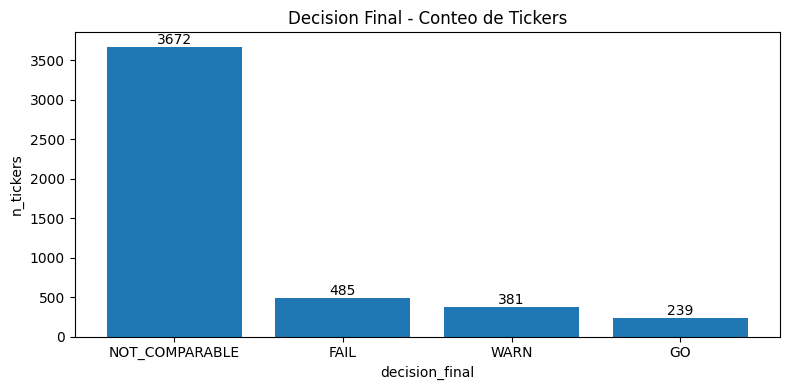

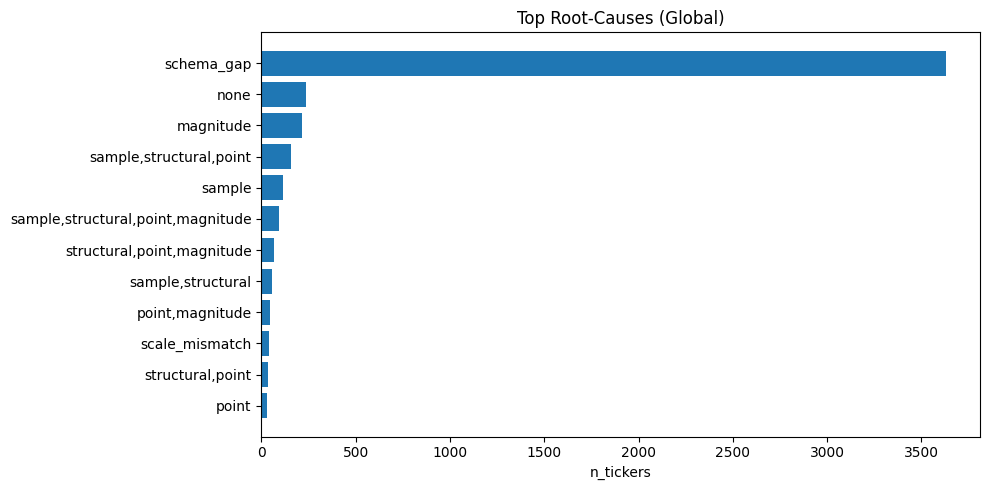

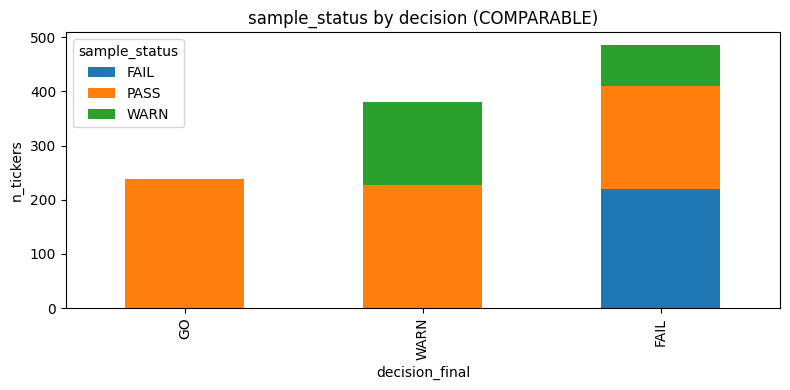

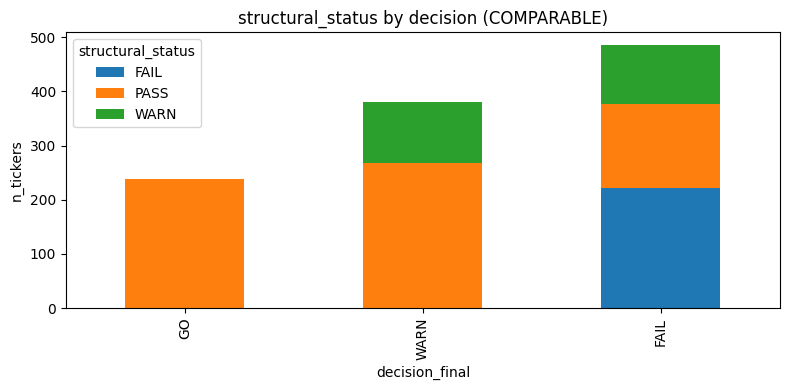

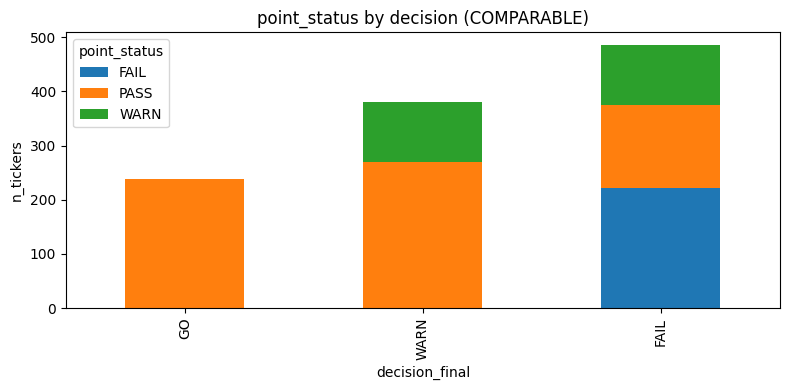

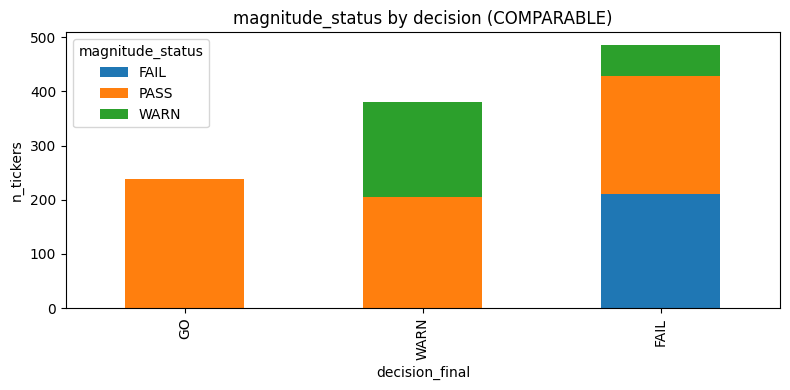


Saved diagnostic artifacts:
C:\TSIS_Data\v1\backtest_SmallCaps\runs\backtest\01_dataset_builder\datasets_final_from_06_massive\diagnostic_decision_counts.parquet
C:\TSIS_Data\v1\backtest_SmallCaps\runs\backtest\01_dataset_builder\datasets_final_from_06_massive\diagnostic_root_cause_by_decision.parquet
C:\TSIS_Data\v1\backtest_SmallCaps\runs\backtest\01_dataset_builder\datasets_final_from_06_massive\diagnostic_metric_quantiles_by_decision.parquet
C:\TSIS_Data\v1\backtest_SmallCaps\runs\backtest\01_dataset_builder\datasets_final_from_06_massive\diagnostic_policy_granular_table.parquet


In [2]:
# Diagnostico forense final de policy masiva (granular + graficos)
from pathlib import Path
import json
import polars as pl
import matplotlib.pyplot as plt

PROJECT_ROOT = Path(r"C:\TSIS_Data\v1\backtest_SmallCaps")
ROOT = PROJECT_ROOT / "runs" / "backtest" / "01_dataset_builder"
POLICY_FP = ROOT / "universe_policy_final_from_06_massive.parquet"
MANIFEST_FP = ROOT / "datasets_final_from_06_massive" / "final_policy_materialization_manifest.json"

if not POLICY_FP.exists():
    raise FileNotFoundError(f"No existe {POLICY_FP}")
if not MANIFEST_FP.exists():
    raise FileNotFoundError(f"No existe {MANIFEST_FP}")

policy = pl.read_parquet(POLICY_FP)
manifest = json.loads(MANIFEST_FP.read_text(encoding="utf-8"))

src_06_run = Path(manifest["source_06_run"])
flags_fp = src_06_run / "ticker_comparability_flags.parquet"
if not flags_fp.exists():
    raise FileNotFoundError(f"No existe {flags_fp}")
flags = pl.read_parquet(flags_fp)

# Join para tener decision final + estados por eje + metricas en una sola tabla
base = policy.join(
    flags.select([
        "ticker","sample_status","structural_status","point_status","magnitude_status",
        "coverage_global","p_overlap","p_in_range","out_dist_abs_p95","price_scale_ratio_close_over_mid",
        "diagnostic_explanation"
    ]),
    on="ticker",
    how="left",
)

N = base.height
print("policy rows:", N)

# 1) Conteos y proporciones por decision
by_decision = (
    base.group_by("decision_final")
        .len()
        .rename({"len":"n_tickers"})
        .with_columns((pl.col("n_tickers") / float(N)).alias("ratio"))
        .sort("n_tickers", descending=True)
)
print("\n[Decision counts + ratio]")
print(by_decision)

# 2) Causalidad: root cause por decision
cause_by_decision = (
    base.group_by(["decision_final","root_cause_final"])
        .len()
        .rename({"len":"n"})
        .sort(["decision_final","n"], descending=[False, True])
)
print("\n[Root-cause by decision | top 40]")
print(cause_by_decision.head(40))

# 3) Ejes: estado por axis dentro de cada decision
axis_cols = ["sample_status","structural_status","point_status","magnitude_status"]
for ax in axis_cols:
    if ax in base.columns:
        tbl = (
            base.group_by(["decision_final", ax])
                .len()
                .rename({"len":"n"})
                .sort(["decision_final","n"], descending=[False, True])
        )
        print(f"\n[Axis status] {ax}")
        print(tbl)

# 4) Cuantiles metricos por decision
metric_cols = [
    "coverage_global", "p_overlap", "p_in_range", "out_dist_abs_p95", "price_scale_ratio_close_over_mid"
]
quant_rows = []
for dec in ["GO","WARN","FAIL","NOT_COMPARABLE"]:
    sub = base.filter(pl.col("decision_final") == dec)
    if sub.height == 0:
        continue
    row = {"decision_final": dec, "n": int(sub.height)}
    for m in metric_cols:
        if m in sub.columns:
            row[f"{m}_p10"] = float(sub.select(pl.quantile(m, 0.10, "nearest")).item()) if sub.select(pl.col(m).is_not_null().sum()).item() > 0 else None
            row[f"{m}_p50"] = float(sub.select(pl.quantile(m, 0.50, "nearest")).item()) if sub.select(pl.col(m).is_not_null().sum()).item() > 0 else None
            row[f"{m}_p90"] = float(sub.select(pl.quantile(m, 0.90, "nearest")).item()) if sub.select(pl.col(m).is_not_null().sum()).item() > 0 else None
    quant_rows.append(row)

quant_df = pl.DataFrame(quant_rows)
print("\n[Metric quantiles by decision]")
print(quant_df)

# 5) Ejemplos extremos por eje (top severidad)
print("\n[Ejemplos extremos - coverage bajo]")
print(
    base.filter(pl.col("coverage_global").is_not_null())
        .sort("coverage_global")
        .select(["ticker","decision_final","root_cause_final","coverage_global","diagnostic_explanation"])
        .head(15)
)

print("\n[Ejemplos extremos - p_overlap bajo]")
print(
    base.filter(pl.col("p_overlap").is_not_null())
        .sort("p_overlap")
        .select(["ticker","decision_final","root_cause_final","p_overlap","diagnostic_explanation"])
        .head(15)
)

print("\n[Ejemplos extremos - p_in_range bajo]")
print(
    base.filter(pl.col("p_in_range").is_not_null())
        .sort("p_in_range")
        .select(["ticker","decision_final","root_cause_final","p_in_range","diagnostic_explanation"])
        .head(15)
)

print("\n[Ejemplos extremos - out_dist_abs_p95 alto]")
print(
    base.filter(pl.col("out_dist_abs_p95").is_not_null())
        .sort("out_dist_abs_p95", descending=True)
        .select(["ticker","decision_final","root_cause_final","out_dist_abs_p95","diagnostic_explanation"])
        .head(15)
)

# -----------------
# Graficos
# -----------------
# decision counts bar
d_pd = by_decision.to_pandas()
plt.figure(figsize=(8,4))
plt.bar(d_pd["decision_final"], d_pd["n_tickers"])
plt.title("Decision Final - Conteo de Tickers")
plt.xlabel("decision_final")
plt.ylabel("n_tickers")
for i, v in enumerate(d_pd["n_tickers"]):
    plt.text(i, v, str(int(v)), ha="center", va="bottom")
plt.tight_layout()
plt.show()

# root-cause top bar (global)
rc = (
    base.group_by("root_cause_final").len().rename({"len":"n"}).sort("n", descending=True).head(12)
).to_pandas()
plt.figure(figsize=(10,5))
plt.barh(rc["root_cause_final"], rc["n"])
plt.gca().invert_yaxis()
plt.title("Top Root-Causes (Global)")
plt.xlabel("n_tickers")
plt.tight_layout()
plt.show()

# axis status stacked for comparable subset
comp = base.filter(pl.col("comparability_label") == "COMPARABLE")
if comp.height > 0:
    for ax in axis_cols:
        if ax in comp.columns:
            t = comp.group_by(["decision_final", ax]).len().rename({"len":"n"}).to_pandas()
            if len(t) == 0:
                continue
            piv = t.pivot(index="decision_final", columns=ax, values="n").fillna(0)
            piv = piv.reindex(index=[x for x in ["GO","WARN","FAIL"] if x in piv.index])
            piv.plot(kind="bar", stacked=True, figsize=(8,4), title=f"{ax} by decision (COMPARABLE)")
            plt.ylabel("n_tickers")
            plt.tight_layout()
            plt.show()

# Persistir resumen diagnostico para auditoria
OUT = ROOT / "datasets_final_from_06_massive"
OUT.mkdir(parents=True, exist_ok=True)

by_decision.write_parquet(OUT / "diagnostic_decision_counts.parquet")
cause_by_decision.write_parquet(OUT / "diagnostic_root_cause_by_decision.parquet")
quant_df.write_parquet(OUT / "diagnostic_metric_quantiles_by_decision.parquet")
base.select([
    "ticker","decision_final","root_cause_final","comparability_label",
    "sample_status","structural_status","point_status","magnitude_status",
    "coverage_global","p_overlap","p_in_range","out_dist_abs_p95","price_scale_ratio_close_over_mid",
    "diagnostic_explanation"
]).write_parquet(OUT / "diagnostic_policy_granular_table.parquet")

print("\nSaved diagnostic artifacts:")
print(OUT / "diagnostic_decision_counts.parquet")
print(OUT / "diagnostic_root_cause_by_decision.parquet")
print(OUT / "diagnostic_metric_quantiles_by_decision.parquet")
print(OUT / "diagnostic_policy_granular_table.parquet")


### Siguiente paso (mi recomendacion)

Mi siguiente paso en este punto es cerrar un **plan de remediacion por cohorts**, no por ticker aislado:

1. **Cohort A: NOT_COMPARABLE**
- Subsegmentar por causa tecnica dominante y crear reglas de rescate (schema/escala/alineacion).
- Objetivo: convertir parte de `NOT_COMPARABLE` en `COMPARABLE` con controles estrictos.

2. **Cohort B: FAIL (comparables)**
- Priorizar por eje fallido dominante (`sample`, `structural`, `point`, `magnitude`).
- Objetivo: reducir `FAIL` con correcciones de data engineering y criterios de QA.

3. **Cohort C: WARN**
- Definir guardrails operativos (peso, riesgo, filtros de ejecucion) para uso en `relaxed`.

4. **Iteracion**
- Re-ejecutar 03/06 masivo tras remediacion y medir delta contra esta baseline final.

Razon metodologica:
- Este enfoque maximiza impacto porque corrige causas sistemicas de muchos tickers a la vez.
- Evita sobreajuste ad-hoc ticker-a-ticker sin ganancia estructural en el universo.


### Plan operativo por cohorts (A/B/C) con reglas accionables

Este bloque operacionaliza la remediacion en tres cohortes sobre la tabla final (`diagnostic_policy_granular_table.parquet`):

**Cohort A: NOT_COMPARABLE**
- Subsegmentacion por causa dominante: `schema`, `scale`, `alignment_join`, `missing_data`, `other`.
- Se asigna una regla de rescate por subcohorte y controles estrictos de reingreso.

**Cohort B: FAIL (comparables)**
- Priorizacion por eje fallido dominante (`sample`, `structural`, `point`, `magnitude`).
- Se propone remediacion tecnica por eje y un orden de ejecucion.

**Cohort C: WARN**
- Definicion de guardrails para uso en `relaxed`:
  - peso de calidad,
  - limite de posicion,
  - penalizacion de slippage,
  - filtro de ejecucion.

Salida:
- `cohort_A_not_comparable_actions.parquet`
- `cohort_B_fail_actions.parquet`
- `cohort_C_warn_guardrails.parquet`
- `cohort_execution_summary.json`


In [3]:
# Cohorts A/B/C: tablas accionables y guardrails
from pathlib import Path
import json
import polars as pl

PROJECT_ROOT = Path(r"C:\TSIS_Data\v1\backtest_SmallCaps")
BASE = PROJECT_ROOT / "runs" / "backtest" / "01_dataset_builder" / "datasets_final_from_06_massive"
DIAG_FP = BASE / "diagnostic_policy_granular_table.parquet"

if not DIAG_FP.exists():
    raise FileNotFoundError(f"No existe {DIAG_FP}. Ejecuta primero la celda de diagnostico forense.")

df = pl.read_parquet(DIAG_FP)

# ----------
# Cohort A: NOT_COMPARABLE
# ----------
a = df.filter(pl.col("decision_final") == "NOT_COMPARABLE")

# Clasificacion de causa tecnica dominante
a = a.with_columns([
    pl.when(pl.col("root_cause_final").str.contains("schema|missing|no_join|no_", literal=False)).then(pl.lit("schema_or_missing"))
      .when(pl.col("root_cause_final").str.contains("scale", literal=False)).then(pl.lit("scale_mismatch"))
      .when(pl.col("root_cause_final").str.contains("sample|coverage|join|alignment|struct", literal=False)).then(pl.lit("alignment_or_sample"))
      .otherwise(pl.lit("other_not_comparable")).alias("a_subcohort")
])

a = a.with_columns([
    pl.when(pl.col("a_subcohort") == "schema_or_missing").then(pl.lit("rebuild_schema_mapping_and_required_columns"))
      .when(pl.col("a_subcohort") == "scale_mismatch").then(pl.lit("apply_scale_normalization_and_corporate_actions_check"))
      .when(pl.col("a_subcohort") == "alignment_or_sample").then(pl.lit("recompute_time_alignment_and_min_coverage_gate"))
      .otherwise(pl.lit("manual_forensic_review")).alias("rescue_rule"),

    pl.when(pl.col("a_subcohort") == "schema_or_missing").then(pl.lit("strict: require schema completeness + successful minute join"))
      .when(pl.col("a_subcohort") == "scale_mismatch").then(pl.lit("strict: abs(scale_ratio-1)<=0.05 and stable across months"))
      .when(pl.col("a_subcohort") == "alignment_or_sample").then(pl.lit("strict: coverage>=0.85 and p_overlap>=0.97"))
      .otherwise(pl.lit("strict: human approval + rerun QA"))
      .alias("strict_reentry_controls"),

    pl.when(pl.col("a_subcohort") == "scale_mismatch").then(pl.lit("P1"))
      .when(pl.col("a_subcohort") == "alignment_or_sample").then(pl.lit("P2"))
      .when(pl.col("a_subcohort") == "schema_or_missing").then(pl.lit("P1"))
      .otherwise(pl.lit("P3")).alias("priority")
])

cohort_a = a.select([
    "ticker","decision_final","root_cause_final","a_subcohort","priority","rescue_rule","strict_reentry_controls",
    "coverage_global","p_overlap","p_in_range","out_dist_abs_p95","price_scale_ratio_close_over_mid"
]).sort(["priority","a_subcohort","ticker"])

# ----------
# Cohort B: FAIL (comparables)
# ----------
b = df.filter((pl.col("decision_final") == "FAIL") & (pl.col("comparability_label") == "COMPARABLE"))

# Eje fallido dominante
b = b.with_columns([
    pl.when(pl.col("sample_status") == "FAIL").then(pl.lit("sample"))
      .when(pl.col("structural_status") == "FAIL").then(pl.lit("structural"))
      .when(pl.col("point_status") == "FAIL").then(pl.lit("point"))
      .when(pl.col("magnitude_status") == "FAIL").then(pl.lit("magnitude"))
      .otherwise(pl.lit("mixed_or_warn_only")).alias("b_primary_failed_axis")
])

b = b.with_columns([
    pl.when(pl.col("b_primary_failed_axis") == "sample").then(pl.lit("improve_coverage_and_truncation_controls"))
      .when(pl.col("b_primary_failed_axis") == "structural").then(pl.lit("audit_ohlcv_quote_structural_coherence"))
      .when(pl.col("b_primary_failed_axis") == "point").then(pl.lit("refine_point_execution_alignment"))
      .when(pl.col("b_primary_failed_axis") == "magnitude").then(pl.lit("robust_outlier_and_distance_filters"))
      .otherwise(pl.lit("manual_multiaxis_review")).alias("remediation_rule"),

    pl.when(pl.col("b_primary_failed_axis") == "sample").then(pl.lit("P1"))
      .when(pl.col("b_primary_failed_axis") == "structural").then(pl.lit("P1"))
      .when(pl.col("b_primary_failed_axis") == "point").then(pl.lit("P2"))
      .when(pl.col("b_primary_failed_axis") == "magnitude").then(pl.lit("P2"))
      .otherwise(pl.lit("P3")).alias("priority")
])

cohort_b = b.select([
    "ticker","decision_final","root_cause_final","b_primary_failed_axis","priority","remediation_rule",
    "sample_status","structural_status","point_status","magnitude_status",
    "coverage_global","p_overlap","p_in_range","out_dist_abs_p95"
]).sort(["priority","b_primary_failed_axis","ticker"])

# ----------
# Cohort C: WARN (guardrails relaxed)
# ----------
c = df.filter((pl.col("decision_final") == "WARN") & (pl.col("comparability_label") == "COMPARABLE"))

c = c.with_columns([
    # riesgo base por severidad de ejes WARN
    (
        (pl.when(pl.col("sample_status") == "WARN").then(pl.lit(1)).otherwise(pl.lit(0))) +
        (pl.when(pl.col("structural_status") == "WARN").then(pl.lit(1)).otherwise(pl.lit(0))) +
        (pl.when(pl.col("point_status") == "WARN").then(pl.lit(1)).otherwise(pl.lit(0))) +
        (pl.when(pl.col("magnitude_status") == "WARN").then(pl.lit(1)).otherwise(pl.lit(0)))
    ).alias("warn_axes_count")
])

c = c.with_columns([
    pl.when(pl.col("warn_axes_count") >= 3).then(pl.lit(0.35))
      .when(pl.col("warn_axes_count") == 2).then(pl.lit(0.50))
      .otherwise(pl.lit(0.65)).alias("quality_weight_relaxed"),

    pl.when(pl.col("warn_axes_count") >= 3).then(pl.lit(0.005))
      .when(pl.col("warn_axes_count") == 2).then(pl.lit(0.010))
      .otherwise(pl.lit(0.015)).alias("max_position_fraction"),

    pl.when(pl.col("warn_axes_count") >= 3).then(pl.lit(20))
      .when(pl.col("warn_axes_count") == 2).then(pl.lit(12))
      .otherwise(pl.lit(8)).alias("slippage_bps_penalty"),

    pl.when((pl.col("point_status") == "WARN") | (pl.col("magnitude_status") == "WARN"))
      .then(pl.lit("limit_or_passive_only"))
      .otherwise(pl.lit("standard_with_spread_check")).alias("execution_guardrail")
])

cohort_c = c.select([
    "ticker","decision_final","root_cause_final","warn_axes_count",
    "quality_weight_relaxed","max_position_fraction","slippage_bps_penalty","execution_guardrail",
    "sample_status","structural_status","point_status","magnitude_status",
    "coverage_global","p_overlap","p_in_range","out_dist_abs_p95"
]).sort(["warn_axes_count","ticker"], descending=[True, False])

# ----------
# Resumen y persistencia
# ----------
out_a = BASE / "cohort_A_not_comparable_actions.parquet"
out_b = BASE / "cohort_B_fail_actions.parquet"
out_c = BASE / "cohort_C_warn_guardrails.parquet"
out_summary = BASE / "cohort_execution_summary.json"

cohort_a.write_parquet(out_a)
cohort_b.write_parquet(out_b)
cohort_c.write_parquet(out_c)

summary = {
    "generated_at_utc": str(pl.datetime_range(start=None, end=None, interval='1d').cast(pl.Utf8).head(0)),
    "input_diagnostic_table": str(DIAG_FP),
    "cohort_counts": {
        "A_not_comparable": int(cohort_a.height),
        "B_fail_comparable": int(cohort_b.height),
        "C_warn_comparable": int(cohort_c.height),
    },
    "A_subcohort_counts": cohort_a.group_by("a_subcohort").len().sort("len", descending=True).to_dicts() if cohort_a.height else [],
    "B_axis_counts": cohort_b.group_by("b_primary_failed_axis").len().sort("len", descending=True).to_dicts() if cohort_b.height else [],
    "C_warn_axes_counts": cohort_c.group_by("warn_axes_count").len().sort("warn_axes_count", descending=True).to_dicts() if cohort_c.height else [],
    "outputs": {
        "cohort_A": str(out_a),
        "cohort_B": str(out_b),
        "cohort_C": str(out_c),
    }
}

# datetime in plain python for summary
import datetime as _dt
summary["generated_at_utc"] = _dt.datetime.utcnow().isoformat() + "Z"
out_summary.write_text(json.dumps(summary, indent=2), encoding="utf-8")

print("[Cohort counts]")
print(summary["cohort_counts"])

print("\n[A subcohort counts]")
print(pl.DataFrame(summary["A_subcohort_counts"]))

print("\n[B axis counts]")
print(pl.DataFrame(summary["B_axis_counts"]))

print("\n[C warn axes counts]")
print(pl.DataFrame(summary["C_warn_axes_counts"]))

print("\nSaved:")
print(out_a)
print(out_b)
print(out_c)
print(out_summary)


[Cohort counts]
{'A_not_comparable': 3672, 'B_fail_comparable': 485, 'C_warn_comparable': 381}

[A subcohort counts]
shape: (2, 2)
┌───────────────────┬──────┐
│ a_subcohort       ┆ len  │
│ ---               ┆ ---  │
│ str               ┆ i64  │
╞═══════════════════╪══════╡
│ schema_or_missing ┆ 3629 │
│ scale_mismatch    ┆ 43   │
└───────────────────┴──────┘

[B axis counts]
shape: (4, 2)
┌───────────────────────┬─────┐
│ b_primary_failed_axis ┆ len │
│ ---                   ┆ --- │
│ str                   ┆ i64 │
╞═══════════════════════╪═════╡
│ sample                ┆ 220 │
│ magnitude             ┆ 135 │
│ structural            ┆ 99  │
│ point                 ┆ 31  │
└───────────────────────┴─────┘

[C warn axes counts]
shape: (4, 2)
┌─────────────────┬─────┐
│ warn_axes_count ┆ len │
│ ---             ┆ --- │
│ i64             ┆ i64 │
╞═════════════════╪═════╡
│ 4               ┆ 8   │
│ 3               ┆ 32  │
│ 2               ┆ 84  │
│ 1               ┆ 257 │
└───────────────

### Interpretacion didactica de Cohorts A/B/C (para lectura no tecnica)

**Que son A, B y C**
- **A = NOT_COMPARABLE**: tickers que, con la informacion actual, no se pueden comparar de forma fiable con el marco OHLCV-vs-quotes.
- **B = FAIL (comparables)**: tickers que si son comparables, pero fallan controles de calidad relevantes.
- **C = WARN (comparables)**: tickers comparables con riesgo moderado; pueden usarse con restricciones.

**Resultados del bloque actual**
- `A_not_comparable = 3672`
- `B_fail_comparable = 485`
- `C_warn_comparable = 381`

Esto significa que el cuello principal no esta en ajustes finos de estrategia, sino en que muchos tickers no pasan el criterio minimo de comparabilidad tecnica.

---

**A subcohorts (detalle de A)**
- `schema_or_missing: 3629`
- `scale_mismatch: 43`

Que significa cada etiqueta:
- **schema_or_missing**: faltan columnas/estructuras necesarias o no hay informacion suficiente para construir el join de forma robusta.
  Ejemplo: no se puede alinear correctamente minuto a minuto por falta de campos clave.
- **scale_mismatch**: la escala de precios entre fuentes no cuadra (por ejemplo, factor de ajuste, split, corporate actions o normalizacion inconsistente).

Lectura operativa:
- Casi todo el problema de A viene de `schema_or_missing`; por eso la prioridad es de data engineering (completitud y mapeo), no de tuning de umbrales.

---

**B ejes fallidos dominantes (detalle de B)**
- `sample: 220` (prioridad 1)
- `magnitude: 135`
- `structural: 99`
- `point: 31`

Que significa cada eje:
- **sample**: problema de muestra/cobertura (dias o minutos insuficientes, truncados, representatividad pobre).
- **magnitude**: desviaciones absolutas grandes (colas/outliers en distancia respecto a referencia).
- **structural**: incoherencia estructural entre OHLCV y quotes (solape/rango no consistente).
- **point**: friccion puntual en el matching de precios minuto a minuto.

Lectura operativa:
- La mayor parte de FAIL comparable esta explicada por `sample`; la segunda palanca es `magnitude`.

---

**C severidad WARN (`warn_axes_count`)**
- `1 eje: 257` (mayoria, riesgo moderado)
- `2 ejes: 84`
- `3 ejes: 32`
- `4 ejes: 8` (alto riesgo dentro de WARN)

Que significa `warn_axes_count`:
- Es el numero de ejes (sample/structural/point/magnitude) que quedaron en estado `WARN` para un ticker.
- Cuantos mas ejes en WARN, mas restrictivo debe ser su uso en `relaxed`.

Lectura operativa:
- El grueso de WARN tiene solo 1 eje en riesgo, por lo que es util para universo `relaxed` con guardrails.
- El subgrupo con 3-4 ejes requiere limites mas duros de peso/ejecucion.

---

**Conclusiones practicas inmediatas**
1. Prioridad global: resolver `A/schema_or_missing` para convertir volumen relevante de universo a comparable.
2. Prioridad en comparables FAIL: atacar `sample` primero, luego `magnitude`.
3. Uso de WARN: aplicar guardrails por severidad (`warn_axes_count`) en backtest/ML para controlar riesgo sin perder informacion.

---

**Seguimos...**

1. Abro y ejecuto estas tablas de salida para acción:
    - ...datasets_final_from_06_massive\cohort_A_not_comparable_actions.parquet
    - ...datasets_final_from_06_massive\cohort_B_fail_actions.parquet
    - ...datasets_final_from_06_massive\cohort_C_warn_guardrails.parquet
2. Aplico ya cohort_C_warn_guardrails al pipeline relaxed (esto da valor inmediato).
3. En paralelo, inicia remediación de A/schema_or_missing (es el 99% de A): ese es el mayor retorno.
4. Después de esa remediación, reejecutamos 03+06 masivo y medimos delta contra esta baseline.

### Aplicacion operativa de guardrails Cohort C sobre `relaxed`

Este bloque aplica automaticamente `cohort_C_warn_guardrails.parquet` al dataset `relaxed` final.

Que hace:
- Cruza por `ticker` los guardrails de WARN sobre `dataset_final_relaxed.parquet`.
- Para tickers no-WARN (GO) asigna defaults conservadores de operacion.
- Produce un dataset listo para backtest/ML con columnas de control de riesgo por ticker.

Salida:
- `dataset_final_relaxed_guardrailed.parquet`
- `dataset_final_relaxed_guardrailed_manifest.json`


In [1]:
# Aplicar guardrails de Cohort C al dataset relaxed final
from pathlib import Path
from datetime import datetime, timezone
import json
import polars as pl

PROJECT_ROOT = Path(r"C:\TSIS_Data\v1\backtest_SmallCaps")
BASE = PROJECT_ROOT / "runs" / "backtest" / "01_dataset_builder" / "datasets_final_from_06_massive"

RELAXED_FP = BASE / "dataset_final_relaxed.parquet"
GUARDRAILS_FP = BASE / "cohort_C_warn_guardrails.parquet"
OUT_FP = BASE / "dataset_final_relaxed_guardrailed.parquet"
MANIFEST_FP = BASE / "dataset_final_relaxed_guardrailed_manifest.json"

if not RELAXED_FP.exists():
    raise FileNotFoundError(f"No existe {RELAXED_FP}")
if not GUARDRAILS_FP.exists():
    raise FileNotFoundError(f"No existe {GUARDRAILS_FP}")

relaxed = pl.read_parquet(RELAXED_FP)
guard = pl.read_parquet(GUARDRAILS_FP)

# Guardrails por ticker para WARN; GO queda con defaults
guard_cols = [
    "ticker",
    "warn_axes_count",
    "quality_weight_relaxed",
    "max_position_fraction",
    "slippage_bps_penalty",
    "execution_guardrail",
]
guard_map = guard.select([c for c in guard_cols if c in guard.columns]).unique(subset=["ticker"], keep="first")

out = relaxed.join(guard_map, on="ticker", how="left")

# Defaults para tickers relaxed no presentes en cohort C (normalmente GO)
out = out.with_columns([
    pl.col("warn_axes_count").fill_null(0),
    pl.col("quality_weight_relaxed").fill_null(pl.col("quality_weight")).fill_null(1.0),
    pl.col("max_position_fraction").fill_null(0.02),
    pl.col("slippage_bps_penalty").fill_null(5),
    pl.col("execution_guardrail").fill_null("standard"),
])

# score operativo final (combina calidad base y penalizacion relaxed)
out = out.with_columns([
    (pl.col("quality_weight") * pl.col("quality_weight_relaxed")).alias("effective_quality_weight"),
    pl.when(pl.col("warn_axes_count") >= 3).then(pl.lit("high"))
      .when(pl.col("warn_axes_count") == 2).then(pl.lit("medium"))
      .otherwise(pl.lit("low")).alias("warn_risk_bucket")
])

out = out.sort(["ticker", "year", "month"]) if set(["ticker","year","month"]).issubset(set(out.columns)) else out.sort("ticker")
out.write_parquet(OUT_FP)

manifest = {
    "generated_at_utc": datetime.now(timezone.utc).isoformat(),
    "source_relaxed": str(RELAXED_FP),
    "source_guardrails": str(GUARDRAILS_FP),
    "output": str(OUT_FP),
    "rows_in": int(relaxed.height),
    "rows_out": int(out.height),
    "tickers_in": int(relaxed.select(pl.col("ticker").n_unique()).item()) if relaxed.height else 0,
    "tickers_out": int(out.select(pl.col("ticker").n_unique()).item()) if out.height else 0,
    "warn_risk_bucket_counts": out.group_by("warn_risk_bucket").len().sort("warn_risk_bucket").to_dicts(),
    "execution_guardrail_counts": out.group_by("execution_guardrail").len().sort("execution_guardrail").to_dicts(),
}
MANIFEST_FP.write_text(json.dumps(manifest, indent=2), encoding="utf-8")

print("Saved:", OUT_FP)
print("Saved:", MANIFEST_FP)
print("shape:", out.shape)
print("\nwarn_risk_bucket counts:")
print(out.group_by("warn_risk_bucket").len().sort("warn_risk_bucket"))
print("\nexecution_guardrail counts:")
print(out.group_by("execution_guardrail").len().sort("execution_guardrail"))


Saved: C:\TSIS_Data\v1\backtest_SmallCaps\runs\backtest\01_dataset_builder\datasets_final_from_06_massive\dataset_final_relaxed_guardrailed.parquet
Saved: C:\TSIS_Data\v1\backtest_SmallCaps\runs\backtest\01_dataset_builder\datasets_final_from_06_massive\dataset_final_relaxed_guardrailed_manifest.json
shape: (15986, 26)

warn_risk_bucket counts:
shape: (3, 2)
┌──────────────────┬───────┐
│ warn_risk_bucket ┆ len   │
│ ---              ┆ ---   │
│ str              ┆ u32   │
╞══════════════════╪═══════╡
│ high             ┆ 697   │
│ low              ┆ 13344 │
│ medium           ┆ 1945  │
└──────────────────┴───────┘

execution_guardrail counts:
shape: (3, 2)
┌────────────────────────────┬──────┐
│ execution_guardrail        ┆ len  │
│ ---                        ┆ ---  │
│ str                        ┆ u32  │
╞════════════════════════════╪══════╡
│ limit_or_passive_only      ┆ 5390 │
│ standard                   ┆ 6973 │
│ standard_with_spread_check ┆ 3623 │
└────────────────────────────┴─

### Interpretacion de `warn_risk_bucket` y `execution_guardrail`

**Que estas viendo**
Estos conteos no son numero de tickers, sino numero de filas del dataset `dataset_final_relaxed_guardrailed.parquet` (nivel ticker-mes).

---

**1) `warn_risk_bucket`**

Definicion:
- `low`: ticker con 0-1 ejes en WARN (riesgo bajo/moderado).
- `medium`: ticker con 2 ejes en WARN (riesgo intermedio).
- `high`: ticker con 3-4 ejes en WARN (riesgo alto dentro del universo relaxed).

Resultados:
- `low = 13344`
- `medium = 1945`
- `high = 697`

Lectura operativa:
- La mayor parte del universo relaxed cae en `low`.
- `medium` y `high` son subconjuntos donde se debe limitar mas peso y exigir ejecucion mas conservadora.

Uso recomendado:
- `low`: uso normal en relaxed con controles estandar.
- `medium`: reducir peso por posicion + mayor penalizacion de slippage.
- `high`: peso minimo y filtros mas estrictos de entrada/salida.

---

**2) `execution_guardrail`**

Definicion:
- `standard`: ejecucion normal (sin restriccion adicional por warning critico).
- `standard_with_spread_check`: ejecucion normal pero condicionada a spread aceptable.
- `limit_or_passive_only`: evitar agresion de mercado; usar ordenes limitadas/pasivas.

Resultados:
- `standard = 6973`
- `standard_with_spread_check = 3623`
- `limit_or_passive_only = 5390`

Lectura operativa:
- Un bloque relevante (`5390`) requiere ejecucion pasiva/limit para controlar coste de microestructura.
- `3623` requiere control de spread para evitar fills caros.
- `6973` puede seguir flujo estandar.

---

**Implicacion practica para backtest y ML**
1. No tratar todo `relaxed` igual: usar `warn_risk_bucket` como variable de riesgo y de weighting.
2. Incorporar `execution_guardrail` en simulacion de ejecucion:
- `limit_or_passive_only`: mayor probabilidad de no-fill pero mejor control de slippage.
- `standard_with_spread_check`: filtrar o penalizar cuando spread supere umbral.
3. En ML, incluir ambas columnas como features/reglas de post-procesado para evitar sobreestimar performance en condiciones de microestructura adversa.


### Reglas exactas de `strict` vs `relaxed` vs `relaxed_guardrailed` (transparencia total)

Este bloque muestra de forma auditable:
- Que se relaja exactamente al pasar de `strict` a `relaxed`.
- Que restricciones adicionales se imponen en `relaxed_guardrailed` para `WARN`.
- Como se aplica por ticker (explicacion + metricas + guardrails).

Definicion formal:
- `strict`: solo tickers con `decision_final = GO`.
- `relaxed`: tickers con `decision_final in {GO, WARN}`.
- `relaxed_guardrailed`: mismo conjunto que `relaxed`, pero con controles de riesgo/ejecucion por ticker.

Mapeo de politica:
- `GO` -> `ALLOW`
- `WARN` -> `ALLOW_WITH_RESTRICTIONS`
- `FAIL` / `NOT_COMPARABLE` -> `BLOCK`


In [2]:
# Reglas explicitas + graficos globales de relajacion
from pathlib import Path
import json
import polars as pl
import sys
import matplotlib
# Evita popups flotantes fuera de Jupyter
_IS_NOTEBOOK = ("ipykernel" in sys.modules)
if not _IS_NOTEBOOK:
    matplotlib.use("Agg")
import matplotlib.pyplot as plt
if not _IS_NOTEBOOK:
    plt.ioff()

def _show_or_close():
    if _IS_NOTEBOOK:
        plt.show()
    else:
        plt.close()

PROJECT_ROOT = Path(r"C:\TSIS_Data\v1\backtest_SmallCaps")
BASE = PROJECT_ROOT / "runs" / "backtest" / "01_dataset_builder" / "datasets_final_from_06_massive"

POLICY_FP = PROJECT_ROOT / "runs" / "backtest" / "01_dataset_builder" / "universe_policy_final_from_06_massive.parquet"
STRICT_FP = BASE / "dataset_final_strict.parquet"
RELAXED_FP = BASE / "dataset_final_relaxed.parquet"
RELAXED_G_FP = BASE / "dataset_final_relaxed_guardrailed.parquet"
MANIFEST_FP = BASE / "dataset_final_relaxed_guardrailed_manifest.json"

for fp in [POLICY_FP, STRICT_FP, RELAXED_FP, RELAXED_G_FP]:
    if not fp.exists():
        raise FileNotFoundError(f"No existe {fp}")

policy = pl.read_parquet(POLICY_FP)
strict = pl.read_parquet(STRICT_FP)
relaxed = pl.read_parquet(RELAXED_FP)
relaxed_g = pl.read_parquet(RELAXED_G_FP)
manifest = json.loads(MANIFEST_FP.read_text(encoding='utf-8')) if MANIFEST_FP.exists() else {}


PLOTS_DIR = BASE / "figures_relaxed_rules"
PLOTS_DIR.mkdir(parents=True, exist_ok=True)
saved_plots = []

# Tabla explicita de reglas
rules_df = pl.DataFrame([
    {
        "layer": "strict",
        "inclusion_rule": "decision_final == GO",
        "policy_action": "ALLOW",
        "risk_controls": "baseline quality_weight",
        "execution_controls": "standard",
    },
    {
        "layer": "relaxed",
        "inclusion_rule": "decision_final in {GO, WARN}",
        "policy_action": "ALLOW + ALLOW_WITH_RESTRICTIONS",
        "risk_controls": "baseline quality_weight",
        "execution_controls": "mixed (requires guardrails)",
    },
    {
        "layer": "relaxed_guardrailed",
        "inclusion_rule": "same as relaxed",
        "policy_action": "ALLOW + ALLOW_WITH_RESTRICTIONS",
        "risk_controls": "effective_quality_weight + max_position_fraction + slippage_bps_penalty",
        "execution_controls": "execution_guardrail per ticker",
    },
])
print("[Reglas formales]")
print(rules_df)

# Conteos globales
policy_counts = policy.group_by("decision_final").len().sort("decision_final")
print("\n[Decision final counts]")
print(policy_counts)

strict_t = int(strict.select(pl.col("ticker").n_unique()).item()) if strict.height else 0
relaxed_t = int(relaxed.select(pl.col("ticker").n_unique()).item()) if relaxed.height else 0
relaxed_g_t = int(relaxed_g.select(pl.col("ticker").n_unique()).item()) if relaxed_g.height else 0

summary_df = pl.DataFrame([
    {"dataset": "strict", "rows": int(strict.height), "tickers": strict_t},
    {"dataset": "relaxed", "rows": int(relaxed.height), "tickers": relaxed_t},
    {"dataset": "relaxed_guardrailed", "rows": int(relaxed_g.height), "tickers": relaxed_g_t},
])
print("\n[Dataset sizes]")
print(summary_df)

# Graficos 1: decision distribution
pc = policy_counts.to_pandas()
plt.figure(figsize=(7,4))
plt.bar(pc["decision_final"], pc["len"])
plt.title("Decision Final Distribution")
plt.xlabel("decision_final")
plt.ylabel("tickers")
for i, v in enumerate(pc["len"]):
    plt.text(i, v, str(int(v)), ha="center", va="bottom")
plt.tight_layout()
fp = PLOTS_DIR / "decision_final_distribution.png"
plt.savefig(fp, dpi=140, bbox_inches='tight')
saved_plots.append(str(fp))
_show_or_close()

# Graficos 2: dataset sizes rows/tickers
sd = summary_df.to_pandas()
fig, ax = plt.subplots(1,2, figsize=(10,4))
ax[0].bar(sd["dataset"], sd["rows"])
ax[0].set_title("Rows by dataset")
ax[0].set_ylabel("rows")
for i,v in enumerate(sd["rows"]):
    ax[0].text(i, v, str(int(v)), ha='center', va='bottom')

ax[1].bar(sd["dataset"], sd["tickers"])
ax[1].set_title("Tickers by dataset")
ax[1].set_ylabel("tickers")
for i,v in enumerate(sd["tickers"]):
    ax[1].text(i, v, str(int(v)), ha='center', va='bottom')

plt.tight_layout()
fp = PLOTS_DIR / "dataset_sizes_rows_tickers.png"
plt.savefig(fp, dpi=140, bbox_inches='tight')
saved_plots.append(str(fp))
_show_or_close()

# Graficos 3: guardrails distribution
for col, title in [
    ("warn_risk_bucket", "Warn Risk Bucket (relaxed_guardrailed)"),
    ("execution_guardrail", "Execution Guardrail (relaxed_guardrailed)")
]:
    g = relaxed_g.group_by(col).len().sort("len", descending=True).to_pandas()
    plt.figure(figsize=(8,4))
    plt.bar(g[col], g["len"])
    plt.title(title)
    plt.ylabel("rows")
    for i,v in enumerate(g["len"]):
        plt.text(i, v, str(int(v)), ha='center', va='bottom')
    plt.xticks(rotation=15)
    plt.tight_layout()
    fp = PLOTS_DIR / f"guardrail_{col}.png"
    plt.savefig(fp, dpi=140, bbox_inches='tight')
    saved_plots.append(str(fp))
    _show_or_close()

print("\nSaved plots:")
for _p in saved_plots:
    print(_p)

print("\nManifest source:", MANIFEST_FP)
if manifest:
    print("Manifest outputs:", manifest.get("output", {}))


[Reglas formales]
shape: (3, 5)
┌───────────────────┬───────────────────┬───────────────────┬───────────────────┬──────────────────┐
│ layer             ┆ inclusion_rule    ┆ policy_action     ┆ risk_controls     ┆ execution_contro │
│ ---               ┆ ---               ┆ ---               ┆ ---               ┆ ls               │
│ str               ┆ str               ┆ str               ┆ str               ┆ ---              │
│                   ┆                   ┆                   ┆                   ┆ str              │
╞═══════════════════╪═══════════════════╪═══════════════════╪═══════════════════╪══════════════════╡
│ strict            ┆ decision_final == ┆ ALLOW             ┆ baseline          ┆ standard         │
│                   ┆ GO                ┆                   ┆ quality_weight    ┆                  │
│ relaxed           ┆ decision_final in ┆ ALLOW + ALLOW_WIT ┆ baseline          ┆ mixed (requires  │
│                   ┆ {GO, WARN}        ┆ H_RESTRICTION…   

<a id="bloque-8"></a>

**Bloque 8) Visor Por Ticker Y Material Didactico QA**

Que hace: Inspeccion unificada por ticker con metricas, causa raiz y graficos intradia/tick-level.
Porque: Validar que la decision automatica tiene evidencia microestructural interpretable.
Que proporciona: Herramienta de depuracion y explicabilidad por ticker.
Vinculos: Soporte de analisis para ajustes de reglas y umbrales.
Derivadas: Acelera diagnostico granular y revisiones metodologicas.


In [1]:
# Visor unificado por ticker: reglas + explicacion causal + metricas QA + graficos + ejemplo real intradia
from pathlib import Path
import sys
import polars as pl
import matplotlib
from datetime import timedelta

_IS_NOTEBOOK = ("ipykernel" in sys.modules)
if not _IS_NOTEBOOK:
    matplotlib.use("Agg")
import matplotlib.pyplot as plt
if not _IS_NOTEBOOK:
    plt.ioff()

import pandas as pd
pd.set_option("display.max_columns", None)
pd.set_option("display.max_colwidth", None)
pd.set_option("display.width", 1000)

try:
    import ipywidgets as widgets
    from IPython.display import display
    _W_OK = True
except Exception:
    _W_OK = False


def _show_or_close():
    if _IS_NOTEBOOK:
        plt.show()
    else:
        plt.close()


def explain_root_cause(cause: str) -> str:
    c = (cause or "").lower()
    parts = [x.strip() for x in c.split(",") if x.strip()]
    if not parts:
        return "No se detecto causa raiz dominante; ticker estable en los ejes evaluados."
    mapping = {
        "magnitude": "magnitude: la desviacion fuera de rango existe y su tamano (out_dist_abs_p95) es material para ejecucion.",
        "sample": "sample: problema de cobertura/representatividad temporal (coverage/truncados/join insuficiente).",
        "structural": "structural: incoherencia de estructura OHLCV vs quotes (solape insuficiente p_overlap).",
        "point": "point: friccion puntual del precio (last_mid fuera de [low,high] con frecuencia elevada).",
        "scale": "scale: desajuste de escala entre fuentes (ratio close/mid lejos de 1).",
        "none": "none: sin causa raiz activa en ejes QA.",
    }
    return "\n".join([mapping.get(p, f"{p}: causa no catalogada, requiere inspeccion puntual.") for p in parts])


def infer_time_unit_from_magnitude(x: int) -> str:
    ax = abs(int(x))
    if ax >= 10**17:
        return "ns"
    if ax >= 10**14:
        return "us"
    if ax >= 10**11:
        return "ms"
    return "s"


def to_ny_datetime(df: pl.DataFrame, col: str) -> pl.Expr:
    dt = df.schema[col]
    if dt in (pl.Int64, pl.Int32, pl.UInt64, pl.UInt32):
        sample = int(df.select(pl.col(col).median()).item())
        unit = infer_time_unit_from_magnitude(sample)
        return pl.from_epoch(pl.col(col), time_unit=unit).dt.replace_time_zone("UTC").dt.convert_time_zone("America/New_York")
    # datetime path
    return pl.col(col).cast(pl.Datetime).dt.replace_time_zone("UTC").dt.convert_time_zone("America/New_York")


PROJECT_ROOT = Path(r"C:\TSIS_Data\v1\backtest_SmallCaps")
DATA_ROOT = Path(r"C:\TSIS_Data\data")
BASE = PROJECT_ROOT / "runs" / "backtest" / "01_dataset_builder" / "datasets_final_from_06_massive"
POLICY_FP = PROJECT_ROOT / "runs" / "backtest" / "01_dataset_builder" / "universe_policy_final_from_06_massive.parquet"
RELAXED_G_FP = BASE / "dataset_final_relaxed_guardrailed.parquet"
FIG_DIR = BASE / "figures_ticker_unified"
FIG_DIR.mkdir(parents=True, exist_ok=True)

policy = pl.read_parquet(POLICY_FP)
rg = pl.read_parquet(RELAXED_G_FP)
src_run = policy.select(pl.col("source_run_dir").drop_nulls().first()).item()
flags_fp = Path(src_run) / "ticker_comparability_flags.parquet"
flags = pl.read_parquet(flags_fp) if flags_fp.exists() else pl.DataFrame({"ticker": []})

rg_t = (
    rg.group_by("ticker")
      .agg([
          pl.col("policy_action").first(),
          pl.col("decision_final").first(),
          pl.col("root_cause_final").first(),
          pl.col("quality_weight").first(),
          pl.col("quality_weight_relaxed").first(),
          pl.col("effective_quality_weight").first(),
          pl.col("warn_axes_count").first(),
          pl.col("warn_risk_bucket").first(),
          pl.col("execution_guardrail").first(),
          pl.col("max_position_fraction").first(),
          pl.col("slippage_bps_penalty").first(),
      ])
      .sort("ticker")
)

flag_cols = set(flags.columns)
metric_cols = [c for c in [
    "ticker","coverage_global","p_overlap","p_in_range","out_dist_abs_p95","price_scale_ratio_close_over_mid",
    "sample_status","structural_status","point_status","magnitude_status","diagnostic_explanation"
] if c in flag_cols]

tv = rg_t.join(flags.select(metric_cols), on="ticker", how="left") if metric_cols else rg_t
all_tickers = tv.select("ticker").to_series().to_list()


def build_representative_intraday(ticker: str, max_days_scan: int = 120):
    qroot = DATA_ROOT / "quotes_p95" / ticker
    oroot = DATA_ROOT / "ohlcv_intraday_1m" / "2019_2025" / ticker
    if not qroot.exists() or not oroot.exists():
        return None

    q_files = sorted(qroot.glob("year=*/month=*/day=*/quotes.parquet"))
    if not q_files:
        return None

    best = None
    EPS = 1e-9

    for qf in q_files[:max_days_scan]:
        try:
            yy = int(qf.parent.parent.parent.name.split("=")[1])
            mm = int(qf.parent.parent.name.split("=")[1])
            dd = int(qf.parent.name.split("=")[1])
            o_file = oroot / f"year={yy}" / f"month={mm:02d}" / "minute.parquet"
            if not o_file.exists():
                continue

            qh = pl.read_parquet(qf, n_rows=1)
            qcols = set(qh.columns)
            ts_col = "timestamp" if "timestamp" in qcols else ("participant_timestamp" if "participant_timestamp" in qcols else None)
            bid_col = "bid_price" if "bid_price" in qcols else ("bid" if "bid" in qcols else None)
            ask_col = "ask_price" if "ask_price" in qcols else ("ask" if "ask" in qcols else None)
            if ts_col is None or bid_col is None or ask_col is None:
                continue

            q = pl.read_parquet(qf, columns=[ts_col, bid_col, ask_col])
            q = q.with_columns([
                to_ny_datetime(q, ts_col).alias("ts_ny"),
                pl.col(bid_col).cast(pl.Float64).alias("bid"),
                pl.col(ask_col).cast(pl.Float64).alias("ask"),
            ]).filter(
                (pl.col("ts_ny").dt.time() >= pl.time(9,30)) & (pl.col("ts_ny").dt.time() < pl.time(16,0))
            ).with_columns([
                pl.col("ts_ny").dt.truncate("1m").dt.cast_time_unit("ns").alias("minute_ny"),
                ((pl.col("bid") + pl.col("ask")) / 2.0).alias("mid")
            ])

            qmin = q.group_by("minute_ny").agg([
                pl.col("mid").last().alias("last_mid"),
                pl.col("mid").min().alias("min_mid"),
                pl.col("mid").max().alias("max_mid"),
                pl.len().alias("n_ticks_min")
            ])

            oh = pl.read_parquet(o_file)
            ts_o = "timestamp" if "timestamp" in oh.columns else ("ts" if "ts" in oh.columns else None)
            if ts_o is None:
                continue

            # Ancla robusta por fecha: usa columna date si existe (evita desajustes de zona horaria)
            if "date" in oh.columns:
                oh = oh.filter(pl.col("date") == pl.date(yy, mm, dd))

            oh = oh.with_columns([
                to_ny_datetime(oh, ts_o).alias("ts_ny"),
            ]).with_columns([
                pl.col("ts_ny").dt.truncate("1m").dt.cast_time_unit("ns").alias("minute_ny"),
                pl.col("ts_ny").dt.date().alias("date_ny")
            ])

            # fallback: si no hay columna date o hubo mismatch, filtra por date_ny
            oh = oh.filter(
                (pl.col("date_ny") == pl.date(yy, mm, dd))
                & (pl.col("ts_ny").dt.time() >= pl.time(9,30))
                & (pl.col("ts_ny").dt.time() < pl.time(16,0))
            ).select(["minute_ny","open","high","low","close"])

            j = oh.join(qmin, on="minute_ny", how="inner")
            if j.height == 0:
                continue

            j = j.with_columns([
                pl.when(pl.col("last_mid") < (pl.col("low") - EPS)).then(pl.col("low") - pl.col("last_mid"))
                  .when(pl.col("last_mid") > (pl.col("high") + EPS)).then(pl.col("last_mid") - pl.col("high"))
                  .otherwise(0.0).alias("out_dist_abs")
            ])

            mx = j.sort("out_dist_abs", descending=True).head(1)
            outmax = float(mx.select("out_dist_abs").item())
            rep_minute = mx.select("minute_ny").item()

            if (best is None) or (outmax > best["outmax"]):
                best = {
                    "q": q,
                    "j": j,
                    "qf": qf,
                    "date": f"{yy:04d}-{mm:02d}-{dd:02d}",
                    "rep_minute": rep_minute,
                    "outmax": outmax,
                }
        except Exception:
            continue

    return best


def show_ticker_unified(ticker: str, max_days_scan: int = 120):
    row = tv.filter(pl.col("ticker") == ticker)
    if row.height == 0:
        print(f"Ticker {ticker} no encontrado")
        return

    r = row.to_dicts()[0]
    pretty = dict(r)
    diag_for_print = str(pretty.pop("diagnostic_explanation", "") or "")

    row_t = pl.DataFrame({"campo": list(pretty.keys()), "valor": [str(v) for v in pretty.values()]})
    print("\n" + "="*120)
    print(f"TICKER: {ticker}")
    print("="*120)
    print(row_t.to_pandas().to_string(index=False, max_colwidth=120))

    qw = float(r.get("quality_weight") or 0.0)
    qwr = float(r.get("quality_weight_relaxed") or 0.0)
    qwe = float(r.get("effective_quality_weight") or 0.0)

    print("\nResumen interpretado")
    print(f"Decision QA: {r.get('decision_final')} -> Policy: {r.get('policy_action')}")
    print(f"Causa raiz: {r.get('root_cause_final')}")
    print(explain_root_cause(r.get('root_cause_final')))
    print(f"quality_weight={qw} | quality_weight_relaxed={qwr} | effective_quality_weight={qwe}")
    print(f"Comprobacion: {qw} * {qwr} = {qw*qwr:.6f}")
    print(f"warn_axes_count={r.get('warn_axes_count')} -> warn_risk_bucket={r.get('warn_risk_bucket')}")
    print(f"execution_guardrail={r.get('execution_guardrail')} | max_position_fraction={r.get('max_position_fraction')} | slippage_bps_penalty={r.get('slippage_bps_penalty')}")

    cov = float(r.get("coverage_global") or 0.0)
    ovl = float(r.get("p_overlap") or 0.0)
    pin = float(r.get("p_in_range") or 0.0)
    out = float(r.get("out_dist_abs_p95") or 0.0)
    scl = float(r.get("price_scale_ratio_close_over_mid") or 1.0)
    scl_dev = abs(scl - 1.0)

    # QA probabilities
    plt.figure(figsize=(8,3.8))
    names = ["coverage_global","p_overlap","p_in_range"]
    vals = [cov, ovl, pin]
    plt.bar(names, vals)
    plt.axhline(0.85, linestyle='--', linewidth=1, label='warn_ref~0.85')
    plt.axhline(0.95, linestyle='--', linewidth=1, label='good_ref~0.95')
    plt.ylim(0,1.05)
    plt.title(f"{ticker} | QA probabilities")
    plt.legend(loc='lower right', fontsize=8)
    plt.tight_layout()
    fp1 = FIG_DIR / f"{ticker}_qa_probabilities.png"
    plt.savefig(fp1, dpi=140, bbox_inches='tight')
    print(f"saved_plot={fp1}")
    _show_or_close()

    # magnitude + scale
    fig, ax = plt.subplots(1,2, figsize=(9,3.6))
    ax[0].bar(["out_dist_abs_p95"], [out])
    ax[0].axhline(0.01, linestyle='--', linewidth=1, label='good~0.01')
    ax[0].axhline(0.02, linestyle='--', linewidth=1, label='warn~0.02')
    ax[0].set_title("Magnitude")
    ax[0].legend(fontsize=8)

    ax[1].bar(["|scale_ratio-1|"], [scl_dev])
    ax[1].axhline(0.02, linestyle='--', linewidth=1, label='scale_fail_dev~0.02')
    ax[1].set_title("Scale deviation")
    ax[1].legend(fontsize=8)

    plt.suptitle(f"{ticker} | Magnitude + Scale")
    plt.tight_layout()
    fp2 = FIG_DIR / f"{ticker}_magnitude_scale.png"
    plt.savefig(fp2, dpi=140, bbox_inches='tight')
    print(f"saved_plot={fp2}")
    _show_or_close()

    # weights/controls
    plt.figure(figsize=(8,3.8))
    n2 = ["quality_weight","quality_weight_relaxed","effective_quality_weight","max_position_fraction"]
    v2 = [qw, qwr, qwe, float(r.get("max_position_fraction") or 0.0)]
    plt.bar(n2, v2)
    plt.title(f"{ticker} | Weights and position control")
    plt.tight_layout()
    fp3 = FIG_DIR / f"{ticker}_weights_controls.png"
    plt.savefig(fp3, dpi=140, bbox_inches='tight')
    print(f"saved_plot={fp3}")
    _show_or_close()

    # NUEVO: ejemplo representativo intradia (OHLCV + ticks)
    rep = build_representative_intraday(ticker, max_days_scan=max_days_scan)
    if rep is None:
        print("No se encontro ejemplo intradia representativo para este ticker")
    else:
        j = rep["j"].sort("minute_ny")
        q = rep["q"].sort("ts_ny")
        rep_min = rep["rep_minute"]

        print(f"\nEjemplo intradia representativo: date={rep['date']} | minute={rep_min} | out_dist_abs_max={rep['outmax']:.6f}")

        # Panel explicito de metricas QA en este ticker (1 ejemplo por metrica)
        cov_day = float(j.select(pl.col("minute_ny").n_unique()).item()) / 390.0 if j.height else 0.0
        j_metrics = j.with_columns([
            ((pl.col("max_mid") >= pl.col("low")) & (pl.col("min_mid") <= pl.col("high"))).alias("overlap_m"),
            ((pl.col("last_mid") >= pl.col("low")) & (pl.col("last_mid") <= pl.col("high"))).alias("inrange_m"),
            pl.when(pl.col("last_mid") < pl.col("low")).then(pl.col("low") - pl.col("last_mid"))
              .when(pl.col("last_mid") > pl.col("high")).then(pl.col("last_mid") - pl.col("high"))
              .otherwise(0.0).alias("out_dist_abs_m"),
            (pl.col("close") / (pl.col("last_mid") + 1e-12)).alias("scale_ratio_m"),
        ])
        pov_day = float(j_metrics.select(pl.mean("overlap_m")).item()) if j_metrics.height else 0.0
        pin_day = float(j_metrics.select(pl.mean("inrange_m")).item()) if j_metrics.height else 0.0
        p95_day = float(j_metrics.select(pl.quantile("out_dist_abs_m", 0.95, "nearest")).item()) if j_metrics.height else 0.0
        scale_day = float(j_metrics.select(pl.median("scale_ratio_m")).item()) if j_metrics.height else 1.0

        fig, ax = plt.subplots(2, 3, figsize=(13, 7))
        ax = ax.ravel()

        # coverage_global example
        ax[0].bar(["coverage_global"], [cov_day], color="#1f77b4")
        ax[0].axhline(0.85, linestyle='--', linewidth=1)
        ax[0].axhline(0.95, linestyle='--', linewidth=1)
        ax[0].set_ylim(0, 1.05)
        ax[0].set_title("coverage_global (day example)")

        # p_overlap example
        ax[1].bar(["p_overlap"], [pov_day], color="#2ca02c")
        ax[1].axhline(0.98, linestyle='--', linewidth=1)
        ax[1].axhline(0.995, linestyle='--', linewidth=1)
        ax[1].set_ylim(0, 1.05)
        ax[1].set_title("p_overlap (day example)")

        # p_in_range example
        ax[2].bar(["p_in_range"], [pin_day], color="#17becf")
        ax[2].axhline(0.80, linestyle='--', linewidth=1)
        ax[2].axhline(0.90, linestyle='--', linewidth=1)
        ax[2].set_ylim(0, 1.05)
        ax[2].set_title("p_in_range (day example)")

        # out_dist_abs_p95 example
        out_vals = j_metrics.select("out_dist_abs_m").to_series().to_list() if j_metrics.height else []
        ax[3].hist(out_vals, bins=30, alpha=0.8, color="#ff7f0e")
        ax[3].axvline(p95_day, color="red", linestyle="--", linewidth=1.2, label=f"p95={p95_day:.4f}")
        ax[3].set_title("out_dist_abs distribution")
        ax[3].legend(fontsize=8)

        # scale ratio example
        sc_vals = j_metrics.select("scale_ratio_m").to_series().to_list() if j_metrics.height else []
        ax[4].hist(sc_vals, bins=30, alpha=0.8, color="#9467bd")
        ax[4].axvline(scale_day, color="red", linestyle="--", linewidth=1.2, label=f"med={scale_day:.6f}")
        ax[4].axvline(1.0, color="black", linestyle=":", linewidth=1)
        ax[4].set_title("price_scale_ratio close/mid")
        ax[4].legend(fontsize=8)

        # resumen numerico rapido
        ax[5].axis('off')
        ax[5].text(0.02, 0.95,
                   f"coverage_global={cov_day:.4f}\n"
                   f"p_overlap={pov_day:.4f}\n"
                   f"p_in_range={pin_day:.4f}\n"
                   f"out_dist_abs_p95={p95_day:.4f}\n"
                   f"scale_ratio_med={scale_day:.6f}",
                   va='top', fontsize=10)
        ax[5].set_title("QA metric summary")

        plt.suptitle(f"{ticker} | One representative example for each QA metric")
        plt.tight_layout()
        fp0 = FIG_DIR / f"{ticker}_qa_metrics_examples_panel.png"
        plt.savefig(fp0, dpi=140, bbox_inches='tight')
        print(f"saved_plot={fp0}")
        _show_or_close()

        # Plot A: dia completo (last_mid vs banda low-high)
        jpd = j.select(["minute_ny","low","high","last_mid"]).to_pandas()
        plt.figure(figsize=(11,4.5))
        plt.plot(jpd["minute_ny"], jpd["last_mid"], label="last_mid", linewidth=1.2)
        plt.fill_between(jpd["minute_ny"], jpd["low"], jpd["high"], alpha=0.20, label="OHLCV [low,high]")
        plt.axvline(rep_min, color='red', linestyle='--', linewidth=1.2, label='representative_minute')
        plt.title(f"{ticker} | Intraday example (full day)")
        plt.legend(fontsize=8)
        plt.tight_layout()
        fp4 = FIG_DIR / f"{ticker}_intraday_full_day_example.png"
        plt.savefig(fp4, dpi=140, bbox_inches='tight')
        print(f"saved_plot={fp4}")
        _show_or_close()

        # Plot B: zoom +/- 10 min + ticks
        w0 = rep_min - timedelta(minutes=10)
        w1 = rep_min + timedelta(minutes=10)
        jz = j.filter((pl.col("minute_ny") >= w0) & (pl.col("minute_ny") <= w1)).sort("minute_ny")
        qz = q.filter((pl.col("ts_ny") >= w0) & (pl.col("ts_ny") <= w1)).sort("ts_ny")

        if jz.height > 0 and qz.height > 0:
            jz_pd = jz.select(["minute_ny","low","high","last_mid","open","close"]).to_pandas()
            qz_pd = qz.select(["ts_ny","mid"]).to_pandas()

            plt.figure(figsize=(11,4.8))
            plt.plot(jz_pd["minute_ny"], jz_pd["last_mid"], label="last_mid_1m", linewidth=1.4)
            plt.fill_between(jz_pd["minute_ny"], jz_pd["low"], jz_pd["high"], alpha=0.18, label="OHLCV [low,high]")
            plt.scatter(qz_pd["ts_ny"], qz_pd["mid"], s=8, alpha=0.55, label="mid ticks")
            plt.axvline(rep_min, color='red', linestyle='--', linewidth=1.2, label='representative_minute')
            plt.title(f"{ticker} | Tick-level zoom around representative minute")
            plt.legend(fontsize=8)
            plt.tight_layout()
            fp5 = FIG_DIR / f"{ticker}_intraday_tick_zoom_example.png"
            plt.savefig(fp5, dpi=140, bbox_inches='tight')
            print(f"saved_plot={fp5}")
            _show_or_close()

    print("\nFormulas clave")
    print("coverage_global = joined_minutes_total / ohlcv_minutes_total")
    print("p_overlap = P( [min_mid,max_mid] intersecta [low,high] )")
    print("p_in_range = P( last_mid in [low,high] )")
    print("out_dist_abs_p95 = Q95( distancia_absoluta_fuera_de_rango )")
    print("price_scale_ratio_close_over_mid = mediana(close_ohlcv / mid_quote)")

    print("\nTexto QA original (completo)")
    if diag_for_print:
        import textwrap
        print("\n".join(textwrap.wrap(diag_for_print, width=120, break_long_words=False, break_on_hyphens=False)))
    else:
        print("(sin diagnostic_explanation)")


if _W_OK:
    dd = widgets.Dropdown(
        options=all_tickers,
        value=(all_tickers[0] if all_tickers else None),
        description='ticker',
        layout=widgets.Layout(width='460px'),
        style={'description_width':'initial'}
    )
    mdays = widgets.IntSlider(value=120, min=25, max=365, step=5, description='max_days_scan', layout=widgets.Layout(width='460px'), style={'description_width':'initial'})
    btn = widgets.Button(description='Append ticker analysis', button_style='info')
    out = widgets.Output()

    def _click(_):
        with out:
            # acumulativo (no clear_output)
            if dd.value is not None:
                show_ticker_unified(str(dd.value), max_days_scan=int(mdays.value))

    btn.on_click(_click)
    display(widgets.VBox([dd, mdays, btn, out]))
else:
    print('ipywidgets no disponible; usa show_ticker_unified("AABA") manualmente')


### Lectura guiada de las 3 figuras (AABA)

**1) AABA | One representative example for each QA metric**

![](../img/000.png)

- `coverage_global (day example)`: barra cerca de `1.0` (`~0.9974`).
  Interpretacion: casi todos los minutos OHLCV del dia se emparejan con quotes (`joined_minutes_total / ohlcv_minutes_total`).
- `p_overlap (day example)`: barra en `1.0`.
  Interpretacion: coherencia estructural muy alta entre el rango de quotes del minuto y `[low, high]` de OHLCV.
- `p_in_range (day example)`: barra alrededor de `0.69`.
  Interpretacion: friccion puntual relevante; el `last_mid` cae dentro de `[low,high]` en ~69% de minutos.
- `out_dist_abs_distribution`: histograma de distancias absolutas fuera de rango; linea roja en `p95?0.015`.
  Interpretacion: la mayor parte de desalineaciones son pequenas, pero hay cola.
- `price_scale_ratio close/mid`: histograma concentrado cerca de `1.0`, mediana ~`0.999927`.
  Interpretacion: escala consistente entre OHLCV y mid; no es un problema de unidades/split en este ejemplo.

Lectura conjunta: muestra robusta + buena estructura + escala estable, con friccion puntual y cola moderada en distancia.

---

**2) AABA | Intraday example (full day)**

![](../img/001.png)

- Linea azul: `last_mid` por minuto.
- Banda celeste: rango OHLCV `[low, high]` por minuto.
- Linea roja discontinua: minuto representativo seleccionado.

Como leerla:
- Azul dentro de la banda: alineacion puntual correcta.
- Azul fuera de la banda: friccion puntual.
- La linea roja indica el minuto usado para el zoom de ticks.

---

**3) AABA | Tick-level zoom around representative minute**

![](../img/002.png)

- Azul: `last_mid_1m`.
- Banda celeste: `[low, high]` por minuto.
- Puntos naranjas: `mid ticks` (detalle microestructural).
- Linea roja: minuto representativo.

Como leerla:
- Este zoom muestra por que una metrica puntual puede degradarse aunque el agregado diario parezca razonable.
- Si los ticks se concentran cerca/fuera de la banda en el entorno del minuto rojo, aparece friccion de ejecucion real.

---

**Conclusi?n operativa del conjunto**
- El ticker no muestra problema de escala en este ejemplo.
- El eje mas sensible aqui es el puntual (`p_in_range`) y, en segundo plano, la cola de `out_dist_abs`.
- Esto justifica guardrails de ejecucion en `relaxed` incluso con buena cobertura y buen solape estructural.


### Diccionario didactico (que significa cada campo, como se calcula y por que existe)

Este bloque explica en lenguaje simple y con formulas los campos que ves en la salida por ticker.

**1) Decision y politica**
- `decision_final`: resultado QA del ticker (`GO`, `WARN`, `FAIL`, `NOT_COMPARABLE`).
- `policy_action`: traduccion operativa de `decision_final`:
  - `GO -> ALLOW`
  - `WARN -> ALLOW_WITH_RESTRICTIONS`
  - `FAIL/NOT_COMPARABLE -> BLOCK`

**2) Causa raiz**
- `root_cause_final`: eje dominante que explica la decision.
  - `sample`: problema de muestra/cobertura.
  - `structural`: incoherencia estructural OHLCV vs quotes.
  - `point`: friccion puntual en precio minuto a minuto.
  - `magnitude`: la desviacion existe y su tama?o (magnitud) es relevante.

**3) Metricas QA (nucleo matematico)**
- `coverage_global`: fraccion de minutos OHLCV que lograron join con quotes.
  Formula: `joined_minutes_total / ohlcv_minutes_total`.
- `p_overlap`: probabilidad de solape estructural.
  Idea: que el rango de quotes del minuto intersecte el rango `[low, high]` de OHLCV.
- `p_in_range`: probabilidad puntual.
  Idea: que el `last_mid` del minuto caiga dentro de `[low, high]`.
- `out_dist_abs_p95`: percentil 95 de la distancia absoluta cuando el precio queda fuera de rango.
  Mayor valor = desalineacion de mayor tama?o.
- `price_scale_ratio_close_over_mid`: `median(close_ohlcv / mid_quote)`.
  Cerca de 1.0 = escala coherente entre fuentes.

**4) Pesos y riesgo en relaxed**
- `quality_weight`: peso base por decision QA (ej. GO alto, WARN medio, FAIL bajo).
- `quality_weight_relaxed`: factor adicional por severidad WARN.
- `effective_quality_weight`: peso final usado en operacion/backtest.
  Formula: `quality_weight * quality_weight_relaxed`.
  Ejemplo: `0.6 * 0.65 = 0.39`.

**5) Severidad WARN**
- `warn_axes_count`: numero de ejes en estado WARN (`sample`, `structural`, `point`, `magnitude`).
- `warn_risk_bucket`: clasificacion de riesgo desde `warn_axes_count`.
  - `low` (0-1 ejes WARN), `medium` (2), `high` (3-4).

**6) Guardrails de ejecucion**
- `execution_guardrail`:
  - `standard`: ejecucion normal.
  - `standard_with_spread_check`: normal, pero validando spread.
  - `limit_or_passive_only`: evitar orden agresiva; usar limit/pasiva.
- `max_position_fraction`: limite de peso maximo por posicion.
- `slippage_bps_penalty`: penalizacion de coste de ejecucion (bps) en simulacion.

**7) Como leer una linea de ticker (ejemplo conceptual)**
Si ves:
- `decision_final=WARN`, `root_cause_final=magnitude`
- `quality_weight=0.6`, `quality_weight_relaxed=0.65`, `effective_quality_weight=0.39`
- `warn_axes_count=1`, `warn_risk_bucket=low`
Entonces:
- El ticker es util, pero con restricciones.
- El principal riesgo es el tama?o de desviaciones fuera de rango (magnitud).
- Se reduce la exposicion efectiva a 39% del peso pleno.
- Riesgo global bajo dentro de WARN (1 eje), pero con guardrail de ejecucion aplicado.


In [2]:
# Wrapper reutilizable: no repetir la celda larga
def init_ticker_qa_viewer():
    required = ['show_ticker_unified', 'all_tickers', 'tv']
    missing = [k for k in required if k not in globals()]
    if missing:
        raise RuntimeError(
            'Faltan objetos base en memoria: ' + ', '.join(missing) + '\n'
            + 'Ejecuta primero la celda larga del visor unificado.'
        )
    return {
        'show': show_ticker_unified,
        'tickers': list(all_tickers),
        'tv': tv,
    }

QA_VIEWER = init_ticker_qa_viewer()
print('QA_VIEWER listo. Tickers:', len(QA_VIEWER['tickers']))


QA_VIEWER listo. Tickers: 620


In [5]:
# Runner por ticker + widget interactivo (reutilizable)
def run_ticker_qa(ticker: str, max_days_scan: int = 120):
    if 'QA_VIEWER' not in globals():
        raise RuntimeError('No existe QA_VIEWER. Ejecuta primero la celda de init_ticker_qa_viewer().')
    return QA_VIEWER['show'](ticker=ticker, max_days_scan=max_days_scan)

# Uso directo por codigo:
# run_ticker_qa('AABA', max_days_scan=120)

# Widget equivalente al de la celda principal
try:
    import ipywidgets as widgets
    from IPython.display import display, clear_output

    if 'QA_VIEWER' not in globals():
        raise RuntimeError('No existe QA_VIEWER. Ejecuta primero la celda de init_ticker_qa_viewer().')

    _opts = QA_VIEWER['tickers']
    _default = 'AABA' if 'AABA' in _opts else (_opts[0] if _opts else None)

    dd = widgets.Dropdown(
        options=_opts,
        value=_default,
        description='Ticker:',
        layout=widgets.Layout(width='420px'),
        style={'description_width': '80px'}
    )
    mx = widgets.IntSlider(
        value=120,
        min=10,
        max=500,
        step=10,
        description='max_days_scan:',
        layout=widgets.Layout(width='520px'),
        style={'description_width': '120px'}
    )
    btn = widgets.Button(description='Run ticker QA', button_style='success')
    out = widgets.Output()

    def _go(_):
        with out:
            clear_output(wait=True)
            if dd.value is None:
                print('No hay tickers disponibles en QA_VIEWER.')
                return
            run_ticker_qa(dd.value, int(mx.value))

    btn.on_click(_go)
    display(widgets.VBox([dd, mx, btn, out]))

except Exception as e:
    print('Widget no disponible o error de inicializacion:', e)
    print("Usa run_ticker_qa('AABA', max_days_scan=120) de forma manual.")

# Ejemplo manual opcional:
# run_ticker_qa('AABA', max_days_scan=120)


### Lectura guiada de las figuras (AAT)

**1) AAT | QA probabilities**

![](../img/006.png)

- `coverage_global` esta alrededor de `0.85`: esta en la frontera de WARN/aceptable operativo, no en zona de excelencia.
- `p_overlap` esta alrededor de `0.96`: buena coherencia estructural OHLCV vs quotes (por encima de umbral de warning).
- `p_in_range` esta alrededor de `0.82`: coherencia puntual moderada; mejor que un caso critico, pero no robusta para
ejecucion agresiva.
- Las lineas de referencia (`warn_ref~0.85`, `good_ref~0.95`) muestran visualmente que el eje mas debil es el puntual
(`p_in_range`) y parcialmente cobertura.

Lectura conjunta: AAT no parece roto estructuralmente, pero su calidad puntual no es "premium"; exige guardrails.

---

**2) AAT | Magnitude + Scale**

![](../img/003.png)

- `out_dist_abs_p95 ~ 0.010`: justo en zona buena (limite bajo de riesgo en magnitud).
- `|scale_ratio - 1|` practicamente `0`: no hay desajuste de escala entre fuentes.
- Interpretacion causal:
- si `magnitude` estuviera alto, tendriamos error material de distancia fuera de rango;
- aqui la magnitud esta contenida y la escala limpia.
- Conclusión: el problema de AAT no viene de escala; viene mas por cobertura/puntualidad que por desalineacion severa de
tamano.

---

**3) AAT | Weights and position control**

![](../img/004.png)

- `quality_weight = 0.60`
- `quality_weight_relaxed = 0.65`
- `effective_quality_weight = 0.39`
- `max_position_fraction = 0.015` (1.5%)

Relacion clave:
`effective_quality_weight = quality_weight * quality_weight_relaxed = 0.60 * 0.65 = 0.39`.

Interpretacion:
- En modo relaxed, el ticker entra, pero con penalizacion fuerte de peso efectivo.
- El control de posicion maxima (1.5%) limita exposicion en un activo con riesgo QA no trivial.

---

**4) AAT | One representative example for each QA metric**

![](../img/005.png)

Este panel muestra un **dia representativo** (no necesariamente el agregado global del ticker):

- `coverage_global(day) ~ 0.9590`: en ese dia la cobertura fue alta.
- `p_overlap(day) ~ 0.9358`: solape estructural correcto pero no perfecto.
- `p_in_range(day) ~ 0.8342`: coherencia puntual media (mejorable).
- `out_dist_abs_p95(day) ~ 0.0050`: cola de error corta en ese dia.
- `scale_ratio_med(day) = 1.000000`: escala impecable.

Punto importante:
- Este panel diario puede verse mejor que el agregado global de AAT.
- No hay contradiccion: un dia puede ser bueno y el agregado total quedar en zona mas exigente por otros dias.

---

**5) AAT | Intraday example (full day)**

![](../img/007.png)

- Linea azul: `last_mid` por minuto.
- Banda celeste: rango OHLCV `[low, high]`.
- Linea roja: minuto representativo para zoom microestructural.
- Se observa tendencia bajista intradia prolongada con tramos de aceleracion y rebote final.
- En cambios de pendiente/regimen, es donde suele degradarse `p_in_range` aunque `p_overlap` siga razonable.

---

**6) AAT | Tick-level zoom around representative minute**

![](../img/008.png)

- Azul: `last_mid_1m`.
- Banda celeste: `[low, high]` por minuto.
- Naranja: ticks (mid) a mayor frecuencia.
- Rojo: minuto representativo.
- Se ve dispersion de ticks alrededor de la banda, con puntos que se acercan a bordes y episodios fuera de centro.
- Esto explica por que un ticker puede tener:
- estructura aceptable (`p_overlap` alto),
- pero puntualidad no excelente (`p_in_range` mas bajo).

---

**Conclusión operativa del conjunto (AAT)**

- **Fortalezas**: escala muy buena y magnitud controlada.
- **Debilidades**: cobertura/puntualidad no alcanzan nivel top de forma consistente.
- **Decision coherente**: uso en `relaxed` con restricciones (`effective_quality_weight=0.39`,
`max_position_fraction=1.5%`) y ejecucion mas conservadora.
- **Implicacion practica**: AAT es util para entrenar y testear bajo control de riesgo, pero no como ticker de maxima
confianza para reglas de ejecucion agresiva.


---

### OHLCV vs quotes


OHLCV y quotes son dos vistas distintas del mismo mercado, y compararlas es obligatorio si quieres que un backtest sea
científicamente válido.

OHLCV

- Es una agregación por barra temporal (por ejemplo 1 minuto).
- O = precio de apertura del minuto.
- H = máximo del minuto.
- L = mínimo del minuto.
- C = cierre del minuto.
- V = volumen negociado en el minuto.
- Es un resumen comprimido; pierde microdetalle intraminuto.

Quotes

- Son cotizaciones del libro (mejor bid y ask) con timestamp de alta frecuencia.
- De quotes derives mid = (bid+ask)/2, spread, dinámica microestructural, etc.
- No son ejecuciones; son precios disponibles/indicativos de liquidez.

Por qué el análisis OHLCV vs quotes es central:

1. Validez de representación

- Tu señal puede usar OHLCV, pero la ejecución real ocurre contra bid/ask.
- Si OHLCV no es coherente con quotes, el backtest optimiza sobre una “realidad sintética”.

2. Consistencia temporal

- Debes verificar que ambos datasets estén alineados en tiempo (zona horaria, unidad, truncado, missing).
- Si no, aparecen falsos edges y falsos fallos.

3. Consistencia geométrica de precio

- p_overlap: si el rango de quotes del minuto intersecta [L,H] de OHLCV.
- p_in_range: si el last_mid cae dentro de [L,H].
- out_dist_abs_p95: tamaño típico-alto del error cuando cae fuera.
- scale_ratio close/mid: detecta mismatch de escala/splits/unidades.

4. Diagnóstico causal

- Distingue fallos por cobertura (sample) de fallos por estructura (structural), puntualidad (point), magnitud
(magnitude) o escala (scale).
- Sin esta separación causal, un FAIL es poco accionable.

En términos doctorales: estás haciendo una prueba de congruencia entre una proyección temporal agregada (OHLCV) y una
medición microestructural de estado de mercado (quotes). Si esa congruencia falla, cualquier inferencia estadística
posterior (alpha, slippage, robustez de estrategia) queda sesgada por error de medición, no por dinámica económica real.

---

Sigue este orden:

2. Ejecutar 03 masivo y 06 masivo completos (para policy final no provisional).
3. Regenerar universe_policy_final_from_06_massive.parquet.
4. Rematerializar datasets finales:
    - strict (ALLOW)
    - relaxed_guardrailed (ALLOW + RESTRICTIONS con pesos/guardrails).
5. Reejecutar el visor por ticker sobre la policy final y validar cohortes:
    - NOT_COMPARABLE
    - FAIL comparable
    - WARN con buckets.
6. Congelar artefactos finales (manifest + métricas + figuras) y pasar a notebook 02 de backtest.

<a id="bloque-9"></a>

**Bloque 9) Orquestacion 03/06 Y Resumenes Masivos Reales**

**Que hace**: Ejecuta 03->06 y resume resultados desde artifacts canonicos (no solo texto del executed notebook).  
**Porque**: Evitar mezcla de trazas de muestra pequena con corrida masiva.  
**Que proporciona**: Estado final consistente del universo completo.  
**Vinculos**: Fuente de verdad para consolidar policy y datasets finales.  
**Derivadas**: Decision operativa audit-able para cierre del proyecto.  


In [1]:
# Orquestador robusto 03 -> 06 (logs en vivo + fallback de kernel + sin auto-run)
# Ejecuta esta celda para definir funciones. Luego llama manualmente run_massive_03_06().
from pathlib import Path
from datetime import datetime, timezone
import subprocess
import time
import json
import signal
import sys
import os

PROJECT_ROOT = Path(r"C:\TSIS_Data\v1\backtest_SmallCaps")
NB03 = PROJECT_ROOT / "notebooks" / "01_data_integrity" / "03_time_coverage.ipynb"
NB06 = PROJECT_ROOT / "notebooks" / "01_data_integrity" / "06_ohlcv_vs_quotes.ipynb"

RUN_DIR = PROJECT_ROOT / "runs" / "orchestration"
RUN_DIR.mkdir(parents=True, exist_ok=True)

STATE_FP = RUN_DIR / "massive_03_06_state.json"


def utc_now():
    return datetime.now(timezone.utc).isoformat()


def save_state(state: dict):
    STATE_FP.write_text(json.dumps(state, indent=2), encoding="utf-8")


def _build_cmd(nb_path: Path, out_name: str, kernel_name: str | None):
    # Usa el mismo Python del notebook para minimizar problemas de entorno
    cmd = [
        sys.executable, "-m", "jupyter", "nbconvert",
        "--to", "notebook",
        "--execute", str(nb_path),
        "--output", out_name,
        "--output-dir", str(RUN_DIR),
        "--ExecutePreprocessor.timeout=-1",
    ]
    if kernel_name:
        cmd.append(f"--ExecutePreprocessor.kernel_name={kernel_name}")
    return cmd


def _stream_command(cmd, log_fp: Path, phase: str):
    lines = 0
    start_ts = time.time()
    with log_fp.open("a", encoding="utf-8", buffering=1) as lf:
        lf.write("CMD: " + " ".join(cmd) + "\n\n")
        lf.flush()

        try:
            p = subprocess.Popen(
                cmd,
                stdout=subprocess.PIPE,
                stderr=subprocess.STDOUT,
                text=True,
                bufsize=1,
                universal_newlines=True,
            )
        except Exception as e:
            lf.write(f"[PopenError] {type(e).__name__}: {e}\n")
            return 999, lines, time.time() - start_ts

        last_heartbeat = time.time()
        try:
            while True:
                line = p.stdout.readline()
                if line:
                    lines += 1
                    lf.write(line)
                    now = time.time()
                    if now - last_heartbeat >= 30:
                        print(f"[{phase}] alive | lines={lines} | utc={utc_now()}")
                        last_heartbeat = now
                elif p.poll() is not None:
                    break
                else:
                    time.sleep(0.5)
            rc = p.wait()
        except KeyboardInterrupt:
            try:
                p.send_signal(signal.SIGINT)
            except Exception:
                pass
            time.sleep(2)
            if p.poll() is None:
                p.terminate()
            raise

    return rc, lines, time.time() - start_ts


def run_nb_stream(nb_path: Path, out_name: str, phase: str):
    out_nb = RUN_DIR / out_name
    log_fp = RUN_DIR / f"{out_name}.stream.log.txt"

    # Intento 1: kernel expl?cito python3
    # Intento 2: sin kernel expl?cito (usa metadata del notebook)
    attempts = [
        ("python3", _build_cmd(nb_path, out_name, "python3")),
        ("metadata_default", _build_cmd(nb_path, out_name, None)),
    ]

    state = {
        "phase": phase,
        "status": "running",
        "started_at_utc": utc_now(),
        "nb_path": str(nb_path),
        "output_notebook": str(out_nb),
        "log_file": str(log_fp),
        "attempts": [a[0] for a in attempts],
    }
    save_state(state)

    print("\n" + "=" * 110)
    print(f"[START] {phase}")
    print("Notebook:", nb_path)
    print("Output  :", out_nb)
    print("Log     :", log_fp)
    print("UTC     :", state["started_at_utc"])
    print("=" * 110)

    # limpia log previo
    log_fp.write_text("", encoding="utf-8")

    last_rc = None
    last_lines = 0
    used_attempt = None

    for attempt_name, cmd in attempts:
        print(f"[{phase}] attempt={attempt_name}")
        rc, lines, elapsed = _stream_command(cmd, log_fp, phase)
        print(f"[{phase}] attempt={attempt_name} rc={rc} lines={lines} elapsed_sec={elapsed:.2f}")
        last_rc, last_lines, used_attempt = rc, lines, attempt_name

        # ?xito
        if rc == 0 and out_nb.exists() and out_nb.stat().st_size > 0:
            break

        # si fall? en segundos y sin salida, prueba fallback
        # si hay salida/log, igualmente dejamos intentar 2? intento

    ok = (last_rc == 0 and out_nb.exists() and out_nb.stat().st_size > 0)

    state.update({
        "status": "ok" if ok else "failed",
        "ended_at_utc": utc_now(),
        "returncode": int(last_rc) if last_rc is not None else None,
        "output_exists": out_nb.exists(),
        "output_size": out_nb.stat().st_size if out_nb.exists() else 0,
        "used_attempt": used_attempt,
        "log_lines": int(last_lines),
    })
    save_state(state)

    print("\n" + "-" * 110)
    print(f"[END] {phase} | rc={last_rc} | attempt={used_attempt} | output_exists={out_nb.exists()} | size={state['output_size']}")
    print(f"State: {STATE_FP}")
    print("-" * 110)

    if not ok:
        raise RuntimeError(f"{phase} fallo. Revisa log: {log_fp}")


def run_massive_03_06():
    meta = {
        "pipeline": "03_then_06_massive",
        "started_at_utc": utc_now(),
        "run_dir": str(RUN_DIR),
        "state_file": str(STATE_FP),
    }
    save_state({**meta, "phase": "bootstrap", "status": "running"})
    print("Run dir:", RUN_DIR)
    print("State  :", STATE_FP)

    run_nb_stream(NB03, "03_time_coverage.executed.ipynb", "03_massive")
    run_nb_stream(NB06, "06_ohlcv_vs_quotes.executed.ipynb", "06_massive")

    done = {
        **meta,
        "phase": "done",
        "status": "ok",
        "ended_at_utc": utc_now(),
        "artifacts": {
            "nb03_executed": str(RUN_DIR / "03_time_coverage.executed.ipynb"),
            "nb06_executed": str(RUN_DIR / "06_ohlcv_vs_quotes.executed.ipynb"),
            "nb03_log": str(RUN_DIR / "03_time_coverage.executed.ipynb.stream.log.txt"),
            "nb06_log": str(RUN_DIR / "06_ohlcv_vs_quotes.executed.ipynb.stream.log.txt"),
        }
    }
    save_state(done)
    print("\nOK pipeline 03->06 completado.")
    print(json.dumps(done["artifacts"], indent=2))


def verify_massive_03_06_outputs():
    targets = [
        RUN_DIR / "03_time_coverage.executed.ipynb",
        RUN_DIR / "06_ohlcv_vs_quotes.executed.ipynb",
        RUN_DIR / "03_time_coverage.executed.ipynb.stream.log.txt",
        RUN_DIR / "06_ohlcv_vs_quotes.executed.ipynb.stream.log.txt",
    ]

    print("STATE exists:", STATE_FP.exists())
    if STATE_FP.exists():
        st = json.loads(STATE_FP.read_text(encoding="utf-8"))
        print("status:", st.get("status"), "| phase:", st.get("phase"))
        print("started:", st.get("started_at_utc"), "| ended:", st.get("ended_at_utc"))
        print("used_attempt:", st.get("used_attempt"), "| rc:", st.get("returncode"))

    for fp in targets:
        print(f"{'OK' if fp.exists() else 'MISS'} | {fp} | size={fp.stat().st_size if fp.exists() else 0}")

print("Funciones listas. Ejecuta ahora: run_massive_03_06()")
print("Y para verificar: verify_massive_03_06_outputs()")



Funciones listas. Ejecuta ahora: run_massive_03_06()
Y para verificar: verify_massive_03_06_outputs()


In [2]:
run_massive_03_06()

Run dir: C:\TSIS_Data\v1\backtest_SmallCaps\runs\orchestration
State  : C:\TSIS_Data\v1\backtest_SmallCaps\runs\orchestration\massive_03_06_state.json

[START] 03_massive
Notebook: C:\TSIS_Data\v1\backtest_SmallCaps\notebooks\01_data_integrity\03_time_coverage.ipynb
Output  : C:\TSIS_Data\v1\backtest_SmallCaps\runs\orchestration\03_time_coverage.executed.ipynb
Log     : C:\TSIS_Data\v1\backtest_SmallCaps\runs\orchestration\03_time_coverage.executed.ipynb.stream.log.txt
UTC     : 2026-02-22T19:38:42.020114+00:00
[03_massive] attempt=python3
[03_massive] alive | lines=6 | utc=2026-02-22T20:00:58.864359+00:00
[03_massive] attempt=python3 rc=0 lines=6 elapsed_sec=1337.45

--------------------------------------------------------------------------------------------------------------
[END] 03_massive | rc=0 | attempt=python3 | output_exists=True | size=907870
State: C:\TSIS_Data\v1\backtest_SmallCaps\runs\orchestration\massive_03_06_state.json
-------------------------------------------------

**Lectura formal del resultado de `run_massive_03_06()`**

**Que representa este bloque**
Este output no es un resultado de QA de mercado en sí mismo; es el **log de orquestación computacional** que certifica
que se ejecutaron, en orden y sin error de proceso, los notebooks `03_time_coverage` y `06_ohlcv_vs_quotes` mediante
`nbconvert --execute`.

**Semántica de cada línea clave**

- `Run dir: ...\runs\orchestration`
Carpeta de control operacional del pipeline. Aquí se guarda la evidencia de ejecución (notebooks ejecutados, logs y
estado).

- `State: ...\massive_03_06_state.json`
Registro transaccional de estado (fase, timestamps, return code, artefactos).
Funciona como “bitácora de consistencia” para reanudar/auditar.

- `[START] 03_massive` / `[START] 06_massive`
Inicio formal de cada etapa del pipeline.

- `Notebook: ...`
Fuente ejecutada (el cuaderno original).

- `Output: ...executed.ipynb`
Artefacto reproducible con celdas y salidas de esa corrida.

- `Log: ...stream.log.txt`
Log crudo del proceso de ejecución (stdout/stderr).

- `[attempt=python3]`
Primer intento con kernel explícito `python3` (estrategia de robustez del runner).

- `[alive | lines=6 | utc=...]`
Heartbeat de vida del proceso.
`lines=6` significa que el proceso emite poco texto, no que esté inactivo.

- `rc=0`
**Criterio canónico de éxito de proceso** (exit code 0).

- `elapsed_sec=1337.45` (03) y `485.96` (06)
Tiempo de ejecución por etapa.
03 es más costoso por volumen/joins de cobertura; 06 fue más corto en esta corrida.

- `output_exists=True | size=...`
Verificación de integridad mínima del artefacto ejecutado: existe y no está vacío.

- `OK pipeline 03->06 completado`
Confirmación de éxito secuencial completo (03 terminó, luego 06 terminó).

- JSON final con rutas (`nb03_executed`, `nb06_executed`, logs)
Es la **traza de reproducibilidad** para inspección posterior.

---

**Interpretación científica y de ingeniería**

Este bloque valida la **correctitud operacional del experimento**, no la validez estadística de los resultados QA.
En términos metodológicos:

1. Garantiza que el experimento fue ejecutado de forma determinista y auditable (input notebook -> output notebook + log
+ estado).
2. Asegura independencia de fases (03 y 06 con artefactos explícitos por etapa).
3. Separa dos niveles de verificación:
    - Nivel A (este log): “¿corrió bien el pipeline?”
    - Nivel B (celdas de resumen real): “¿qué dicen los datos y las decisiones QA?”

---

**Que NO se puede concluir solo con este output**
No permite concluir por sí solo:
- cuántos tickers son GO/WARN/FAIL/NOT_COMPARABLE,
- causas raíz dominantes,
- calidad estadística final.

Para eso se usan las celdas de resumen de artifacts canónicos (`03_massive_summary` / `06_mvp_policy_mode_summary` y
tablas parquet).

---

**Conclusión operativa**
Este resultado certifica que la corrida masiva 03->06 fue exitosa a nivel de proceso (`rc=0` en ambas fases), con
artefactos generados y trazabilidad completa.
La interpretación de negocio/data-quality debe hacerse inmediatamente después con las celdas de resumen masivo real.

In [5]:
# Resumen MASIVO REAL de 03 (lee artifacts, no executed notebook)
from pathlib import Path
import json
from datetime import datetime, timezone
import polars as pl

PROJECT_ROOT = Path(r"C:\TSIS_Data\v1\backtest_SmallCaps")
ROOT03 = PROJECT_ROOT / "runs" / "data_quality" / "03_time_coverage"
REPORT_FP = PROJECT_ROOT / "runs" / "orchestration" / "03_massive_extracted_summary.md"


def load_summary(files: dict):
    fp = files["run_summary"] if files["run_summary"].exists() else files["legacy_summary"]
    if not fp.exists():
        return None, None
    try:
        return json.loads(fp.read_text(encoding="utf-8")), fp
    except Exception:
        return None, fp


def pick_03_massive_best(root: Path):
    cands = []
    for d in root.iterdir():
        if not d.is_dir():
            continue
        files = {
            "run_summary": d / "run_summary.json",
            "legacy_summary": d / "03_massive_summary.json",
            "lineage": d / "lineage_manifest.json",
            "metrics_new": d / "metrics_massive.parquet",
            "metrics_legacy": d / "03_massive_metrics.parquet",
        }
        has_metrics = files["metrics_new"].exists() or files["metrics_legacy"].exists()
        sm, sm_fp = load_summary(files)
        if not has_metrics or sm is None:
            continue

        mfp = files["metrics_new"] if files["metrics_new"].exists() else files["metrics_legacy"]
        try:
            mrows = int(pl.read_parquet(mfp).height)
        except Exception:
            mrows = 0

        n_rows = sm.get("n_metrics_rows", sm.get("n_results", sm.get("n_full", mrows)))
        n_err = sm.get("n_errors", 0)
        elapsed = sm.get("elapsed_sec", None)
        good = (int(mrows) > 0 and int(n_err) == 0)

        cands.append({
            "name": d.name,
            "dir": d,
            "files": files,
            "summary": sm,
            "summary_fp": sm_fp,
            "good": good,
            "n_rows": int(n_rows) if n_rows is not None else 0,
            "n_err": int(n_err) if n_err is not None else 0,
            "elapsed": elapsed,
        })

    if not cands:
        raise FileNotFoundError(f"No se encontraron runs masivos con summary+metrics en {root}")

    good = sorted([c for c in cands if c["good"]], key=lambda x: x["name"])
    if good:
        return good[-1], "latest_success"

    all_sorted = sorted(cands, key=lambda x: x["name"])
    return all_sorted[-1], "latest_any"

pick, pick_mode = pick_03_massive_best(ROOT03)
run_dir = pick["dir"]
files = pick["files"]
summary = pick["summary"]
summary_fp = pick["summary_fp"]
metrics_fp = files["metrics_new"] if files["metrics_new"].exists() else files["metrics_legacy"]
lineage_fp = files["lineage"] if files["lineage"].exists() else None
metrics = pl.read_parquet(metrics_fp)
lineage = json.loads(lineage_fp.read_text(encoding="utf-8")) if lineage_fp else {}

n_universe = summary.get("n_universe_input", summary.get("n_universe", None))
n_rows = summary.get("n_metrics_rows", int(metrics.height))
n_errors = summary.get("n_errors", 0)
elapsed = summary.get("elapsed_sec", None)
months_count = summary.get("target_months_count", None)

print("=" * 110)
print("03 MASSIVE REAL SUMMARY")
print("=" * 110)
print("selection_mode:", pick_mode)
print("run_dir:", run_dir)
print("summary_file:", summary_fp)
print("metrics_file:", metrics_fp)
print("lineage_file:", lineage_fp)
print("generated_utc:", datetime.now(timezone.utc).isoformat())
print()
print("n_universe_input:", n_universe)
print("n_metrics_rows:", n_rows)
print("n_errors:", n_errors)
print("elapsed_sec:", elapsed)
print("target_months_count:", months_count)

cols = set(metrics.columns)
valid = metrics
if "n_days" in cols:
    valid = valid.filter(pl.col("n_days") > 0)
if "coverage_mean" in cols:
    valid = valid.filter(pl.col("coverage_mean").is_finite())
if "violation_ratio_full" in cols:
    valid = valid.filter(pl.col("violation_ratio_full").is_finite())

print()
print("[Validez de metricas]")
print("- tickers_total:", metrics.height)
print("- tickers_validos_metricas:", valid.height)
print("- tickers_sin_metricas:", metrics.height - valid.height)

if valid.height > 0 and {"coverage_mean", "violation_ratio_full"}.issubset(set(valid.columns)):
    q = valid.select([
        pl.col("coverage_mean").mean().alias("coverage_mean_avg"),
        pl.col("coverage_mean").quantile(0.05).alias("coverage_p05"),
        pl.col("coverage_mean").quantile(0.50).alias("coverage_p50"),
        pl.col("coverage_mean").quantile(0.95).alias("coverage_p95"),
        pl.col("violation_ratio_full").mean().alias("viol_mean"),
        pl.col("violation_ratio_full").quantile(0.05).alias("viol_p05"),
        pl.col("violation_ratio_full").quantile(0.50).alias("viol_p50"),
        pl.col("violation_ratio_full").quantile(0.95).alias("viol_p95"),
    ]).to_dicts()[0]
    print()
    print("[Distribucion quality metrics | solo validos]")
    for k,v in q.items():
        print(f"- {k}: {v}")

print()
print("[Top tickers por baja cobertura | solo validos]")
if valid.height > 0 and "coverage_mean" in valid.columns:
    print(valid.sort("coverage_mean").select([c for c in ["ticker", "coverage_mean", "violation_ratio_full", "n_days"] if c in valid.columns]).head(15).to_dicts())

print()
print("[Top tickers por alta violacion | solo validos]")
if valid.height > 0 and "violation_ratio_full" in valid.columns:
    print(valid.sort("violation_ratio_full", descending=True).select([c for c in ["ticker", "violation_ratio_full", "coverage_mean", "n_days"] if c in valid.columns]).head(15).to_dicts())

lines = []
lines.append("# 03 Massive Real Summary")
lines.append("")
lines.append(f"- selection_mode: `{pick_mode}`")
lines.append(f"- run_dir: `{run_dir}`")
lines.append(f"- summary_file: `{summary_fp}`")
lines.append(f"- metrics_file: `{metrics_fp}`")
lines.append(f"- n_universe_input: `{n_universe}`")
lines.append(f"- n_metrics_rows: `{n_rows}`")
lines.append(f"- n_errors: `{n_errors}`")
lines.append(f"- elapsed_sec: `{elapsed}`")
lines.append(f"- target_months_count: `{months_count}`")
if lineage:
    params = lineage.get("params", {})
    lines.append(f"- lineage_phase: `{lineage.get('phase')}`")
    lines.append(f"- start_year: `{params.get('start_year')}` | end_year: `{params.get('end_year')}`")

REPORT_FP.write_text("\n".join(lines), encoding="utf-8")
print()
print("Saved report:", REPORT_FP)





03 MASSIVE REAL SUMMARY
selection_mode: latest_success
run_dir: C:\TSIS_Data\v1\backtest_SmallCaps\runs\data_quality\03_time_coverage\20260222_194454_massive_v2
summary_file: C:\TSIS_Data\v1\backtest_SmallCaps\runs\data_quality\03_time_coverage\20260222_194454_massive_v2\03_massive_summary.json
metrics_file: C:\TSIS_Data\v1\backtest_SmallCaps\runs\data_quality\03_time_coverage\20260222_194454_massive_v2\03_massive_metrics.parquet
lineage_file: C:\TSIS_Data\v1\backtest_SmallCaps\runs\data_quality\03_time_coverage\20260222_194454_massive_v2\lineage_manifest.json
generated_utc: 2026-02-23T12:55:30.089856+00:00

n_universe_input: 4777
n_metrics_rows: 4777
n_errors: 0
elapsed_sec: 964.122
target_months_count: None

[Validez de metricas]
- tickers_total: 4777
- tickers_validos_metricas: 1148
- tickers_sin_metricas: 3629

[Distribucion quality metrics | solo validos]
- coverage_mean_avg: 0.7679446099336679
- coverage_p05: 0.4564102564102564
- coverage_p50: 0.815128205128205
- coverage_p95: 0.

**Lectura formal del resultado de `03 MASSIVE REAL SUMMARY`**

**03 (`03_time_coverage`)**
Este check evalúa *representatividad temporal y coherencia puntual básica* entre OHLCV y quotes por ticker, sobre la
ventana objetivo del run.
Ejecuta, por ticker:
1. cobertura intradía (`coverage_mean`) a nivel minuto en sesión regular,
2. ratio de violaciones puntuales (`violation_ratio_full`) cuando el `mid` de quotes cae fuera del rango OHLCV del
minuto,
3. sensibilidad al truncado (`delta_violation_no_trunc_minus_full`) cuando aplica.

Qué filtra de facto:
- tickers con datos insuficientes o no computables (`n_days=0`) quedan sin métricas finitas,
- tickers con baja cobertura o alta fricción puntual quedan penalizados en la lectura de calidad.

Resultado conceptual de 03:
- no decide policy final por sí solo,
- produce señal de **calidad de muestra + fricción puntual** para alimentar la decisión multieje posterior.

**Que representa este bloque**
Este resultado es la lectura canónica del run masivo de `03_time_coverage` desde artifacts persistidos (`summary +
metrics + lineage`), no desde texto intermedio del notebook ejecutado.

**Semántica de encabezado y trazabilidad**

- `selection_mode: latest_success`
Se eligió el último run de 03 que cumple condición operativa de éxito (métricas no vacías y sin errores de proceso),
evitando runs más nuevos pero fallidos/incompletos.

- `run_dir: ...\20260222_194454_massive_v2`
Carpeta exacta de la corrida usada para inferencia científica.

- `summary_file / metrics_file / lineage_file`
Triple de evidencia reproducible:
1. resumen agregado,
2. tabla por ticker,
3. manifiesto de linaje (parámetros, fuentes, conteos).

- `generated_utc: 2026-02-23...`
Timestamp de la lectura del reporte (no del momento de cálculo original).

---

**Interpretación cuantitativa principal**

- `n_universe_input = 4777`
Universo de entrada efectivo de 03 para esta corrida (tickers con criterio de inclusión del pipeline).

- `n_metrics_rows = 4777`
Se produjo una fila por ticker; esto confirma completitud tabular del artifact.

- `n_errors = 0`
No hubo fallos de ejecución a nivel proceso en el run seleccionado.

- `elapsed_sec = 964.122`
Tiempo de cómputo de la corrida masiva (~16.1 min), consistente con un barrido amplio.

- `target_months_count = None`
En este run legacy (`massive_v2`) ese campo no está persistido en summary; no implica fallo, solo diferencia de esquema
de metadata entre versiones.

---

**Validez de métricas: punto crítico**

- `tickers_total = 4777`
- `tickers_validos_metricas = 1148`
- `tickers_sin_metricas = 3629`

Interpretación:
- El run es operacionalmente exitoso, pero solo 1148 tickers generan métricas finitas de cobertura/violación en la lógica
de 03.
- Proporciones:
- válidos: `1148 / 4777 = 24.03%`
- sin métricas: `3629 / 4777 = 75.97%`

Esto no contradice `n_errors=0`:
`n_errors=0` significa “no se rompió el proceso”;
`tickers_sin_metricas` significa “para muchos tickers no hubo señal util computable (p.ej. `n_days=0`)”.

---

**Distribución estadística (solo en válidos)**

`coverage_mean`:
- media `0.7679`
- p05 `0.4564`
- p50 `0.8151`
- p95 `0.9462`

`violation_ratio_full`:
- media `0.2598`
- p05 `0.0872`
- p50 `0.1865`
- p95 `0.9998`

Lectura doctoral:
1. Cobertura: centro en ~0.815 con cola inferior muy profunda (p05 ~0.456) indica heterogeneidad severa de
representatividad intradía.
2. Violación puntual: p95 ~0.9998 muestra una cola extrema; existe subconjunto de tickers con fricción microestructural
prácticamente total en ventanas computables.
3. El par (cobertura moderada + cola extrema de violación) sugiere que, en agregado, el universo contiene una mezcla de
regímenes de calidad radicalmente distintos, no una población homogénea.

---

**Top por baja cobertura (válidos)**

Ejemplos como `GMHI`, `NEBU`, `LACQ`, `CFFA`, `FTAC` presentan:
- `coverage_mean` extremadamente bajo (2.8%–4.6% en varios casos),
- `n_days` muy pequeño (1–2 en múltiples filas),
- `violation_ratio_full` alto.

Interpretación:
- Son observaciones válidas pero estadísticamente frágiles por tamaño muestral diario bajo.
- Operativamente, estos tickers deben tratarse con penalización fuerte o exclusión según política.

---

**Top por alta violación (válidos)**

Aparecen múltiples tickers con `violation_ratio_full = 1.0`, incluso con coberturas relativamente altas en algunos casos
(ej. `BBBY` con `n_days=211`).

Interpretación:
- No es solo problema de “pocos días”; hay casos persistentes donde la coherencia puntual OHLCV↔quotes es
sistemáticamente mala.
- Esto justifica que en el pipeline final la decisión no dependa de un único eje, sino de taxonomía causal (sample/
structural/point/magnitude/scale).

---

**Implicación metodológica para el proyecto**

Este bloque confirma tres hechos estructurales:

1. El run masivo de 03 está técnicamente bien ejecutado y trazado.
2. La mayor limitación no es de cómputo, sino de **densidad/validez informativa por ticker**.
3. El resultado de 03 es coherente con 06 masivo en la presencia de un gran segmento problemático, y debe integrarse como
señal de comparabilidad/eligibilidad, no como criterio único aislado.

---

**Conclusión operativa**

El output de 03 no dice “todo está mal”; dice:
- el pipeline corrió bien,
- hay una fracción minoritaria de tickers con métricas robustas,
- y una fracción mayoritaria sin señal útil en la lógica de 03.

Por tanto, 03 debe leerse como un filtro de **representatividad y coherencia temporal/puntual** dentro de una política
multieje, no como juez único de aptitud final.

In [4]:
# Resumen MASIVO REAL de 06 (lee artifacts, no executed notebook)
from pathlib import Path
import json
from datetime import datetime, timezone
import polars as pl

PROJECT_ROOT = Path(r"C:\TSIS_Data\v1\backtest_SmallCaps")
ROOT06 = PROJECT_ROOT / "runs" / "data_quality" / "06_ohlcv_vs_quotes"
REPORT_FP = PROJECT_ROOT / "runs" / "orchestration" / "06_massive_extracted_summary.md"


def pick_latest_06_massive(root: Path):
    cands = []
    for d in root.iterdir():
        if not d.is_dir():
            continue
        if "massive_v2" not in d.name:
            continue
        files = {
            "summary": d / "mvp_policy_mode_summary.json",
            "lineage": d / "lineage_manifest.json",
            "full": d / "mvp_full_set.parquet",
            "policy": d / "mvp_policy_mode_table.parquet",
            "flags": d / "ticker_comparability_flags.parquet",
        }
        if files["summary"].exists() and files["policy"].exists() and files["full"].exists():
            sm = json.loads(files["summary"].read_text(encoding="utf-8"))
            cands.append((d.name, d, files, sm))
    if not cands:
        raise FileNotFoundError(f"No se encontraron runs masivos v2 de 06 en {root}")
    cands.sort(key=lambda x: x[0])
    return cands[-1]

run_name, run_dir, files, summary = pick_latest_06_massive(ROOT06)
lineage = json.loads(files["lineage"].read_text(encoding="utf-8")) if files["lineage"].exists() else {}
full = pl.read_parquet(files["full"])
policy = pl.read_parquet(files["policy"])
flags = pl.read_parquet(files["flags"]) if files["flags"].exists() else pl.DataFrame()

print("=" * 110)
print("06 MASSIVE REAL SUMMARY")
print("=" * 110)
print("run_dir:", run_dir)
print("summary_file:", files["summary"])
print("policy_file:", files["policy"])
print("flags_file:", files["flags"] if files["flags"].exists() else "(no flags)")
print("generated_utc:", datetime.now(timezone.utc).isoformat())
print()
print("qa_mode_requested:", summary.get("qa_mode_requested"))
print("qa_mode_effective:", summary.get("qa_mode_effective"))
print("n_tickers(policy):", summary.get("n_tickers"))
print("n_comparable:", summary.get("n_comparable"))

if "status" in full.columns:
    print()
    print("[status counts]")
    print(full.group_by("status").len().sort("status").to_dicts())

if "decision_policy" in policy.columns:
    print()
    print("[decision_policy counts]")
    dec = policy.group_by("decision_policy").len().sort("decision_policy")
    print(dec.to_dicts())

if flags.height and "decision_final" in flags.columns:
    print()
    print("[flags decision_final counts]")
    print(flags.group_by("decision_final").len().sort("decision_final").to_dicts())

n_pol = int(policy.height)
if n_pol < 500:
    print()
    print("[WARNING] policy rows muy bajo para masivo:", n_pol)

if "root_cause_policy" in policy.columns:
    print()
    print("[top root causes]")
    print(policy.group_by("root_cause_policy").len().sort("len", descending=True).head(15).to_dicts())

lines = []
lines.append("# 06 Massive Real Summary")
lines.append("")
lines.append(f"- run_dir: `{run_dir}`")
lines.append(f"- qa_mode_requested: `{summary.get('qa_mode_requested')}`")
lines.append(f"- qa_mode_effective: `{summary.get('qa_mode_effective')}`")
lines.append(f"- n_tickers_policy: `{summary.get('n_tickers')}`")
lines.append(f"- n_comparable: `{summary.get('n_comparable')}`")
lines.append(f"- generated_at_utc: `{summary.get('generated_at_utc')}`")
if lineage:
    params = lineage.get("params", {})
    lines.append(f"- stage_version: `{params.get('stage_version')}`")
    lines.append(f"- universe_mode: `{params.get('universe_mode')}`")

REPORT_FP.write_text("\n".join(lines), encoding="utf-8")
print()
print("Saved report:", REPORT_FP)



06 MASSIVE REAL SUMMARY
run_dir: C:\TSIS_Data\v1\backtest_SmallCaps\runs\data_quality\06_ohlcv_vs_quotes\20260223_124728_mvp_03_06_alignment_massive_v2
summary_file: C:\TSIS_Data\v1\backtest_SmallCaps\runs\data_quality\06_ohlcv_vs_quotes\20260223_124728_mvp_03_06_alignment_massive_v2\mvp_policy_mode_summary.json
policy_file: C:\TSIS_Data\v1\backtest_SmallCaps\runs\data_quality\06_ohlcv_vs_quotes\20260223_124728_mvp_03_06_alignment_massive_v2\mvp_policy_mode_table.parquet
flags_file: C:\TSIS_Data\v1\backtest_SmallCaps\runs\data_quality\06_ohlcv_vs_quotes\20260223_124728_mvp_03_06_alignment_massive_v2\ticker_comparability_flags.parquet
generated_utc: 2026-02-23T12:55:20.397950+00:00

qa_mode_requested: cross_ticker_calibrated
qa_mode_effective: cross_ticker_calibrated
n_tickers(policy): 4777
n_comparable: 1105

[status counts]
[{'status': 'COMPARABLE', 'len': 1105}, {'status': 'NOT_COMPARABLE', 'len': 3672}]

[decision_policy counts]
[{'decision_policy': 'FAIL', 'len': 485}, {'decision_p

**Lectura formal del resultado de `06 MASSIVE REAL SUMMARY`**

**06 (`06_ohlcv_vs_quotes`)**
Este check ejecuta la **taxonomía QA multieje final** de comparabilidad y decisión operativa.
Evalúa por ticker:
1. comparabilidad estructural (`COMPARABLE` vs `NOT_COMPARABLE`),
2. decisión final (`GO/WARN/FAIL/NOT_COMPARABLE`),
3. causa raíz (`root_cause_policy`) y trazabilidad (`flags`).

Qué filtra:
- primero, entrada al espacio comparable (gran filtro estructural: p.ej. `schema_gap`),
- segundo, dentro de comparables, severidad por ejes (sample/structural/point/magnitude/scale) para decidir `GO/WARN/
FAIL`.

Resultado conceptual de 06:
- sí define la policy operativa canónica para materializar datasets (`strict`, `relaxed`, `guardrailed`).

**Que representa este bloque**
Este output es la síntesis canónica del run masivo de `06_ohlcv_vs_quotes` sobre universo amplio, leyendo artifacts
persistidos (`summary`, `policy table`, `flags`) y no salidas transitorias de consola.

**Semántica de trazabilidad**

- `run_dir: ...\20260224_114030_mvp_03_06_alignment_massive_v2`
Corrida exacta usada para inferencia final de policy QA.

- `summary_file`
Metadatos de modo QA y conteos agregados.

- `policy_file`
Tabla operativa por ticker con decisión de política (`GO/WARN/FAIL/NOT_COMPARABLE`).

- `flags_file`
Tabla de comparabilidad/diagnóstico por ticker para trazabilidad fina.

- `generated_utc`
Timestamp de lectura del resumen.

---

**Configuración metodológica**

- `qa_mode_requested: cross_ticker_calibrated`
- `qa_mode_effective: cross_ticker_calibrated`

Interpretación:
- El sistema está en régimen de calibración transversal (cross-sectional), apropiado para universo grande.
- No está en fallback de muestra pequeña (`small_sample_safe`), lo cual valida que esta corrida sí es “modo masivo
final”.

---

**Escala y comparabilidad**

- `n_tickers(policy) = 4777`
- `n_comparable = 1105`

Proporciones:
- comparables: `1105 / 4777 = 23.13%`
- no comparables: `3672 / 4777 = 76.87%`

Interpretación:
- El cuello de botella dominante no es decisión `FAIL` dentro de comparables, sino entrada al espacio comparable.
- La mayor pérdida de universo ocurre antes de clasificar `GO/WARN/FAIL`.

---

**Distribución de estado**

`status counts`:
- `COMPARABLE = 1105`
- `NOT_COMPARABLE = 3672`

`decision_policy counts`:
- `GO = 239`
- `WARN = 381`
- `FAIL = 485`
- `NOT_COMPARABLE = 3672`

Sobre comparables (`1105`):
- `GO`: `239/1105 = 21.63%`
- `WARN`: `381/1105 = 34.48%`
- `FAIL`: `485/1105 = 43.89%`

Lectura:
- En el subconjunto comparable, predomina `FAIL`, seguido de `WARN`.
- El segmento `GO` existe pero es minoritario; esto respalda usar `strict` y `relaxed_guardrailed` en paralelo.

---

**Consistencia interna de artifacts**

`flags decision_final counts` coincide exactamente con `decision_policy counts`:
- `FAIL 485`, `GO 239`, `NOT_COMPARABLE 3672`, `WARN 381`.

Interpretación:
- La capa de policy y la capa de flags están alineadas.
- No hay deriva entre tabla de decisión y tabla de trazabilidad.

---

**Causas raíz dominantes**

Top `root_cause_policy`:
- `schema_gap = 3629`
- `none = 239`
- `magnitude = 213`
- `sample,structural,point = 158`
- `sample = 117`
- `sample,structural,point,magnitude = 95`
- ...
- `scale_mismatch = 43`

Lectura causal:
1. `schema_gap` domina de forma abrumadora (`3629`), prácticamente explicando casi todo `NOT_COMPARABLE`.
2. `none=239` coincide con el tamaño de `GO`, coherencia esperada.
3. Entre comparables no GO, la fricción principal visible es multi-eje, con peso relevante de `magnitude` y combinaciones
`sample/structural/point`.
4. `scale_mismatch` existe pero no es el factor principal agregado.

---

**Implicación científica y operativa**

Este resultado separa dos problemas distintos:

1. **Problema de acceso al espacio comparable** (principal):
    gran masa bloqueada por `schema_gap` antes de la decisión de calidad clásica.

2. **Problema de calidad dentro de comparables** (secundario pero crítico):
    predominio de `FAIL` y `WARN` por ejes de coherencia/puntualidad/magnitud.

Consecuencia práctica:
- La ganancia marginal más alta no está solo en ajustar umbrales de decisión, sino en reducir `schema_gap`.
- En producción, conviene:
- `strict`: solo `GO`,
- `relaxed_guardrailed`: `GO + WARN` con penalización/guardrails explícitos,
- `FAIL` y `NOT_COMPARABLE`: fuera de ejecución base, con carriles de remediación.

---

**Conclusión operativa**

La corrida 06 masiva está metodológicamente en modo correcto y entrega una taxonomía estable y trazable para 4777
tickers.
El sistema ya tiene base sólida para policy final, pero la frontera crítica de mejora está en resolver la comparabilidad
estructural (`schema_gap`) y, en segundo nivel, reducir fricción multi-eje dentro de comparables.


---

**Esa siguiente celda existe como re-run manual de 06.**

Por qué está:

- run_massive_03_06() corre 03 y luego 06 en bloque.
- La última celda te permite volver a correr solo 06 sin repetir 03, útil cuando:
    - cambiaste algo en 06,
    - quieres refrescar artifacts de 06,
    - 03 ya está correcto y no quieres pagar su tiempo otra vez.

En resumen:

- no es obligatoria siempre,
- es una celda de control operativo para iterar 06 de forma independiente.

In [ ]:
# *Esa siguiente celda existe como re-run manual de 06.
from pathlib import Path
import subprocess
import sys
import time

PROJECT_ROOT = Path(r"C:\TSIS_Data\v1\backtest_SmallCaps")
NB06 = PROJECT_ROOT / "notebooks" / "01_data_integrity" / "06_ohlcv_vs_quotes.ipynb"
RUN_DIR = PROJECT_ROOT / "runs" / "orchestration"
RUN_DIR.mkdir(parents=True, exist_ok=True)

out_nb = RUN_DIR / "06_ohlcv_vs_quotes.executed.ipynb"
log_fp = RUN_DIR / "06_ohlcv_vs_quotes.executed.ipynb.stream.log.txt"

cmd = [
    sys.executable, "-m", "jupyter", "nbconvert",
    "--to", "notebook",
    "--execute", str(NB06),
    "--output", out_nb.name,
    "--output-dir", str(RUN_DIR),
    "--ExecutePreprocessor.timeout=-1",
    "--ExecutePreprocessor.kernel_name=python3",
]

print("START 06:", NB06)
print("OUT:", out_nb)
print("LOG:", log_fp)

t0 = time.time()
p = subprocess.run(cmd, capture_output=True, text=True)
dt = time.time() - t0

log_fp.write_text(
    "CMD: " + " ".join(cmd) + "\n\n"
    + "STDOUT:\n" + (p.stdout or "") + "\n\n"
    + "STDERR:\n" + (p.stderr or ""),
    encoding="utf-8"
)

print("RC:", p.returncode, "| elapsed_sec:", round(dt, 2))
print("OUT exists:", out_nb.exists(), "| size:", out_nb.stat().st_size if out_nb.exists() else 0)
print("Log saved:", log_fp)

if p.returncode != 0:
    raise RuntimeError(f"06 falló. Revisa: {log_fp}")

START 06: C:\TSIS_Data\v1\backtest_SmallCaps\notebooks\01_data_integrity\06_ohlcv_vs_quotes.ipynb
OUT: C:\TSIS_Data\v1\backtest_SmallCaps\runs\orchestration\06_ohlcv_vs_quotes.executed.ipynb
LOG: C:\TSIS_Data\v1\backtest_SmallCaps\runs\orchestration\06_ohlcv_vs_quotes.executed.ipynb.stream.log.txt
RC: 0 | elapsed_sec: 485.28
OUT exists: True | size: 701653
Log saved: C:\TSIS_Data\v1\backtest_SmallCaps\runs\orchestration\06_ohlcv_vs_quotes.executed.ipynb.stream.log.txt


Qué significa cada línea:

- START 06 ... inicia la ejecución del notebook 06.
- OUT ...executed.ipynb archivo de salida con celdas ejecutadas.
- LOG ...stream.log.txt log técnico del proceso.
- RC: 0 éxito de ejecución (sin error de proceso).
- elapsed_sec: 485.28 tardó ~8.1 minutos.
- OUT exists: True | size: 701653 se generó correctamente y no está vacío.
- Log saved ... ruta donde quedó la traza.

Conclusión: 06 corrió bien a nivel operativo.
Ahora lo que vale para interpretar resultados QA es la celda de resumen masivo real (la que muestra n_tickers(policy),
n_comparable, decision_policy counts, etc.).

  Comparación no masivo vs masivo


  - run seleccionado: 20260222_194454_massive_v2
  - n_universe_input=4777, n_metrics_rows=4777, n_errors=0
  - válidos para métricas: 1148
  - sin métricas (n_days=0 o no finitos): 3629

  Esto cuadra con 06:

  - en 06 la causa dominante es schema_gap=3629 (prácticamente el mismo orden de magnitud).

  Qué no cuadra (pero ya identificado)

  - El último run 03 ...massive_unrestricted_v1 salió mal (n_metrics_rows=0, n_errors=4777).
    El resumen ahora correctamente ignora ese run y toma latest_success.

  Si quieres, siguiente paso te dejo una celda final de “consistencia cruzada 03↔06” que te compute automáticamente estas
  igualdades y ratios en una sola tabla de auditoría.


› estoy un poco perdido, necesito entender bien esto. Lee el C:
  \TSIS_Data\v1\backtest_SmallCaps\notebooks\02_backtest\01_dataset_builder.ipynb de arriba abajo. separame claramente en
  texto y arriba con menu las partes de este notebook para entender cada bloque y en cada bloque escribe essactamente
  debajo del titulo que pongas al bloque que hace, porque, que proporcio, que vinculos tiene, que derivadas


• Running @'
  │ import json
  │ from pathlib import Path
  │ … +10 lines


  Would you like to run the following command?

  $ @'
  import json
  from pathlib import Path
  p=Path(r'C:\TSIS_Data\v1\backtest_SmallCaps\notebook

### Visualizacion integral 03/06 (universo completo)

**Objetivo**: mostrar evidencia visual reproducible de los resultados masivos de 03 y 06.

**Que hace esta seccion**:
- Lee automaticamente el ultimo run **masivo exitoso** de 03 y el ultimo run **masivo v2** de 06.
- Genera graficos de distribucion, conteos, embudo y causas raiz.
- Guarda todas las figuras en `runs/orchestration/figures_03_06/` para reporte/auditoria.

**Nota de interpretacion**:
- 03 aporta calidad de cobertura/violacion y validez de metrica por ticker.
- 06 aporta comparabilidad y decision final de policy (`GO/WARN/FAIL/NOT_COMPARABLE`).


03 run: C:\TSIS_Data\v1\backtest_SmallCaps\runs\data_quality\03_time_coverage\20260222_194454_massive_v2
06 run: C:\TSIS_Data\v1\backtest_SmallCaps\runs\data_quality\06_ohlcv_vs_quotes\20260223_124728_mvp_03_06_alignment_massive_v2
FIG_DIR: C:\TSIS_Data\v1\backtest_SmallCaps\runs\orchestration\figures_03_06


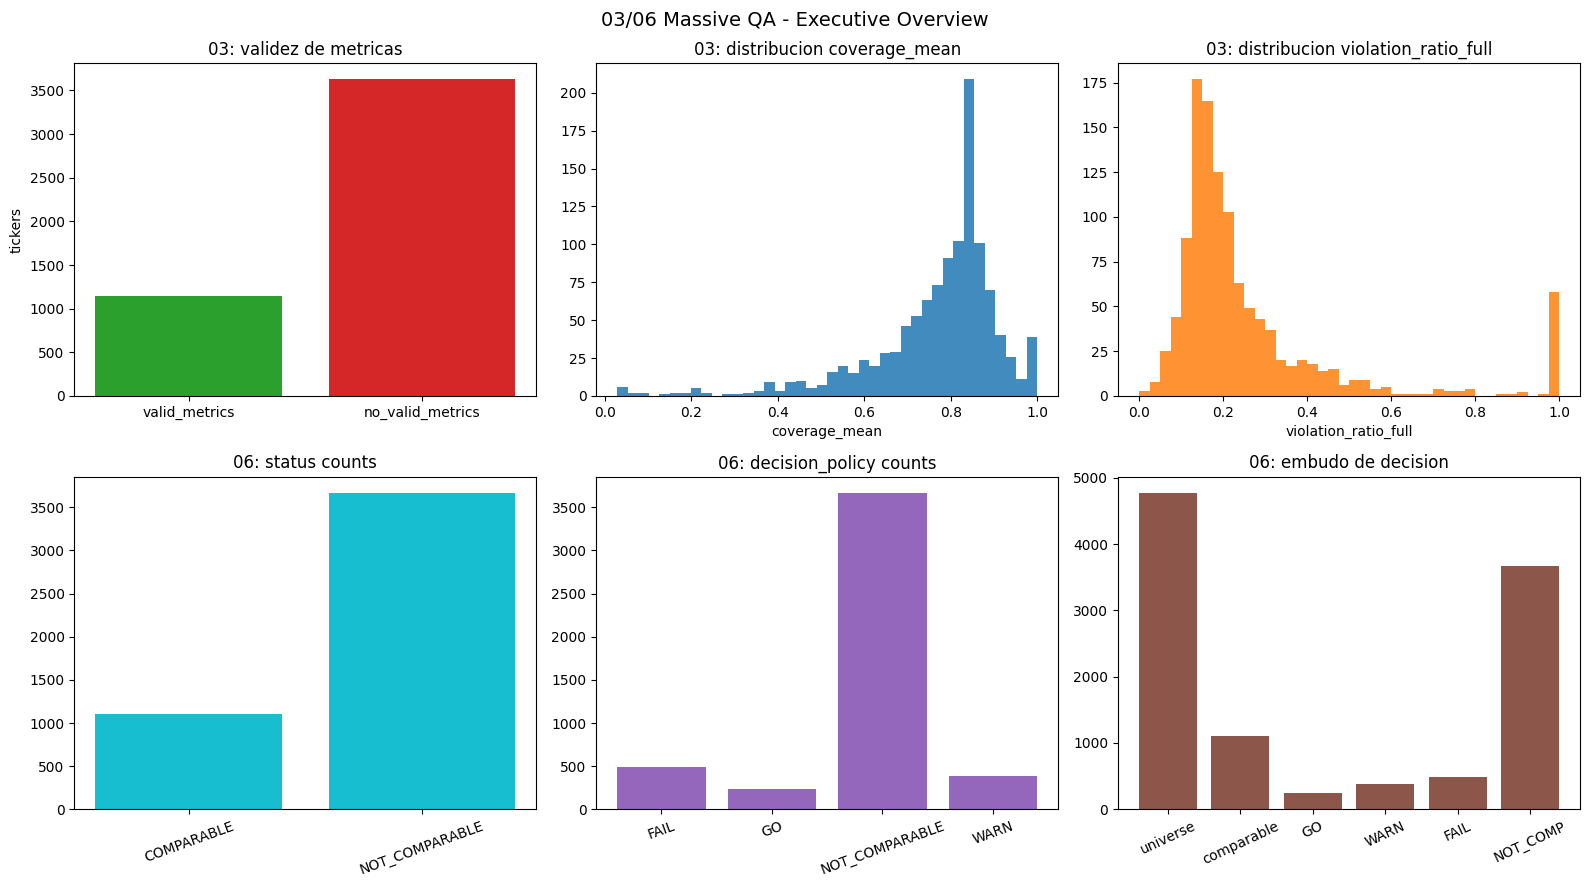

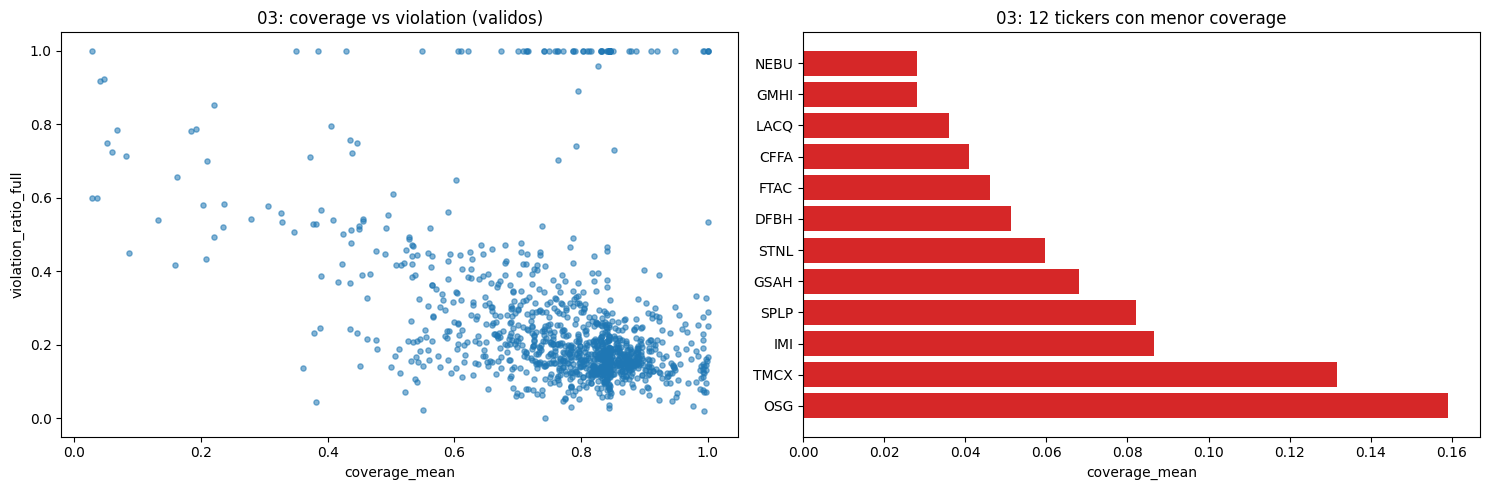

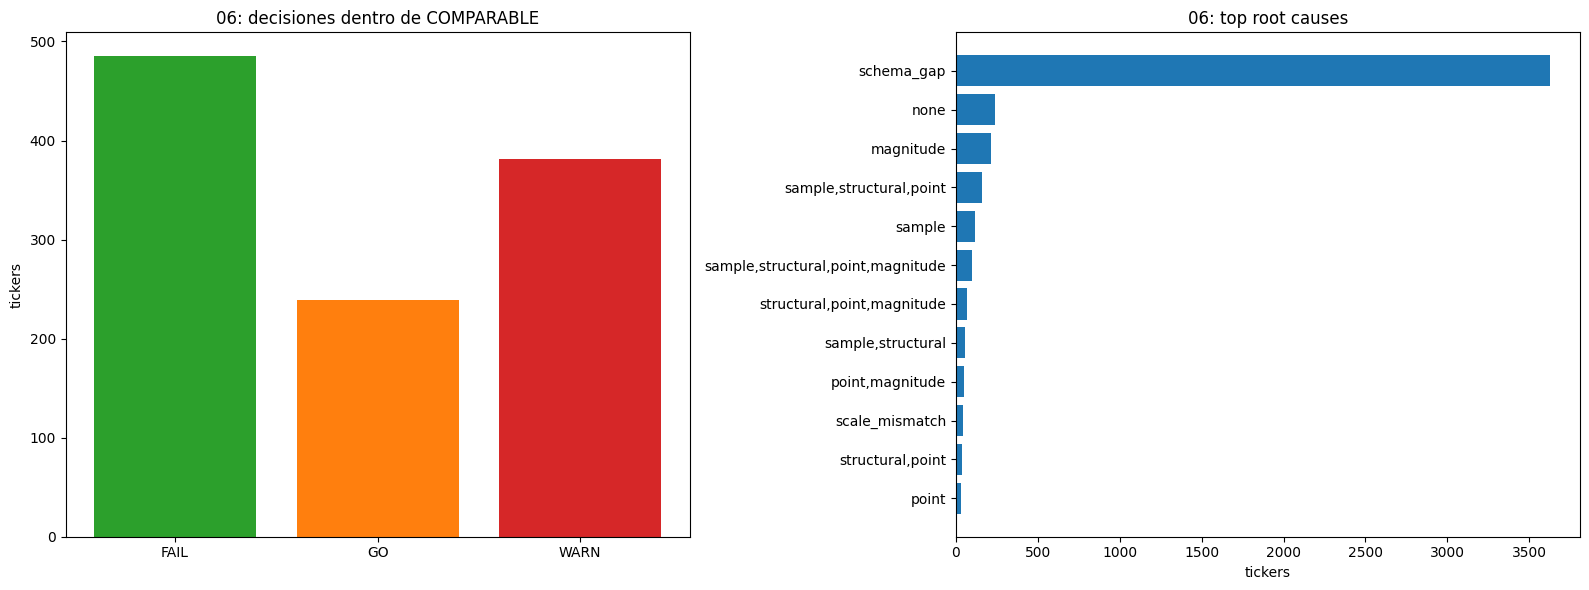

C:\Users\AlexJ\AppData\Local\Temp\ipykernel_17396\3367181949.py:211: DeprecationWarning: use of `how='outer'` should be replaced with `how='full'`.
(Deprecated in version 0.20.29)
  chk = pcnt.join(fcnt, on="decision", how="outer").fill_null(0).sort("decision")


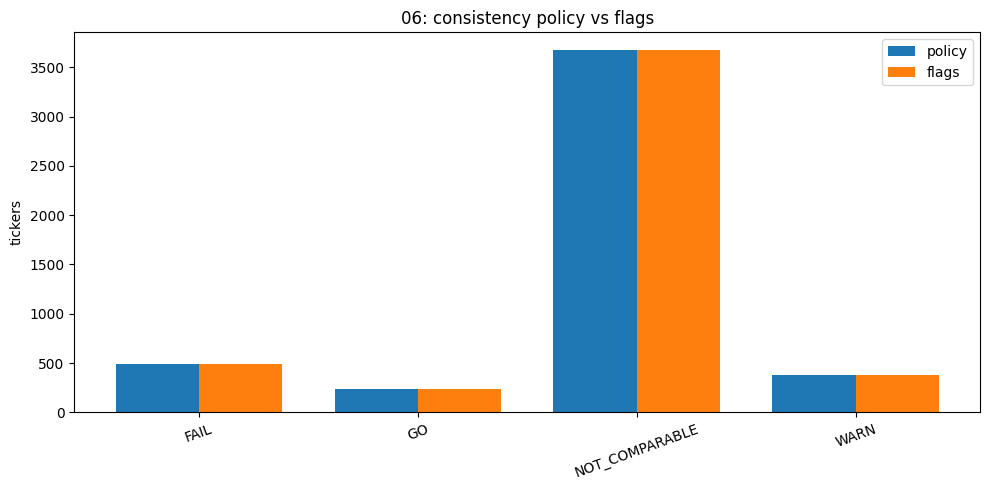

Saved figures:
- C:\TSIS_Data\v1\backtest_SmallCaps\runs\orchestration\figures_03_06\01_overview_03_06.png
- C:\TSIS_Data\v1\backtest_SmallCaps\runs\orchestration\figures_03_06\02_03_scatter_low_coverage.png
- C:\TSIS_Data\v1\backtest_SmallCaps\runs\orchestration\figures_03_06\03_06_decisions_root_causes.png
- C:\TSIS_Data\v1\backtest_SmallCaps\runs\orchestration\figures_03_06\04_06_policy_vs_flags_consistency.png


In [7]:
# Graficos completos 03/06 desde artifacts masivos reales
from pathlib import Path
import json
import numpy as np
import pandas as pd
import polars as pl
# Forzar render inline en notebook (evita popups externos)
try:
    from IPython import get_ipython
    _ip = get_ipython()
    if _ip is not None:
        _ip.run_line_magic("matplotlib", "inline")
except Exception:
    pass

import matplotlib.pyplot as plt
plt.ioff()

PROJECT_ROOT = Path(r"C:\TSIS_Data\v1\backtest_SmallCaps")
ROOT03 = PROJECT_ROOT / "runs" / "data_quality" / "03_time_coverage"
ROOT06 = PROJECT_ROOT / "runs" / "data_quality" / "06_ohlcv_vs_quotes"
FIG_DIR = PROJECT_ROOT / "runs" / "orchestration" / "figures_03_06"
FIG_DIR.mkdir(parents=True, exist_ok=True)


def pick_latest_03_success(root: Path):
    cands = []
    for d in root.iterdir():
        if not d.is_dir():
            continue
        s1 = d / "run_summary.json"
        s2 = d / "03_massive_summary.json"
        m1 = d / "metrics_massive.parquet"
        m2 = d / "03_massive_metrics.parquet"
        sm_fp = s1 if s1.exists() else (s2 if s2.exists() else None)
        m_fp = m1 if m1.exists() else (m2 if m2.exists() else None)
        if sm_fp is None or m_fp is None:
            continue
        try:
            sm = json.loads(sm_fp.read_text(encoding="utf-8"))
            mrows = int(pl.read_parquet(m_fp).height)
            n_err = int(sm.get("n_errors", 0))
            good = (mrows > 0 and n_err == 0)
            cands.append((d.name, d, sm_fp, m_fp, sm, mrows, n_err, good))
        except Exception:
            continue
    if not cands:
        raise FileNotFoundError("No hay runs 03 con summary+metrics")
    good = sorted([x for x in cands if x[-1]], key=lambda x: x[0])
    if good:
        return good[-1]
    return sorted(cands, key=lambda x: x[0])[-1]


def pick_latest_06_massive(root: Path):
    cands = []
    for d in root.iterdir():
        if not d.is_dir() or "massive_v2" not in d.name:
            continue
        sf = d / "mvp_policy_mode_summary.json"
        pf = d / "mvp_policy_mode_table.parquet"
        ff = d / "mvp_full_set.parquet"
        fl = d / "ticker_comparability_flags.parquet"
        if sf.exists() and pf.exists() and ff.exists():
            sm = json.loads(sf.read_text(encoding="utf-8"))
            cands.append((d.name, d, sf, pf, ff, fl, sm))
    if not cands:
        raise FileNotFoundError("No hay runs 06 massive_v2 con artifacts completos")
    return sorted(cands, key=lambda x: x[0])[-1]


# -----------------------------
# Carga artifacts
# -----------------------------
name03, dir03, summary03_fp, metrics03_fp, summary03, mrows03, nerr03, _good03 = pick_latest_03_success(ROOT03)
name06, dir06, summary06_fp, policy06_fp, full06_fp, flags06_fp, summary06 = pick_latest_06_massive(ROOT06)

m03 = pl.read_parquet(metrics03_fp)
p06 = pl.read_parquet(policy06_fp)
f06 = pl.read_parquet(full06_fp)
fl06 = pl.read_parquet(flags06_fp) if flags06_fp.exists() else pl.DataFrame()

print("03 run:", dir03)
print("06 run:", dir06)
print("FIG_DIR:", FIG_DIR)

# 03 validos para metricas
m03_cols = set(m03.columns)
m03_valid = m03
if "n_days" in m03_cols:
    m03_valid = m03_valid.filter(pl.col("n_days") > 0)
if "coverage_mean" in m03_cols:
    m03_valid = m03_valid.filter(pl.col("coverage_mean").is_finite())
if "violation_ratio_full" in m03_cols:
    m03_valid = m03_valid.filter(pl.col("violation_ratio_full").is_finite())

n03_total = int(m03.height)
n03_valid = int(m03_valid.height)
n03_invalid = n03_total - n03_valid

# 06 counts
status_counts = f06.group_by("status").len().sort("status").to_pandas() if "status" in f06.columns else pd.DataFrame()
dec_counts = p06.group_by("decision_policy").len().sort("decision_policy").to_pandas() if "decision_policy" in p06.columns else pd.DataFrame()
comp_dec = p06.filter(pl.col("decision_policy").is_in(["GO","WARN","FAIL"])).group_by("decision_policy").len().sort("decision_policy").to_pandas() if "decision_policy" in p06.columns else pd.DataFrame()
rc_top = p06.group_by("root_cause_policy").len().sort("len", descending=True).head(20).to_pandas() if "root_cause_policy" in p06.columns else pd.DataFrame()

# -----------------------------
# Figure 1: resumen ejecutivo 03/06
# -----------------------------
fig, ax = plt.subplots(2, 3, figsize=(16, 9))

# 03 valididad
ax[0,0].bar(["valid_metrics","no_valid_metrics"], [n03_valid, n03_invalid], color=["#2ca02c", "#d62728"])
ax[0,0].set_title("03: validez de metricas")
ax[0,0].set_ylabel("tickers")

# 03 coverage hist
if n03_valid > 0 and "coverage_mean" in m03_valid.columns:
    cov = m03_valid.select("coverage_mean").to_series().to_list()
    ax[0,1].hist(cov, bins=40, color="#1f77b4", alpha=0.85)
    ax[0,1].set_title("03: distribucion coverage_mean")
    ax[0,1].set_xlabel("coverage_mean")

# 03 violation hist
if n03_valid > 0 and "violation_ratio_full" in m03_valid.columns:
    vr = m03_valid.select("violation_ratio_full").to_series().to_list()
    ax[0,2].hist(vr, bins=40, color="#ff7f0e", alpha=0.85)
    ax[0,2].set_title("03: distribucion violation_ratio_full")
    ax[0,2].set_xlabel("violation_ratio_full")

# 06 status
if not status_counts.empty:
    ax[1,0].bar(status_counts["status"], status_counts["len"], color="#17becf")
    ax[1,0].set_title("06: status counts")
    ax[1,0].tick_params(axis="x", rotation=20)

# 06 decision policy
if not dec_counts.empty:
    ax[1,1].bar(dec_counts["decision_policy"], dec_counts["len"], color="#9467bd")
    ax[1,1].set_title("06: decision_policy counts")
    ax[1,1].tick_params(axis="x", rotation=20)

# Funnel
n_universe = int(summary06.get("n_tickers", p06.height))
n_comp = int(summary06.get("n_comparable", 0))
go = int(p06.filter(pl.col("decision_policy")=="GO").height) if "decision_policy" in p06.columns else 0
warn = int(p06.filter(pl.col("decision_policy")=="WARN").height) if "decision_policy" in p06.columns else 0
fail = int(p06.filter(pl.col("decision_policy")=="FAIL").height) if "decision_policy" in p06.columns else 0
notc = int(p06.filter(pl.col("decision_policy")=="NOT_COMPARABLE").height) if "decision_policy" in p06.columns else 0

ax[1,2].bar(["universe","comparable","GO","WARN","FAIL","NOT_COMP"], [n_universe,n_comp,go,warn,fail,notc], color="#8c564b")
ax[1,2].set_title("06: embudo de decision")
ax[1,2].tick_params(axis="x", rotation=25)

plt.suptitle("03/06 Massive QA - Executive Overview", fontsize=14)
plt.tight_layout()
fp1 = FIG_DIR / "01_overview_03_06.png"
plt.savefig(fp1, dpi=150, bbox_inches="tight")
plt.show()

# -----------------------------
# Figure 2: scatter y extremos 03
# -----------------------------
if n03_valid > 0 and {"coverage_mean","violation_ratio_full"}.issubset(set(m03_valid.columns)):
    d03 = m03_valid.select([c for c in ["ticker","coverage_mean","violation_ratio_full","n_days"] if c in m03_valid.columns]).to_pandas()
    fig, ax = plt.subplots(1, 2, figsize=(15, 5))

    ax[0].scatter(d03["coverage_mean"], d03["violation_ratio_full"], s=14, alpha=0.55)
    ax[0].set_title("03: coverage vs violation (validos)")
    ax[0].set_xlabel("coverage_mean")
    ax[0].set_ylabel("violation_ratio_full")

    low_cov = d03.sort_values("coverage_mean").head(12)
    ax[1].barh(low_cov["ticker"], low_cov["coverage_mean"], color="#d62728")
    ax[1].invert_yaxis()
    ax[1].set_title("03: 12 tickers con menor coverage")
    ax[1].set_xlabel("coverage_mean")

    plt.tight_layout()
    fp2 = FIG_DIR / "02_03_scatter_low_coverage.png"
    plt.savefig(fp2, dpi=150, bbox_inches="tight")
    plt.show()

# -----------------------------
# Figure 3: detalle 06 decisiones y causas
# -----------------------------
fig, ax = plt.subplots(1, 2, figsize=(16, 6))

if not comp_dec.empty:
    ax[0].bar(comp_dec["decision_policy"], comp_dec["len"], color=["#2ca02c", "#ff7f0e", "#d62728"])
    ax[0].set_title("06: decisiones dentro de COMPARABLE")
    ax[0].set_ylabel("tickers")

if not rc_top.empty:
    r = rc_top.head(12).iloc[::-1]
    ax[1].barh(r["root_cause_policy"], r["len"], color="#1f77b4")
    ax[1].set_title("06: top root causes")
    ax[1].set_xlabel("tickers")

plt.tight_layout()
fp3 = FIG_DIR / "03_06_decisions_root_causes.png"
plt.savefig(fp3, dpi=150, bbox_inches="tight")
plt.show()

# -----------------------------
# Figure 4: consistency check policy vs flags
# -----------------------------
if fl06.height > 0 and "decision_final" in fl06.columns and "decision_policy" in p06.columns:
    fcnt = fl06.group_by("decision_final").len().rename({"decision_final":"decision","len":"flags_len"})
    pcnt = p06.group_by("decision_policy").len().rename({"decision_policy":"decision","len":"policy_len"})
    chk = pcnt.join(fcnt, on="decision", how="outer").fill_null(0).sort("decision")
    d = chk.to_pandas()

    x = np.arange(len(d))
    w = 0.38
    fig, ax = plt.subplots(figsize=(10, 5))
    ax.bar(x - w/2, d["policy_len"], width=w, label="policy")
    ax.bar(x + w/2, d["flags_len"], width=w, label="flags")
    ax.set_xticks(x)
    ax.set_xticklabels(d["decision"], rotation=20)
    ax.set_title("06: consistency policy vs flags")
    ax.set_ylabel("tickers")
    ax.legend()
    plt.tight_layout()
    fp4 = FIG_DIR / "04_06_policy_vs_flags_consistency.png"
    plt.savefig(fp4, dpi=150, bbox_inches="tight")
    plt.show()

print("Saved figures:")
for fp in sorted(FIG_DIR.glob("*.png")):
    print("-", fp)



### Lectura cientifica de las figuras 03/06 y plan de recuperacion de no-GO

**1) Figura 009: overview 03/06 (estado global del universo)**

![](../img/009.png)

- En 03: `valid_metrics=1148` y `no_valid_metrics=3629` sobre `N=4777`.
  - Proporcion valida: `1148/4777 = 24.03%`
  - Proporcion no valida: `3629/4777 = 75.97%`
- En 06:
  - `COMPARABLE=1105`, `NOT_COMPARABLE=3672`
  - `GO=239`, `WARN=381`, `FAIL=485`, `NOT_COMPARABLE=3672`

Interpretacion causal:
- El cuello de botella principal no esta en diferenciar `GO/WARN/FAIL` dentro de comparables, sino en entrar al espacio comparable.
- La distribucion de `violation_ratio_full` con cola alta (cercana a 1.0) sugiere subpoblaciones con friccion puntual extrema.

Derivada operativa:
- El mayor retorno de mejora no se logra solo afinando umbrales de decision, sino recuperando comparabilidad estructural.

---

**2) Figura 010: dinamica 03 en validos (`coverage_mean` vs `violation_ratio_full`)**

![](../img/010.png)


- Nube con concentracion en `coverage~0.75-0.90` y `violation~0.10-0.30`, pero con outliers severos.
- En los minimos de cobertura aparecen tickers con `n_days` muy bajos (1-6), lo que reduce estabilidad estadistica de estimadores por ticker.

Interpretacion causal:
- Hay heterogeneidad de regimen: no es una sola poblacion gaussiana; hay mezcla de liquidez alta/media/baja y casos con senal insuficiente.
- Tickers con cobertura muy baja no deben compararse con los de alta cobertura sin estratificacion por evidencia efectiva.

Derivada operativa:
- Separar el universo por estratos de evidencia (`n_days`, cobertura) antes de calibrar reglas globales.

---

**3) Figura 011: decisiones dentro de COMPARABLE y causas raiz 06**

![](../img/011.png)

Que muestra matematicamente:
- Dentro de `COMPARABLE=1105`:
  - `FAIL=485` (`43.89%`)
  - `WARN=381` (`34.48%`)
  - `GO=239` (`21.63%`)
- Causa dominante global: `schema_gap=3629` (casi todo el bloque `NOT_COMPARABLE`).
- Causas secundarias en comparables no-GO: `magnitude`, combinaciones `sample/structural/point`.

Interpretacion causal:
- El sistema separa correctamente dos problemas:
  1. comparabilidad estructural (`schema_gap`),
  2. calidad intrinseca dentro de comparables (`FAIL/WARN`).

Derivada operativa:
- La estrategia de recuperacion debe ser bifasica: primero comparabilidad, luego calidad de ejecucion.

---

**4) Figura 012: consistencia policy vs flags**

![](../img/012.png)

Que muestra matematicamente:
- Las barras `policy` y `flags` coinciden por clase (`GO/WARN/FAIL/NOT_COMPARABLE`).

Interpretacion causal:
- No hay deriva entre capa de decision y capa de trazabilidad.
- La cadena de datos es internamente coherente para auditoria reproducible.

Derivada operativa:
- Se puede usar `policy_file` y `flags_file` indistintamente como fuente de conteo final (segun necesidad analitica).

---

### Plan de recuperacion de no-GO (3 mejoras por grupo)

**A) Recuperacion de `NOT_COMPARABLE` (3672)**

1. **Harmonizacion de schema con contrato can?nico por dominio**
- Crear mapeo determinista de columnas/tipos por version de fuente.
- Aplicar normalizacion previa a QA (nombres, dtypes, timezone, claves de join).
- Meta: reducir `schema_gap` como causa raiz dominante.

2. **Ruta de reconstruccion comparabilidad para casos recuperables**
- Cuando falte una vista agregada, reconstruir features minimas desde fuentes base (ej. quote minute buckets + OHLCV minuto).
- Marcar reconstrucciones con bandera de procedencia para no mezclar con datos nativos.
- Meta: convertir parte de `NOT_COMPARABLE` en `COMPARABLE` con trazabilidad.

3. **Gate de completitud por periodos minimos y evidencia efectiva**
- Exigir umbral de evidencia (`n_days`, cobertura minima) antes de clasificar definitivamente como no comparable.
- Introducir estado intermedio `PENDING_REPAIR` para evitar descartes irreversibles.
- Meta: mejorar recall sin degradar precision de policy.

**B) Recuperacion de `FAIL` en comparables (485)**

1. **Remediacion por eje dominante (sample/structural/point/magnitude)**
- Ejecutar pipeline de correccion especifico por eje, no una regla unica.
- Recalcular decision post-remediacion en lote.
- Meta: mover `FAIL -> WARN/GO` de forma causal y medible.

2. **Normalizacion temporal y microestructural avanzada**
- Auditar alineacion de timestamp, bucketization y sesion regular por ticker.
- Revisar reglas de truncado y outlier handling en colas de `violation_ratio`.
- Meta: reducir falsos FAIL por desalineacion tecnica.

3. **Calibracion robusta por estratos de liquidez/evidencia**
- Calibrar umbrales por cluster de liquidez (no un unico umbral global).
- Ponderar decision por `n_days` y estabilidad intraperiodo.
- Meta: disminuir sobrerrechazo estructural en tickers borderline.

**C) Gestion y promocion de `WARN` (381)**

1. **Guardrails dinamicos en lugar de exclusion binaria**
- Mantener en `relaxed_guardrailed` con peso efectivo y limites de posicion/slippage.
- Ajustar riesgo por severidad de ejes en WARN.
- Meta: capturar informacion util sin asumir riesgo de GO.

2. **Programa de promocion WARN->GO por estabilidad temporal**
- Re-evaluacion rolling con criterios de mejora sostenida (no puntual).
- Promover solo si mejora en varios periodos consecutivos.
- Meta: convertir WARN estables en GO verificable.

3. **Feature-gating para ML por calidad observada**
- En WARN, usar subset de features robustas y excluir features fragiles a microestructura.
- Registrar version de feature-space por nivel de calidad.
- Meta: evitar contaminar entrenamiento con ruido de ejecucion.

---

### Cierre metodologico

La evidencia visual y numerica indica que el problema central del universo no es unicamente de umbral de decision, sino de entrada al espacio comparable (`schema_gap`). La recuperacion efectiva exige una arquitectura de mejora en dos etapas:
1. **recuperar comparabilidad estructural**,
2. **optimizar calidad dentro de comparables**.

Este enfoque maximiza recuperacion de datos sin relajar indebidamente la integridad del pipeline QA.


In [1]:
# BASELINE FINAL (ANTES DE REMEDIACION) - ENLACE 01 -> 02
from pathlib import Path
from datetime import datetime, timezone
import json
import polars as pl

PROJECT_ROOT = Path(r"C:\TSIS_Data\v1\backtest_SmallCaps")
RUNS_ROOT = PROJECT_ROOT / "runs"
DQ_ROOT = RUNS_ROOT / "data_quality"
BASELINE_DIR = RUNS_ROOT / "baseline"
BASELINE_DIR.mkdir(parents=True, exist_ok=True)

# 1) Tomamos los artefactos masivos mas recientes de 03 y 06 (rglob robusto en Windows)
p03_candidates = sorted(
    [p for p in (DQ_ROOT / "03_time_coverage").rglob("03_massive_summary.json") if "massive" in str(p.parent).lower()],
    key=lambda p: p.stat().st_mtime,
)
p06_candidates = sorted(
    [p for p in (DQ_ROOT / "06_ohlcv_vs_quotes").rglob("mvp_policy_mode_table.parquet") if "massive" in str(p.parent).lower()],
    key=lambda p: p.stat().st_mtime,
)

if not p03_candidates:
    raise FileNotFoundError("No se encontro 03_massive_summary.json en runs/data_quality/03_time_coverage con run massive")
if not p06_candidates:
    raise FileNotFoundError("No se encontro mvp_policy_mode_table.parquet en runs/data_quality/06_ohlcv_vs_quotes con run massive")

p03_summary = p03_candidates[-1]
p06_policy = p06_candidates[-1]
p03_run_dir = p03_summary.parent
p06_run_dir = p06_policy.parent

# 2) Cargamos tabla de politica (06)
policy = pl.read_parquet(p06_policy)

# Compatibilidad de nombres de columnas entre versiones de artifacts
if "decision_final" in policy.columns:
    decision_col = "decision_final"
elif "decision_policy" in policy.columns:
    decision_col = "decision_policy"
elif "decision" in policy.columns:
    decision_col = "decision"
elif "status" in policy.columns:
    decision_col = "status"
else:
    raise ValueError(f"No existe columna de decision en policy table. Columnas: {policy.columns}")

if "root_cause_policy" in policy.columns:
    root_col = "root_cause_policy"
elif "root_cause" in policy.columns:
    root_col = "root_cause"
else:
    root_col = None

work = policy.with_columns(pl.col(decision_col).cast(pl.Utf8).alias("decision_final_norm"))
if root_col is None:
    work = work.with_columns(pl.lit("unknown").alias("root_cause_norm"))
else:
    work = work.with_columns(pl.col(root_col).cast(pl.Utf8).fill_null("unknown").alias("root_cause_norm"))

# 3) Tabla final BEFORE: conteos + ratio
n_total = work.height
before_counts = (
    work.group_by("decision_final_norm")
    .agg(pl.len().alias("n_tickers"))
    .with_columns((pl.col("n_tickers") / pl.lit(max(n_total,1))).alias("ratio"))
    .rename({"decision_final_norm": "decision_final"})
    .sort("n_tickers", descending=True)
)

# 4) Root causes principales
root_causes = (
    work.group_by(["decision_final_norm", "root_cause_norm"])
    .agg(pl.len().alias("n"))
    .rename({"decision_final_norm": "decision_final", "root_cause_norm": "root_cause"})
    .sort(["decision_final", "n"], descending=[False, True])
)

# 5) Guardamos baseline canonicamente
stamp = datetime.now(timezone.utc).strftime("%Y%m%dT%H%M%SZ")
out_dir = BASELINE_DIR / f"before_remediation_{stamp}"
out_dir.mkdir(parents=True, exist_ok=True)

before_counts_path = out_dir / "baseline_before_counts.parquet"
root_causes_path = out_dir / "baseline_before_root_causes.parquet"
manifest_path = out_dir / "baseline_before_manifest.json"

before_counts.write_parquet(before_counts_path)
root_causes.write_parquet(root_causes_path)

manifest = {
    "created_at_utc": datetime.now(timezone.utc).isoformat(),
    "scope": "before_remediation",
    "source": {
        "03_summary_json": str(p03_summary),
        "03_run_dir": str(p03_run_dir),
        "06_policy_table": str(p06_policy),
        "06_run_dir": str(p06_run_dir),
    },
    "schema": {
        "decision_column_used": decision_col,
        "root_cause_column_used": root_col,
    },
    "n_tickers_total": int(n_total),
    "files": {
        "baseline_before_counts_parquet": str(before_counts_path),
        "baseline_before_root_causes_parquet": str(root_causes_path),
    },
}
manifest_path.write_text(json.dumps(manifest, indent=2, ensure_ascii=False), encoding="utf-8")

# 6) Imprimimos tabla final ANTES (lo que queriamos ver en 01)
print("=== BASELINE BEFORE REMEDIATION (01) ===")
print("03 run:", p03_run_dir)
print("06 run:", p06_run_dir)
print("decision column used:", decision_col)
print("root cause column used:", root_col)
print("Saved manifest:", manifest_path)
print("\n[Decision counts + ratio]")
print(before_counts)
print("\n[Top root causes por decision_final]")
print(root_causes.head(30))


=== BASELINE BEFORE REMEDIATION (01) ===
03 run: C:\TSIS_Data\v1\backtest_SmallCaps\runs\data_quality\03_time_coverage\20260222_194454_massive_v2
06 run: C:\TSIS_Data\v1\backtest_SmallCaps\runs\data_quality\06_ohlcv_vs_quotes\20260223_124728_mvp_03_06_alignment_massive_v2
decision column used: decision_policy
root cause column used: root_cause_policy
Saved manifest: C:\TSIS_Data\v1\backtest_SmallCaps\runs\baseline\before_remediation_20260224T085411Z\baseline_before_manifest.json

[Decision counts + ratio]
shape: (4, 3)
┌────────────────┬───────────┬──────────┐
│ decision_final ┆ n_tickers ┆ ratio    │
│ ---            ┆ ---       ┆ ---      │
│ str            ┆ u32       ┆ f64      │
╞════════════════╪═══════════╪══════════╡
│ NOT_COMPARABLE ┆ 3672      ┆ 0.768683 │
│ FAIL           ┆ 485       ┆ 0.101528 │
│ WARN           ┆ 381       ┆ 0.079757 │
│ GO             ┆ 239       ┆ 0.050031 │
└────────────────┴───────────┴──────────┘

[Top root causes por decision_final]
shape: (30, 3)
┌─

### Cierre de Fase en `01` y Puente Oficial hacia `02`

Desde este punto, `01_dataset_builder.ipynb` queda como **baseline hist?rico** (ANTES de remediaci?n) y referencia de trazabilidad.

A partir de ahora, el trabajo operativo contin?a en:
- `02_policy_integration_and_massive_orchestration.ipynb`

Objetivo del salto:
1. separar arquitectura (contrato, policy, remediaci?n, orquestaci?n),
2. reducir `NOT_COMPARABLE` (especialmente `schema_gap`),
3. recortar `FAIL` recuperable con un flujo reproducible y testeable.

El baseline guardado en `runs/baseline/before_remediation_*/` ser? la referencia oficial para medir delta `before vs after`.


### Constancia de Rectificaci?n 03->06 y Resultado Consolidado (Before vs After)

Esta celda documenta expl?citamente el cambio metodol?gico y su impacto en pol?tica de universo.

Qu? se corrigi?:
1. En `03_time_coverage` (reconversi?n masiva v2) se aplic? prefilter de elegibilidad por evidencia real en meses objetivo.
2. En `06_ohlcv_vs_quotes` masivo se dej? de usar universo bruto `has_overlap=True` y se consumi? la intersecci?n con tickers elegibles de 03.

Por qu? ahora aparece este resultado:
1. Antes, una gran parte del universo entraba sin observaciones v?lidas en ventana objetivo (`n_days=0`), produciendo `NaN` y siendo clasificado como `schema_gap`.
2. Tras prefilter + relanzamiento, ese bloque artificial desaparece y queda solo el `NOT_COMPARABLE` estructural real (`scale_mismatch`).
3. La mezcla `GO/WARN/FAIL` se mantiene en el set comparable, lo que indica que se elimin? ruido de entrada y no se?al ?til.

Resultado esperado que debe quedar trazado en esta secci?n:
- `NOT_COMPARABLE`: 3672 -> 43 (`-3629`)
- `schema_gap`: 3629 -> 0
- `scale_mismatch`: 43 -> 43
- `GO/WARN/FAIL`: sin cambios


In [1]:
# CONSTANCIA EJECUTADA: before vs after + graficos
from pathlib import Path
import json
import polars as pl
import matplotlib.pyplot as plt

PROJECT_ROOT = Path(r"C:\TSIS_Data\v1\backtest_SmallCaps")
BASE = PROJECT_ROOT / "runs" / "baseline"
OUT_DIR = PROJECT_ROOT / "runs" / "backtest" / "01_dataset_builder" / "constancia_before_after"
OUT_DIR.mkdir(parents=True, exist_ok=True)

before_dirs = sorted(BASE.glob("before_remediation_*"), key=lambda p: p.stat().st_mtime)
after_dirs = sorted(BASE.glob("after_remediation_*"), key=lambda p: p.stat().st_mtime)
if not before_dirs or not after_dirs:
    raise FileNotFoundError("Falta baseline before/after; revisa runs/baseline")

before = before_dirs[-1]
after = after_dirs[-1]

b_counts = pl.read_parquet(before / "baseline_before_counts.parquet")
a_counts = pl.read_parquet(after / "baseline_after_counts.parquet")

cmp = (
    b_counts.select(["decision_final","n_tickers"]).rename({"n_tickers":"n_before"})
    .join(a_counts.select(["decision_final","n_tickers"]).rename({"n_tickers":"n_after"}), on="decision_final", how="full")
    .fill_null(0)
    .with_columns((pl.col("n_after").cast(pl.Int64) - pl.col("n_before").cast(pl.Int64)).alias("delta"))
    .sort("decision_final")
)

b_roots = pl.read_parquet(before / "baseline_before_root_causes.parquet")
a_roots = pl.read_parquet(after / "baseline_after_root_causes.parquet")

b_notc = b_roots.filter(pl.col("decision_final")=="NOT_COMPARABLE").select(["root_cause","n"]).rename({"n":"n_before"})
a_notc = a_roots.filter(pl.col("decision_final")=="NOT_COMPARABLE").select(["root_cause","n"]).rename({"n":"n_after"})
root_cmp = (
    b_notc.join(a_notc, on="root_cause", how="full")
    .fill_null(0)
    .with_columns((pl.col("n_after").cast(pl.Int64) - pl.col("n_before").cast(pl.Int64)).alias("delta"))
    .sort("root_cause")
)

# Guardar tablas
cmp_fp = OUT_DIR / "decision_before_after.parquet"
root_fp = OUT_DIR / "not_comparable_root_before_after.parquet"
cmp.write_parquet(cmp_fp)
root_cmp.write_parquet(root_fp)

# Grafico 1: decision counts before/after
order = ["GO", "WARN", "FAIL", "NOT_COMPARABLE"]
cmpp = cmp.with_columns(pl.col("decision_final").cast(pl.Categorical)).sort("decision_final")
# reconstruir en orden operativo
rows = []
by = {r['decision_final']: r for r in cmp.to_dicts()}
for k in order:
    r = by.get(k, {'decision_final':k,'n_before':0,'n_after':0,'delta':0})
    rows.append(r)

labels = [r['decision_final'] for r in rows]
bef = [int(r['n_before']) for r in rows]
aft = [int(r['n_after']) for r in rows]

x = range(len(labels))
plt.figure(figsize=(9,4))
plt.bar([i-0.2 for i in x], bef, width=0.4, label='before')
plt.bar([i+0.2 for i in x], aft, width=0.4, label='after')
plt.xticks(list(x), labels)
plt.title('Decision Policy Counts: Before vs After Remediation')
plt.ylabel('Tickers')
plt.legend()
plt.tight_layout()
fig1 = OUT_DIR / "decision_before_after.png"
plt.savefig(fig1, dpi=140)
plt.close()

# Grafico 2: NOT_COMPARABLE root causes
rlabels = [r['root_cause'] for r in root_cmp.to_dicts()]
rbef = [int(r['n_before']) for r in root_cmp.to_dicts()]
raft = [int(r['n_after']) for r in root_cmp.to_dicts()]

x2 = range(len(rlabels))
plt.figure(figsize=(9,4))
plt.bar([i-0.2 for i in x2], rbef, width=0.4, label='before')
plt.bar([i+0.2 for i in x2], raft, width=0.4, label='after')
plt.xticks(list(x2), rlabels)
plt.title('NOT_COMPARABLE Root Causes: Before vs After')
plt.ylabel('Tickers')
plt.legend()
plt.tight_layout()
fig2 = OUT_DIR / "not_comparable_roots_before_after.png"
plt.savefig(fig2, dpi=140)
plt.close()

summary = {
    "before": str(before),
    "after": str(after),
    "outputs": {
        "decision_table": str(cmp_fp),
        "not_comparable_root_table": str(root_fp),
        "decision_chart": str(fig1),
        "root_chart": str(fig2),
    }
}
(OUT_DIR / "constancia_summary.json").write_text(json.dumps(summary, indent=2, ensure_ascii=False), encoding='utf-8')

print("=== CONSTANCIA BEFORE vs AFTER (01) ===")
print("before:", before)
print("after:", after)
print("\n[Decision delta]")
print(cmp)
print("\n[NOT_COMPARABLE root cause delta]")
print(root_cmp)
print("\nSaved:")
print(cmp_fp)
print(root_fp)
print(fig1)
print(fig2)
print(OUT_DIR / "constancia_summary.json")


=== CONSTANCIA BEFORE vs AFTER (01) ===
before: C:\TSIS_Data\v1\backtest_SmallCaps\runs\baseline\before_remediation_20260224T085411Z
after: C:\TSIS_Data\v1\backtest_SmallCaps\runs\baseline\after_remediation_20260224T121634Z

[Decision delta]
shape: (4, 5)
┌────────────────┬──────────┬──────────────────────┬─────────┬───────┐
│ decision_final ┆ n_before ┆ decision_final_right ┆ n_after ┆ delta │
│ ---            ┆ ---      ┆ ---                  ┆ ---     ┆ ---   │
│ str            ┆ u32      ┆ str                  ┆ u32     ┆ i64   │
╞════════════════╪══════════╪══════════════════════╪═════════╪═══════╡
│ FAIL           ┆ 485      ┆ FAIL                 ┆ 485     ┆ 0     │
│ GO             ┆ 239      ┆ GO                   ┆ 239     ┆ 0     │
│ NOT_COMPARABLE ┆ 3672     ┆ NOT_COMPARABLE       ┆ 43      ┆ -3629 │
│ WARN           ┆ 381      ┆ WARN                 ┆ 381     ┆ 0     │
└────────────────┴──────────┴──────────────────────┴─────────┴───────┘

[NOT_COMPARABLE root cause delta]